# Market Structure Intelligence: XGBoost Strategy Framework
### Gold Futures (XAUUSD Proxy) — 1-Minute Intraday Classification & Backtesting

---

**Strategy Philosophy:**  
This notebook builds a market-structure-aware machine learning pipeline for short-term price direction classification on Gold Futures (`GC=F`). It exploits fractal pivots, Break-of-Structure (BOS), Change-of-Character (CHoCH), Order Blocks, and derivative price features to generate a rich contextual feature matrix that feeds a multi-class XGBoost classifier.

**Pipeline Architecture:**

| Stage | Description |
|---|---|
| **1** | Data Collection — `yfinance` 1-min OHLCV + 15-min HTF context |
| **2** | EDA & Visualization — price, volume, ATR regime overview |
| **3** | Feature Engineering — indicators, derivatives, structure events |
| **4** | Context Enrichment — VWAP, sessions, HTF bias, Bollinger Bands |
| **5** | Lookback Matrix — N-deep rolling feature snapshots per event type |
| **6** | Target Labeling — Triple Barrier Method |
| **7** | Cleaning & Splitting — temporal train/val/OOS split |
| **8** | Base Model — XGBoost Categorical classifier |
| **9** | Base Evaluation — confusion matrix, ROC, feature importance |
| **10** | Base Backtest — vectorised SL/TP simulation + equity curve |
| **11** | Fine-Tuning — Optuna hyperparameter search |
| **12** | Fine-Tuned Evaluation — OOS classification metrics |
| **13** | Fine-Tuned Backtest — equity curve on hold-out data |
| **14** | Comparative Analytics — Sharpe, Sortino, Calmar, MDD, Monte Carlo |

---
> **Reproducibility:** All random seeds are fixed at `42`. Data is fetched live; re-run may produce marginally different results if new bars become available.


## Section 1 — Environment Setup & Configuration

In [1]:
# # ──────────────────────────────────────────────────────────────────────────────
# # 1.1  DEPENDENCY INSTALLATION
# # ──────────────────────────────────────────────────────────────────────────────
# import subprocess, sys

# PACKAGES = [
#     "yfinance", "xgboost>=2.0", "optuna", "scikit-learn",
#     "pandas", "numpy", "matplotlib", "seaborn", "scipy"
# ]

# for pkg in PACKAGES:
#     subprocess.run(
#         [sys.executable, "-m", "pip", "install", pkg, "-q"],
#         check=False
#     )

# print("✓ All dependencies installed.")


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import itertools, time, os
from datetime import datetime, timedelta

from collections import deque
from scipy.stats import skew, kurtosis

import MetaTrader5 as mt5
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    classification_report
)
from sklearn.preprocessing import label_binarize

# ─── Plot Styling ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'figure.dpi':       110,
    'font.family':      'DejaVu Sans',
})

BULL_COLOR  = '#3fb950'
BEAR_COLOR  = '#f85149'
NEUT_COLOR  = '#58a6ff'
BASE_COLOR  = '#58a6ff'
FT_COLOR    = '#3fb950'

print("✓ Imports complete.")

✓ Imports complete.


In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# 1.3  STRATEGY CONFIGURATION  (edit here only)
# ──────────────────────────────────────────────────────────────────────────────
# MT5 Configuration
SYMBOL       = 'Volatility 100 (1s) Index'        # Gold vs US Dollar on MT5
TIMEFRAME_1M = mt5.TIMEFRAME_M5   # 1-minute timeframe
TIMEFRAME_15M = mt5.TIMEFRAME_M30  # 15-minute timeframe
BARS_BACK    = 10000           # Number of bars to fetch from MT5
ACCOUNT      = None            # None = default account (or specify account number)

# Legacy config (kept for compatibility with rest of code)
TICKER       = 'XAUUSD'        
INTERVAL     = '5m'
PERIOD       = '6d'
HTF_INTERVAL = '5m'
HTF_PERIOD   = '30d'

N            = 3               # Number of past events to look back per type
LEFT_BARS    = 5               # Fractal pivot left bars
RIGHT_BARS   = 2               # Fractal pivot right bars (confirmation lag)
ATR_LEN      = 14              # ATR smoothing period
RSI_LEN      = 14              # Primary RSI period
MIN_ATR_MULT = 1             # Minimum swing size in ATR units

LOOKAHEAD    = 30              # Bars to look ahead for Triple Barrier labeling
RISK_REWARD  = 2.0             # TP / SL ratio for labels

TRAIN_RATIO  = 0.70            # Proportion of data for training
VAL_RATIO    = 0.15            # Proportion for validation (fine-tuning)
# Remaining 0.15 → OOS hold-out (untouched until final evaluation)

RANDOM_SEED  = 42
OUTPUT_CSV   = 'market_structure_features.csv'

np.random.seed(RANDOM_SEED)

print("=" * 60)
print("  STRATEGY CONFIGURATION (MT5)")
print("=" * 60)
print(f"  Symbol      : {SYMBOL}  |  Interval: 1m / 15m")
print(f"  Bars Back   : {BARS_BACK:,}")
print(f"  N (lookback): {N}  |  ATR: {ATR_LEN}  |  RSI: {RSI_LEN}")
print(f"  Fractal     : Left={LEFT_BARS}, Right={RIGHT_BARS}")
print(f"  Label       : Lookahead={LOOKAHEAD}, RR={RISK_REWARD}")
print(f"  Split       : Train={TRAIN_RATIO} | Val={VAL_RATIO} | OOS={1-TRAIN_RATIO-VAL_RATIO:.2f}")
print("=" * 60)

  STRATEGY CONFIGURATION (MT5)
  Symbol      : Volatility 100 (1s) Index  |  Interval: 1m / 15m
  Bars Back   : 10,000
  N (lookback): 3  |  ATR: 14  |  RSI: 14
  Fractal     : Left=5, Right=2
  Label       : Lookahead=30, RR=2.0
  Split       : Train=0.7 | Val=0.15 | OOS=0.15


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# 1.4  MT5 CONNECTION & HELPER FUNCTIONS
# ──────────────────────────────────────────────────────────────────────────────

# Initialize MetaTrader5 connection
if not mt5.initialize():
    print(f"✗ Failed to initialize MT5: {mt5.last_error()}")
else:
    print("✓ MT5 initialized successfully")

def fetch_mt5_data(symbol, timeframe, num_bars):
    """
    Fetch OHLCV data from MT5.
    
    Parameters:
    -----------
    symbol : str
        Trading symbol (e.g., 'XAUUSD')
    timeframe : int
        MT5 timeframe constant (e.g., mt5.TIMEFRAME_M1)
    num_bars : int
        Number of historical bars to fetch
    
    Returns:
    --------
    pd.DataFrame : DataFrame with columns [datetime, open, high, low, close, volume]
    """
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, num_bars)
    
    if rates is None:
        print(f"✗ Failed to fetch {symbol} {timeframe}: {mt5.last_error()}")
        return pd.DataFrame()
    
    # Convert to DataFrame
    df = pd.DataFrame(rates)
    df['datetime'] = pd.to_datetime(df['time'], unit='s')
    df = df[['datetime', 'open', 'high', 'low', 'close', 'tick_volume']].copy()
    df.columns = ['datetime', 'open', 'high', 'low', 'close', 'volume']
    df = df.sort_values('datetime').reset_index(drop=True)
    
    return df

print("✓ MT5 connection and helper functions loaded.")

✓ MT5 initialized successfully
✓ MT5 connection and helper functions loaded.


## Section 2 — Data Collection

We collect the primary 1-minute OHLCV series alongside a 15-minute higher-timeframe series for trend bias enrichment. Both are sourced from `yfinance` (Gold Futures `GC=F`).


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.1  FETCH PRIMARY 1-MINUTE DATA FROM MT5
# ──────────────────────────────────────────────────────────────────────────────
print(f"Fetching {BARS_BACK:,} bars of {SYMBOL} 1m data from MT5...")

df = fetch_mt5_data(SYMBOL, TIMEFRAME_1M, BARS_BACK)

if df.empty:
    print("✗ Failed to fetch 1m data. Ensure MT5 is running and XAUUSD symbol is available.")
else:
    df = df.dropna().reset_index(drop=True)
    print(f"✓  {len(df):,} bars loaded  |  {df['datetime'].min()} → {df['datetime'].max()}")
    display(df.head(3))

Fetching 10,000 bars of Volatility 100 (1s) Index 1m data from MT5...
✓  10,000 bars loaded  |  2026-03-14 21:05:00 → 2026-04-18 14:20:00


,datetime,open,high,low,close,volume
0,2026-03-14 21:05:00,1601.22,1608.09,1598.72,1607.33,294
1,2026-03-14 21:10:00,1607.19,1612.42,1605.40,1612.01,295
2,2026-03-14 21:15:00,1611.59,1611.59,1599.60,1599.76,299


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.2  FETCH HIGHER-TIMEFRAME (15-MIN) DATA FROM MT5 FOR TREND BIAS
# ──────────────────────────────────────────────────────────────────────────────
print(f"Fetching {SYMBOL} 15m data from MT5...")

htf_df = fetch_mt5_data(SYMBOL, TIMEFRAME_15M, BARS_BACK)

if htf_df.empty:
    print("Warning: HTF data could not be fetched or was empty. Initializing HTF columns with NaNs.")
    df['htf_ema50'] = np.nan
    df['htf_ema200'] = np.nan
    df['htf_bullish'] = np.nan
else:
    # ─── HTF EMA 50 for trend bias ────────────────────────────────────────────────
    htf_df['htf_ema50']  = htf_df['close'].ewm(span=50, adjust=False).mean()
    htf_df['htf_ema200'] = htf_df['close'].ewm(span=200, adjust=False).mean()
    htf_df['htf_bullish'] = (htf_df['htf_ema50'] > htf_df['htf_ema200']).astype(int)
    htf_df['htf_bullish'] = htf_df['htf_bullish'].shift(1) # Shift for no lookahead bias

    # Merge to 1m: forward-fill HTF bias onto each 1-min bar
    htf_merge = htf_df[['datetime', 'htf_ema50', 'htf_ema200', 'htf_bullish']].copy()
    htf_merge = htf_merge.sort_values('datetime')

    df = df.sort_values('datetime')
    df = pd.merge_asof(df, htf_merge, on='datetime', direction='backward')

# Ensure 'htf_bullish' column exists before summing, even if filled with NaNs
if 'htf_bullish' not in df.columns:
    df['htf_bullish'] = np.nan

print(f"✓  HTF context merged.  |  HTF bullish bars: {df['htf_bullish'].sum():,.0f}")
display(df[['datetime', 'close', 'htf_ema50', 'htf_bullish']].tail(3))

Fetching Volatility 100 (1s) Index 15m data from MT5...
✓  HTF context merged.  |  HTF bullish bars: 4,894


,datetime,close,htf_ema50,htf_bullish
9997,2026-04-18 14:10:00,1432.62,1411.332707,1.0
9998,2026-04-18 14:15:00,1432.89,1411.332707,1.0
9999,2026-04-18 14:20:00,1432.30,1411.332707,1.0


## Section 3 — Exploratory Data Analysis & Visualization

Before engineering features, we inspect the raw data to understand distribution, volume regimes, and ATR-normalised volatility.


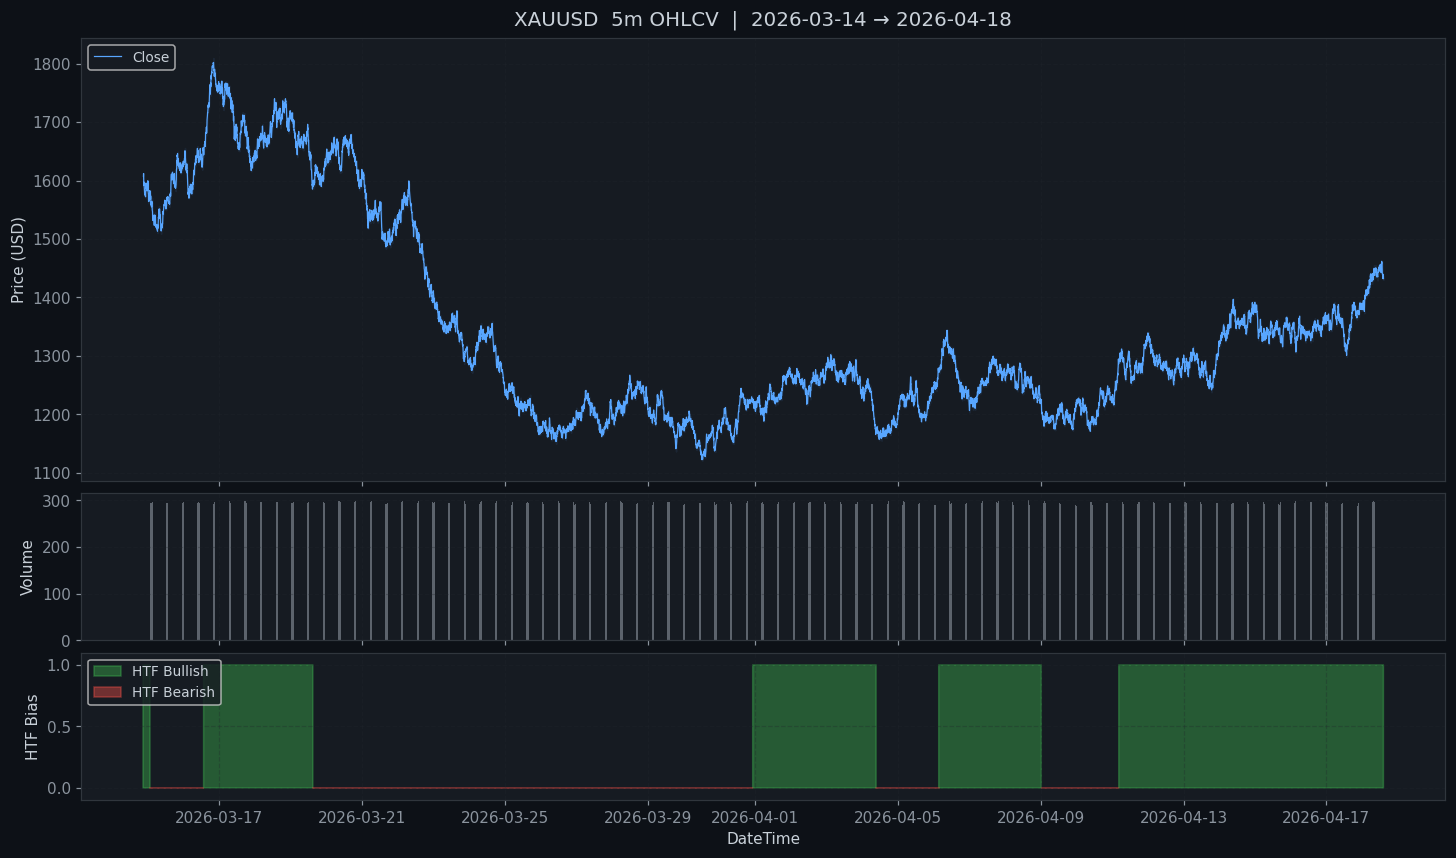


──────────────────────────────────────────────────
  Bars          : 10,000
  Price Range   : 1122.51 – 1801.93
  Avg Volume    : 295
  Missing vals  : 0
──────────────────────────────────────────────────


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.1  PRICE & VOLUME OVERVIEW
# ──────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.05, height_ratios=[3, 1, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# ─── Price ────────────────────────────────────────────────────────────────────
ax1.plot(df['datetime'], df['close'], color=NEUT_COLOR, lw=0.8, label='Close')
ax1.fill_between(df['datetime'], df['low'], df['high'],
                 alpha=0.08, color=NEUT_COLOR)
ax1.set_ylabel('Price (USD)')
ax1.set_title(f'{TICKER}  {INTERVAL} OHLCV  |  {df["datetime"].min().date()} → {df["datetime"].max().date()}',
              fontsize=13, pad=8)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# ─── Volume ───────────────────────────────────────────────────────────────────
ax2.bar(df['datetime'], df['volume'], color='#8b949e', alpha=0.6, width=0.0005)
ax2.set_ylabel('Volume')
ax2.grid(True, alpha=0.3)

# ─── HTF Bias ────────────────────────────────────────────────────────────────
ax3.fill_between(df['datetime'], df['htf_bullish'],
                 where=df['htf_bullish'] == 1,
                 color=BULL_COLOR, alpha=0.4, label='HTF Bullish')
ax3.fill_between(df['datetime'], df['htf_bullish'],
                 where=df['htf_bullish'] == 0,
                 color=BEAR_COLOR, alpha=0.4, label='HTF Bearish')
ax3.set_ylim(-0.1, 1.1)
ax3.set_ylabel('HTF Bias')
ax3.set_xlabel('DateTime')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\n{'─'*50}")
print(f"  Bars          : {len(df):,}")
print(f"  Price Range   : {df['close'].min():.2f} – {df['close'].max():.2f}")
print(f"  Avg Volume    : {df['volume'].mean():,.0f}")
print(f"  Missing vals  : {df.isnull().sum().sum()}")
print(f"{'─'*50}")


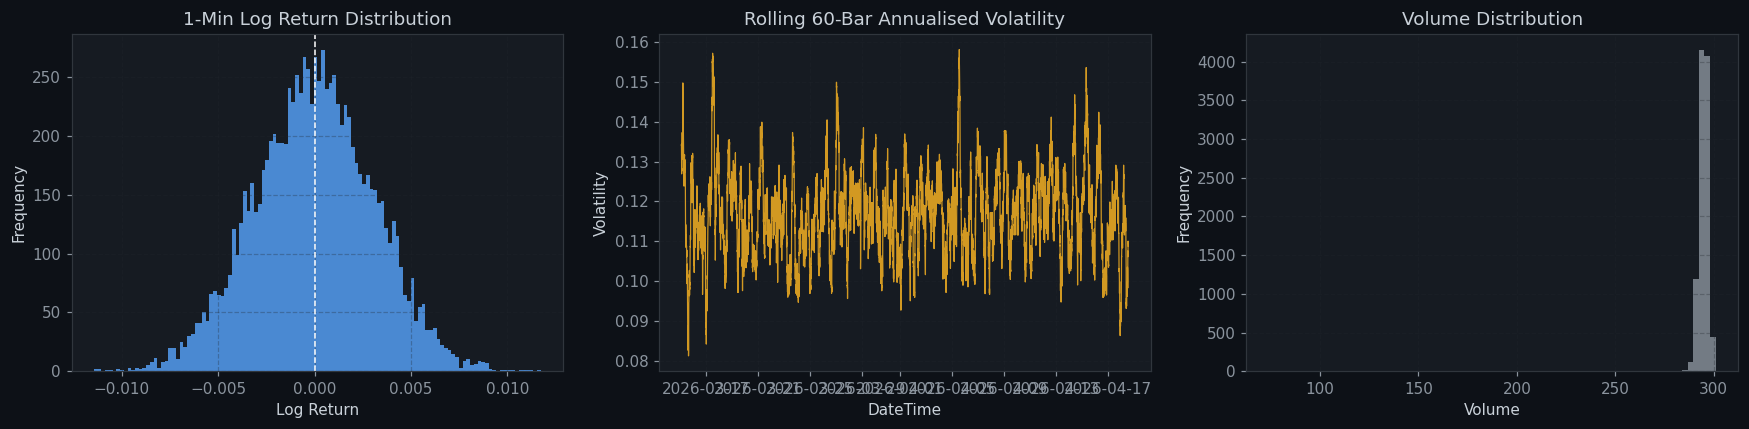

  Return Skew   : -0.0163
  Return Kurt   : -0.0146


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.2  RETURN DISTRIBUTION & VOLATILITY REGIME
# ──────────────────────────────────────────────────────────────────────────────
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
rolling_vol   = df['log_ret'].rolling(60).std() * np.sqrt(1440)   # annualised

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ─── Return histogram
axes[0].hist(df['log_ret'].dropna(), bins=120, color=NEUT_COLOR, alpha=0.8, edgecolor='none')
axes[0].axvline(0, color='white', lw=1, ls='--')
axes[0].set_title('1-Min Log Return Distribution')
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# ─── Rolling volatility
axes[1].plot(df['datetime'], rolling_vol, color='#d29922', lw=0.8)
axes[1].set_title('Rolling 60-Bar Annualised Volatility')
axes[1].set_xlabel('DateTime')
axes[1].set_ylabel('Volatility')
axes[1].grid(True, alpha=0.3)

# ─── Volume distribution
axes[2].hist(df['volume'].dropna(), bins=80, color='#8b949e', alpha=0.8, edgecolor='none')
axes[2].set_title('Volume Distribution')
axes[2].set_xlabel('Volume')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"  Return Skew   : {skew(df['log_ret'].dropna()):.4f}")
print(f"  Return Kurt   : {kurtosis(df['log_ret'].dropna()):.4f}")


## Section 4 — Core Indicator Engineering

We compute ATR, multi-period RSI, EMAs, MACD, Bollinger Bands, VWAP, and volume-regime features. These form the base layer of the feature matrix.


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.1  HELPER FUNCTIONS
# ──────────────────────────────────────────────────────────────────────────────

def calc_atr(df, n=14):
    """Wilder-smoothed Average True Range."""
    h, l, c = df['high'], df['low'], df['close']
    tr = pd.concat([
        (h - l),
        (h - c.shift()).abs(),
        (l - c.shift()).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1/n, adjust=False).mean()


def calc_rsi(series, n=14):
    """Wilder-smoothed RSI."""
    delta = series.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/n, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/n, adjust=False).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def calc_macd(series, fast=12, slow=26, signal=9):
    """MACD line, Signal line, Histogram."""
    ema_fast   = series.ewm(span=fast, adjust=False).mean()
    ema_slow   = series.ewm(span=slow, adjust=False).mean()
    macd_line  = ema_fast - ema_slow
    sig_line   = macd_line.ewm(span=signal, adjust=False).mean()
    hist       = macd_line - sig_line
    return macd_line, sig_line, hist


def calc_bollinger(series, n=20, k=2.0):
    """Bollinger Bands: upper, middle, lower, %B, bandwidth."""
    mid   = series.rolling(n).mean()
    std   = series.rolling(n).std()
    upper = mid + k * std
    lower = mid - k * std
    pct_b = (series - lower) / (upper - lower).replace(0, np.nan)
    bw    = (upper - lower) / mid.replace(0, np.nan)
    return upper, mid, lower, pct_b, bw


def calc_vwap(df):
    """Session VWAP — resets at the start of each calendar day."""
    typical = (df['high'] + df['low'] + df['close']) / 3
    df = df.copy()
    df['_tp'] = typical
    df['_date'] = df['datetime'].dt.date
    df['_tpv']  = df['_tp'] * df['volume']
    vwap = (
        df.groupby('_date')['_tpv'].cumsum() /
        df.groupby('_date')['volume'].cumsum()
    )
    return vwap


print("✓  Indicator helper functions defined.")


✓  Indicator helper functions defined.


In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.2  COMPUTE ALL BASE INDICATORS
# ──────────────────────────────────────────────────────────────────────────────

# ─── ATR ──────────────────────────────────────────────────────────────────────
df['atr']      = calc_atr(df, ATR_LEN)
df['atr_sma20'] = df['atr'].rolling(20).mean()
df['vol_regime'] = df['atr'] / df['atr_sma20'].replace(0, np.nan)

# ─── RSI (Multi-Period) ───────────────────────────────────────────────────────
for p in [7, 14, 21]:
    df[f'rsi_{p}'] = calc_rsi(df['close'], p)
df['rsi'] = df[f'rsi_{RSI_LEN}']

# ─── EMAs ─────────────────────────────────────────────────────────────────────
for span in [9, 20, 50, 200]:
    df[f'ema_{span}'] = df['close'].ewm(span=span, adjust=False).mean()

df['ema_20_50_cross']  = (df['ema_20'] > df['ema_50']).astype(int)
df['ema_50_200_cross'] = (df['ema_50'] > df['ema_200']).astype(int)

# ─── MACD ─────────────────────────────────────────────────────────────────────
df['macd'], df['macd_signal'], df['macd_hist'] = calc_macd(df['close'])
df['macd_cross'] = (df['macd'] > df['macd_signal']).astype(int)

# ─── Bollinger Bands ──────────────────────────────────────────────────────────
df['bb_upper'], df['bb_mid'], df['bb_lower'], df['bb_pct_b'], df['bb_bw'] =     calc_bollinger(df['close'])

# ─── VWAP ─────────────────────────────────────────────────────────────────────
df['vwap']       = calc_vwap(df)
df['vwap_dist']  = (df['close'] - df['vwap']) / df['atr'].replace(0, np.nan)

# ─── Volume ───────────────────────────────────────────────────────────────────
df['vol_sma20']  = df['volume'].rolling(20).mean()
df['vol_ratio']  = df['volume'] / df['vol_sma20'].replace(0, np.nan)
df['vol_delta']  = df['volume'].diff()

# ─── Session Classification ───────────────────────────────────────────────────
df['hour']       = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek   # 0=Mon … 4=Fri

def session_label(h):
    if  0 <= h <  7: return 0   # Asian
    if  7 <= h < 12: return 1   # London
    if 12 <= h < 17: return 2   # New York
    return 3                    # Off-hours

df['session']         = df['hour'].apply(session_label)
df['is_active_session'] = df['session'].isin([1, 2]).astype(int)

print("✓  All base indicators computed.")
print(f"   Columns added → ATR, RSI(7/14/21), EMA(9/20/50/200), MACD, BB, VWAP, Session")
display(df[['datetime', 'close', 'atr', 'rsi', 'ema_20', 'macd', 'bb_pct_b', 'vwap_dist', 'session']].tail(3))


✓  All base indicators computed.
   Columns added → ATR, RSI(7/14/21), EMA(9/20/50/200), MACD, BB, VWAP, Session


,datetime,close,atr,rsi,ema_20,macd,bb_pct_b,vwap_dist,session
9997,2026-04-18 14:10:00,1432.62,6.738606,36.538747,1443.892089,-3.895221,0.135419,0.755724,2
9998,2026-04-18 14:15:00,1432.89,6.570848,36.908994,1442.844271,-4.253785,0.178935,0.811679,2
9999,2026-04-18 14:20:00,1432.30,6.316502,36.409114,1441.840054,-4.533300,0.192605,0.746999,2


In [11]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau

# ──────────────────────────────────────────────────────────────────────────────
# 4.3  MULTI-MA RELATIONAL FEATURE ENGINE (LAYERS 1-6)
# ──────────────────────────────────────────────────────────────────────────────

def build_ma_features(df, ma_periods=[3, 5, 8, 13, 21, 34, 55], lookback=30, atr_col='atr'):
    """
    Implements a 6-layer relational MA feature system.
    """
    feat_df = pd.DataFrame(index=df.index)
    atr = df[atr_col].replace(0, np.nan).ffill()
    close = df['close']

    # --- LAYER 1: MA STACK ---
    ma_cols = []
    for p in ma_periods:
        col_name = f'ema_{p}'
        feat_df[col_name] = close.ewm(span=p, adjust=False).mean()
        feat_df[f'ma_dist_price_{p}'] = (feat_df[col_name] - close) / atr
        ma_cols.append(col_name)

    # --- LAYER 2: PAIRWISE ATR-NORMALIZED DISTANCE ---
    import itertools
    for i, j in itertools.combinations(ma_periods, 2):
        pfx = f'ma_{i}_{j}'
        ema_i, ema_j = feat_df[f'ema_{i}'], feat_df[f'ema_{j}']

        feat_df[f'{pfx}_dist'] = (ema_i - ema_j) / atr
        feat_df[f'{pfx}_absdist'] = feat_df[f'{pfx}_dist'].abs()
        feat_df[f'{pfx}_dist_roc'] = feat_df[f'{pfx}_dist'].diff()

        # Momentum of spread
        dist_prev = feat_df[f'{pfx}_absdist'].shift(lookback)
        feat_df[f'{pfx}_expanding'] = np.where(feat_df[f'{pfx}_absdist'] > dist_prev, 1, -1)

    # --- LAYER 3: ORDINAL POSITION & RANK STABILITY ---
    ema_vals = feat_df[ma_cols].values
    ranks = np.zeros_like(ema_vals, dtype=int)
    for t in range(len(feat_df)):
        ranks[t] = np.argsort(np.argsort(-ema_vals[t])) + 1 # 1 = Highest value

    for idx, p in enumerate(ma_periods):
        feat_df[f'ma_rank_{p}'] = ranks[:, idx]
        feat_df[f'ma_rank_chg_{p}'] = feat_df[f'ma_rank_{p}'].diff()

    feat_df['stack_perfect_bull'] = (feat_df[ma_cols].diff(axis=1).iloc[:, 1:] < 0).all(axis=1).astype(int)
    feat_df['stack_perfect_bear'] = (feat_df[ma_cols].diff(axis=1).iloc[:, 1:] > 0).all(axis=1).astype(int)

    # --- LAYER 4: CROSSOVER MEMORY ---
    for i, j in itertools.combinations(ma_periods, 2):
        ema_i, ema_j = feat_df[f'ema_{i}'], feat_df[f'ema_{j}']
        # Crossover detection
        up_cross = (ema_i > ema_j) & (ema_i.shift(1) <= ema_j.shift(1))
        dn_cross = (ema_i < ema_j) & (ema_i.shift(1) >= ema_j.shift(1))

        feat_df[f'cross_{i}_{j}'] = np.where(up_cross, 1, np.where(dn_cross, -1, 0))

        # Bars Since using cumulative sum trick
        feat_df[f'bars_since_up_{i}_{j}'] = up_cross.cumsum()
        feat_df[f'bars_since_up_{i}_{j}'] = feat_df.groupby(f'bars_since_up_{i}_{j}').cumcount()
        feat_df[f'bars_since_dn_{i}_{j}'] = dn_cross.cumsum()
        feat_df[f'bars_since_dn_{i}_{j}'] = feat_df.groupby(f'bars_since_dn_{i}_{j}').cumcount()

        # Cap at lookback
        feat_df[f'bars_since_up_{i}_{j}'] = feat_df[f'bars_since_up_{i}_{j}'].clip(upper=lookback)
        feat_df[f'bars_since_dn_{i}_{j}'] = feat_df[f'bars_since_dn_{i}_{j}'].clip(upper=lookback)

    # --- LAYER 5: HIGHER-ORDER AGGREGATES ---
    dist_cols = [c for c in feat_df.columns if '_absdist' in c]
    feat_df['ma_fan_angle'] = feat_df[dist_cols].mean(axis=1)
    feat_df['ma_fan_roc'] = feat_df['ma_fan_angle'].diff()

    # Velocity & Acceleration
    for p in ma_periods:
        feat_df[f'ma_vel_{p}'] = feat_df[f'ema_{p}'].diff() / atr
        feat_df[f'ma_acc_{p}'] = feat_df[f'ma_vel_{p}'].diff()

    feat_df['avg_ma_velocity'] = feat_df[[f'ma_vel_{p}' for p in ma_periods]].mean(axis=1)
    feat_df['velocity_dispersion'] = feat_df[[f'ma_vel_{p}' for p in ma_periods]].std(axis=1)

    return feat_df

print("Building Relational MA features...")
ma_feat_block = build_ma_features(df, ma_periods=[3, 5, 8, 13, 21, 34, 55], lookback=30)
df = pd.concat([df, ma_feat_block], axis=1)
print(f"✓ {len(ma_feat_block.columns)} relational features added to main DataFrame.")

Building Relational MA features...
✓ 195 relational features added to main DataFrame.


## Section 5 — Price Derivative Features

First- and second-order derivatives of all OHLC components and spread dynamics capture momentum and acceleration — critical signals for candle-level structure breaks.


In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# 5.1  VELOCITY & ACCELERATION (OHLC + SPREADS)
# ──────────────────────────────────────────────────────────────────────────────

for col in ['open', 'high', 'low', 'close']:
    df[f'{col}_v1'] = df[col].diff()           # 1st derivative (velocity)
    df[f'{col}_v2'] = df[f'{col}_v1'].diff()   # 2nd derivative (acceleration)

# ─── Spread dynamics
df['hl_range']     = df['high']  - df['low']
df['co_spread']    = df['close'] - df['open']
df['hl_range_v1']  = df['hl_range'].diff()
df['hl_range_v2']  = df['hl_range_v1'].diff()
df['co_spread_v1'] = df['co_spread'].diff()
df['co_spread_v2'] = df['co_spread_v1'].diff()

# ─── Candle body vs wick ratios (structural footprint)
df['body_ratio']   = df['co_spread'].abs() / df['hl_range'].replace(0, np.nan)
df['upper_wick']   = df['high']  - df[['open', 'close']].max(axis=1)
df['lower_wick']   = df[['open', 'close']].min(axis=1) - df['low']
df['wick_ratio']   = (df['upper_wick'] + df['lower_wick']) / df['hl_range'].replace(0, np.nan)

_deriv_cols = [c for c in df.columns if '_v1' in c or '_v2' in c]
print(f"✓  Computed {len(_deriv_cols)} derivative columns.")
display(df[_deriv_cols[:6]].tail(3))


✓  Computed 12 derivative columns.


,open_v1,open_v2,high_v1,high_v2,low_v1,low_v2
9997,3.37,11.49,0.42,5.33,0.45,1.18
9998,-2.66,-6.03,-2.05,-2.47,-0.61,-1.06
9999,-0.47,2.19,0.80,2.85,2.18,2.79


## Section 6 — Market Structure Detection

We detect fractal swing highs/lows, compute composite swing strength and Bayesian reversal probability, then label Break-of-Structure (BOS) and Change-of-Character (CHoCH) events. Enhanced Order Blocks with fill-status are also detected.


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.1  FRACTAL PIVOT DETECTION
# ──────────────────────────────────────────────────────────────────────────────

def fractal_pivots(df, left, right, min_atr_mult=0.3):
    """
    Returns boolean Series for pivot highs and pivot lows using a symmetric
    fractal window. Filters low-quality swings via minimum ATR threshold.
    """
    highs  = df['high'].values
    lows   = df['low'].values
    atr    = df['atr'].values
    n      = len(df)
    is_ph  = np.zeros(n, dtype=bool)
    is_pl  = np.zeros(n, dtype=bool)

    for i in range(left, n - right):
        w_h = highs[i - left : i + right + 1]
        w_l = lows[i  - left : i + right + 1]
        sz  = highs[i] - lows[i]

        if highs[i] == w_h.max() and sz >= atr[i] * min_atr_mult:
            is_ph[i] = True

        if lows[i] == w_l.min() and sz >= atr[i] * min_atr_mult:
            is_pl[i] = True

    return pd.Series(is_ph, index=df.index), pd.Series(is_pl, index=df.index)


df['is_swing_high'], df['is_swing_low'] = fractal_pivots(
    df, LEFT_BARS, RIGHT_BARS, MIN_ATR_MULT
)

n_ph = df['is_swing_high'].sum()
n_pl = df['is_swing_low'].sum()
print(f"✓  Fractal Pivots  →  Swing Highs: {n_ph}  |  Swing Lows: {n_pl}")


✓  Fractal Pivots  →  Swing Highs: 467  |  Swing Lows: 488


In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.2  SWING STRENGTH & BAYESIAN REVERSAL PROBABILITY
# ──────────────────────────────────────────────────────────────────────────────

def swing_strength(row, swing_size):
    """
    Composite strength score [0-100] based on:
      40% ATR-normalised size  |  25% Volume surge  |  20% RSI extremity  |  15% Volatility regime
    """
    atr = row['atr'] if row['atr'] > 0 else 1
    s1  = min(swing_size / (atr * 3.0), 1.0) * 100
    s2  = min(row['vol_ratio'] / 2.5,   1.0) * 100
    s3  = min(abs(row['rsi'] - 50) / 30.0, 1.0) * 100
    s4  = min(row['vol_regime'] / 1.5,  1.0) * 100
    return round(s1*0.40 + s2*0.25 + s3*0.20 + s4*0.15, 1)


def reversal_prob_high(row, swing_size, prior_sl_price=None):
    """Bayesian reversal probability at a swing high [10-95]."""
    atr = row['atr'] if row['atr'] > 0 else 1
    p   = 0.50
    rsi = row['rsi']
    p  += 0.20 if rsi > 70 else 0.10 if rsi > 60 else -0.10 if rsi < 50 else 0
    p  += 0.10 if row['vol_ratio'] > 1.5 else -0.05 if row['vol_ratio'] < 0.8 else 0.05
    p  += 0.10 if swing_size > atr*2 else 0.05 if swing_size > atr else 0
    if prior_sl_price is not None:
        p += 0.05 if abs(row['close'] - prior_sl_price) < atr*0.5 else 0
    return round(min(max(p, 0.10), 0.95) * 100, 1)


def reversal_prob_low(row, swing_size, prior_sh_price=None):
    """Bayesian reversal probability at a swing low [10-95]."""
    atr = row['atr'] if row['atr'] > 0 else 1
    p   = 0.50
    rsi = row['rsi']
    p  += 0.20 if rsi < 30 else 0.10 if rsi < 40 else -0.10 if rsi > 50 else 0
    p  += 0.10 if row['vol_ratio'] > 1.5 else -0.05 if row['vol_ratio'] < 0.8 else 0.05
    p  += 0.10 if swing_size > atr*2 else 0.05 if swing_size > atr else 0
    if prior_sh_price is not None:
        p += 0.05 if abs(row['close'] - prior_sh_price) < atr*0.5 else 0
    return round(min(max(p, 0.10), 0.95) * 100, 1)


df['swing_strength'] = np.nan
df['reversal_prob']  = np.nan
last_sl_price = None
last_sh_price = None

for idx, row in df.iterrows():
    sz = row['high'] - row['low']
    if row['is_swing_high']:
        df.at[idx, 'swing_strength'] = swing_strength(row, sz)
        df.at[idx, 'reversal_prob']  = reversal_prob_high(row, sz, last_sl_price)
        last_sh_price = row['close']
    if row['is_swing_low']:
        df.at[idx, 'swing_strength'] = swing_strength(row, sz)
        df.at[idx, 'reversal_prob']  = reversal_prob_low(row, sz, last_sh_price)
        last_sl_price = row['close']

print("✓  Swing Strength and Reversal Probability computed.")


✓  Swing Strength and Reversal Probability computed.


In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.3  MARKET STRUCTURE: BOS + CHoCH + TREND BIAS
# ──────────────────────────────────────────────────────────────────────────────

df['is_bos_bull']   = False
df['is_bos_bear']   = False
df['is_choch_bull'] = False
df['is_choch_bear'] = False

last_sh = None;  prev_sh = None
last_sl = None;  prev_sl = None

for i in range(1, len(df)):
    row  = df.iloc[i]
    prev = df.iloc[i - 1]

    if df.iloc[i]['is_swing_high']:
        prev_sh, last_sh = last_sh, row['close']
    if df.iloc[i]['is_swing_low']:
        prev_sl, last_sl = last_sl, row['close']

    bos_bull   = last_sh is not None and prev['close'] <= last_sh and row['close'] > last_sh
    bos_bear   = last_sl is not None and prev['close'] >= last_sl and row['close'] < last_sl
    choch_bull = bos_bull and prev_sl is not None and last_sl is not None and last_sl < prev_sl
    choch_bear = bos_bear and prev_sh is not None and last_sh is not None and last_sh > prev_sh

    df.at[df.index[i], 'is_bos_bull']   = bos_bull   and not choch_bull
    df.at[df.index[i], 'is_bos_bear']   = bos_bear   and not choch_bear
    df.at[df.index[i], 'is_choch_bull'] = choch_bull
    df.at[df.index[i], 'is_choch_bear'] = choch_bear

# Rolling trend state
trend = False
df['is_bullish_trend'] = False
for i in range(len(df)):
    if df.iloc[i]['is_bos_bull'] or df.iloc[i]['is_choch_bull']:
        trend = True
    elif df.iloc[i]['is_bos_bear'] or df.iloc[i]['is_choch_bear']:
        trend = False
    df.at[df.index[i], 'is_bullish_trend'] = trend

print(f"✓  Market Structure Events Detected:")
print(f"   BOS Bull: {df['is_bos_bull'].sum()}  |  BOS Bear: {df['is_bos_bear'].sum()}")
print(f"   CHoCH Bull: {df['is_choch_bull'].sum()}  |  CHoCH Bear: {df['is_choch_bear'].sum()}")


✓  Market Structure Events Detected:
   BOS Bull: 304  |  BOS Bear: 293
   CHoCH Bull: 279  |  CHoCH Bear: 287


In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.4  ENHANCED ORDER BLOCKS (WITH ZONE PRICES)
# ──────────────────────────────────────────────────────────────────────────────

def detect_enhanced_order_blocks(df):
    """
    Identifies Order Blocks (last opposing candle before a structural break)
    with their price zones (top/bottom). Bullish OB = last bearish candle before
    a Bullish BOS/CHoCH; Bearish OB = last bullish candle before a Bearish event.
    """
    for col in ['is_ob_bull', 'is_ob_bear']:
        df[col] = False
    for col in ['ob_bull_top', 'ob_bull_bot', 'ob_bear_top', 'ob_bear_bot']:
        df[col] = np.nan

    for i in range(1, len(df)):
        if df.iloc[i]['is_bos_bull'] or df.iloc[i]['is_choch_bull']:
            for lb in range(i - 1, 0, -1):
                if df.iloc[lb]['close'] < df.iloc[lb]['open']:
                    df.at[df.index[lb], 'is_ob_bull']    = True
                    df.at[df.index[lb], 'ob_bull_top']   = df.iloc[lb]['high']
                    df.at[df.index[lb], 'ob_bull_bot']   = df.iloc[lb]['low']
                    break

        if df.iloc[i]['is_bos_bear'] or df.iloc[i]['is_choch_bear']:
            for lb in range(i - 1, 0, -1):
                if df.iloc[lb]['close'] > df.iloc[lb]['open']:
                    df.at[df.index[lb], 'is_ob_bear']    = True
                    df.at[df.index[lb], 'ob_bear_top']   = df.iloc[lb]['high']
                    df.at[df.index[lb], 'ob_bear_bot']   = df.iloc[lb]['low']
                    break

    df['ob_bull_filled'] = False
    df['ob_bear_filled'] = False
    return df


print("Detecting Enhanced Order Blocks...")
df = detect_enhanced_order_blocks(df)
print(f"✓  Bullish OBs: {df['is_ob_bull'].sum()}  |  Bearish OBs: {df['is_ob_bear'].sum()}")


Detecting Enhanced Order Blocks...
✓  Bullish OBs: 580  |  Bearish OBs: 576


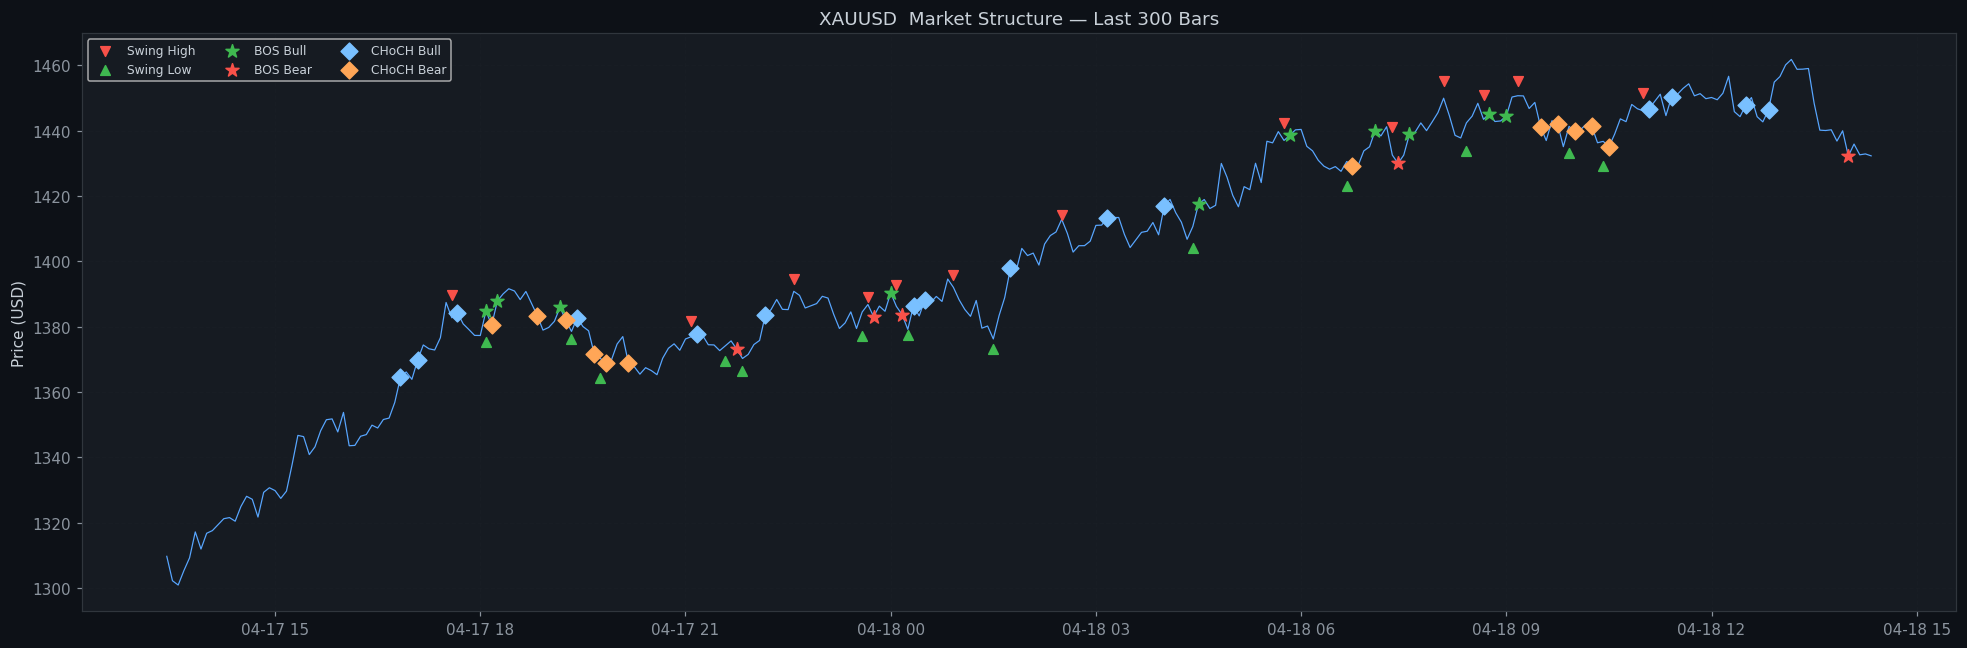

In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.5  MARKET STRUCTURE VISUALISATION
# ──────────────────────────────────────────────────────────────────────────────

_vis = df.tail(300).copy().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(_vis['datetime'], _vis['close'], color=NEUT_COLOR, lw=0.8, zorder=2)

# Swing Highs / Lows
sh_idx = _vis[_vis['is_swing_high']]
sl_idx = _vis[_vis['is_swing_low']]
ax.scatter(sh_idx['datetime'], sh_idx['high'],  marker='v', color=BEAR_COLOR, s=40, zorder=4, label='Swing High')
ax.scatter(sl_idx['datetime'], sl_idx['low'],   marker='^', color=BULL_COLOR, s=40, zorder=4, label='Swing Low')

# BOS
bos_b = _vis[_vis['is_bos_bull']]
bos_r = _vis[_vis['is_bos_bear']]
ax.scatter(bos_b['datetime'], bos_b['close'], marker='*', color=BULL_COLOR, s=80, zorder=5, label='BOS Bull')
ax.scatter(bos_r['datetime'], bos_r['close'], marker='*', color=BEAR_COLOR, s=80, zorder=5, label='BOS Bear')

# CHoCH
choch_b = _vis[_vis['is_choch_bull']]
choch_r = _vis[_vis['is_choch_bear']]
ax.scatter(choch_b['datetime'], choch_b['close'], marker='D', color='#79c0ff', s=60, zorder=5, label='CHoCH Bull')
ax.scatter(choch_r['datetime'], choch_r['close'], marker='D', color='#ffa657', s=60, zorder=5, label='CHoCH Bear')

ax.set_title(f'{TICKER}  Market Structure — Last 300 Bars', fontsize=12)
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=8, ncol=3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## Section 7 — Context Enrichment

Additional context features: premium/discount zone (0–100 normalised price within rolling range), VWAP deviation bands, Fibonacci levels relative to last swing, and composite session-weighted volume.


In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# 7.1  PREMIUM / DISCOUNT ZONES (0–100 NORMALISED)
# ──────────────────────────────────────────────────────────────────────────────

LOOKBACK_RANGE = 100   # candles to define the equilibrium range

df['range_high'] = df['high'].rolling(LOOKBACK_RANGE).max()
df['range_low']  = df['low'].rolling(LOOKBACK_RANGE).min()
df['range_pct']  = (df['close'] - df['range_low']) / (
    (df['range_high'] - df['range_low']).replace(0, np.nan)
)   # 0 = deep discount, 1 = deep premium

df['in_premium']  = (df['range_pct'] > 0.618).astype(int)
df['in_discount'] = (df['range_pct'] < 0.382).astype(int)
df['in_equilibrium'] = (
    (df['range_pct'] >= 0.382) & (df['range_pct'] <= 0.618)
).astype(int)

print("✓  Premium/Discount/Equilibrium zones computed.")

# ──────────────────────────────────────────────────────────────────────────────
# 7.2  FIBONACCI DISTANCE FROM LAST SWING
# ──────────────────────────────────────────────────────────────────────────────

FIB_LEVELS = [0.236, 0.382, 0.5, 0.618, 0.786]

# Track last swing high and low prices
df['last_sh_price'] = np.nan
df['last_sl_price'] = np.nan
_lsh = np.nan; _lsl = np.nan

for idx, row in df.iterrows():
    if row['is_swing_high']:
        _lsh = row['high']
    if row['is_swing_low']:
        _lsl = row['low']
    df.at[idx, 'last_sh_price'] = _lsh
    df.at[idx, 'last_sl_price'] = _lsl

# Fib distance from current close to each key level
fib_range = df['last_sh_price'] - df['last_sl_price']
for fib in FIB_LEVELS:
    fib_price = df['last_sl_price'] + fib * fib_range
    df[f'fib_{int(fib*1000)}_dist'] = (df['close'] - fib_price) / df['atr'].replace(0, np.nan)

print("✓  Fibonacci distance features computed.")

# ──────────────────────────────────────────────────────────────────────────────
# 7.3  CONFLUENCE SCORE (HOW MANY BULLISH FACTORS ALIGN)
# ──────────────────────────────────────────────────────────────────────────────

df['bull_confluence'] = (
    df['is_bullish_trend'].astype(int) +
    df['htf_bullish'].fillna(0).astype(int) +
    df['macd_cross'].astype(int) +
    df['ema_20_50_cross'].astype(int) +
    df['in_discount'].astype(int) +
    (df['rsi'] < 40).astype(int) +
    (df['vwap_dist'] < 0).astype(int)
)

df['bear_confluence'] = (
    (~df['is_bullish_trend']).astype(int) +
    (1 - df['htf_bullish'].fillna(0).astype(int)) +
    (1 - df['macd_cross'].astype(int)) +
    (1 - df['ema_20_50_cross'].astype(int)) +
    df['in_premium'].astype(int) +
    (df['rsi'] > 60).astype(int) +
    (df['vwap_dist'] > 0).astype(int)
)

print("✓  Confluence scores computed.")
print(f"   Avg Bull Confluence: {df['bull_confluence'].mean():.2f}")
print(f"   Avg Bear Confluence: {df['bear_confluence'].mean():.2f}")


✓  Premium/Discount/Equilibrium zones computed.
✓  Fibonacci distance features computed.
✓  Confluence scores computed.
   Avg Bull Confluence: 3.10
   Avg Bear Confluence: 3.10


## Section 8 — Lookback Feature Matrix Construction

For each of the `N=3` most recent occurrences of every structural event (Swing High, Swing Low, BOS Bull/Bear, CHoCH Bull/Bear, OB Bull/Bear), we compute:

- `_bars_ago` — distance in bars from current row
- `_raw_dist` — raw price distance from event close
- `_atr_dist` — ATR-normalised distance (scale-invariant)
- `_is_filled` — (Order Blocks only) whether the OB zone has been touched

> **Design principle:** These N-deep snapshots give the model a temporal "memory" of structure without look-ahead bias, since all features are computed relative to the current bar using only past data.


In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# 8.1  STANDARD LOOKBACK BUILDER (BOS, CHoCH, Swings)
# ──────────────────────────────────────────────────────────────────────────────

def build_lookback_features(df, event_col, prefix, n, extra_cols=None):
    """
    For each bar, looks back at the last N occurrences of event_col == True
    and records distance (bars, raw, ATR) to each event. Optionally carries
    forward scalar columns from the event row (e.g., swing_strength).

    Parameters
    ----------
    df         : pd.DataFrame  — full dataset (already indexed 0…M)
    event_col  : str           — boolean column marking event bars
    prefix     : str           — column name prefix for output features
    n          : int           — number of past events to encode
    extra_cols : list[str]     — additional scalar cols to copy from event row

    Returns
    -------
    pd.DataFrame with feature columns, same index as df
    """
    # Build event registry with integer positional index
    events = []
    for i, row in df.iterrows():
        if row[event_col]:
            ev = {'pos': df.index.get_loc(i), 'close': row['close']}
            if extra_cols:
                for c in extra_cols:
                    ev[c] = row[c]
            events.append(ev)

    feature_rows = []
    for i, (idx, row) in enumerate(df.iterrows()):
        cur_atr  = row['atr'] if (not np.isnan(row['atr']) and row['atr'] > 0) else 1
        past_evs = [e for e in events if e['pos'] < i][::-1]  # most recent first

        feat = {}
        for k in range(1, n + 1):
            pfx = f'{prefix}{k}'
            if k - 1 < len(past_evs):
                ev  = past_evs[k - 1]
                feat[f'{pfx}_bars_ago'] = i - ev['pos']
                feat[f'{pfx}_raw_dist'] = round(row['close'] - ev['close'], 5)
                feat[f'{pfx}_atr_dist'] = round((row['close'] - ev['close']) / cur_atr, 4)
                if extra_cols:
                    for c in extra_cols:
                        feat[f'{pfx}_{c}'] = ev[c]
            else:
                feat[f'{pfx}_bars_ago'] = np.nan
                feat[f'{pfx}_raw_dist'] = np.nan
                feat[f'{pfx}_atr_dist'] = np.nan
                if extra_cols:
                    for c in extra_cols:
                        feat[f'{pfx}_{c}'] = np.nan
        feature_rows.append(feat)

    return pd.DataFrame(feature_rows, index=df.index)


print("✓  Standard lookback builder ready.")


✓  Standard lookback builder ready.


In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# 8.2  ENHANCED OB LOOKBACK BUILDER (WITH FILL-STATUS)
# ──────────────────────────────────────────────────────────────────────────────

def build_ob_lookback_features(df, event_col, prefix, n, top_col, bot_col):
    """
    Specialised version for Order Blocks. In addition to bars_ago / raw_dist /
    atr_dist, it checks whether the OB price zone has been revisited (filled)
    by any candle between the OB creation bar and the current bar.
    """
    events = []
    for i, row in df.iterrows():
        if row[event_col]:
            events.append({
                'pos':   df.index.get_loc(i),
                'close': row['close'],
                'top':   row[top_col],
                'bot':   row[bot_col]
            })

    feature_rows = []
    is_bull_ob = 'bull' in prefix

    for i, (idx, row) in enumerate(df.iterrows()):
        cur_atr  = row['atr'] if (not np.isnan(row['atr']) and row['atr'] > 0) else 1
        past_evs = [e for e in events if e['pos'] < i][::-1]

        feat = {}
        for k in range(1, n + 1):
            pfx = f'{prefix}{k}'
            if k - 1 < len(past_evs):
                ev      = past_evs[k - 1]
                window  = df.iloc[ev['pos'] + 1 : i + 1]
                is_filled = False
                if not window.empty and ev['top'] is not None:
                    if is_bull_ob:
                        is_filled = window['low'].min() <= ev['top']
                    else:
                        is_filled = window['high'].max() >= ev['bot']

                feat[f'{pfx}_bars_ago']  = i - ev['pos']
                feat[f'{pfx}_raw_dist']  = round(row['close'] - ev['close'], 5)
                feat[f'{pfx}_atr_dist']  = round((row['close'] - ev['close']) / cur_atr, 4)
                feat[f'{pfx}_is_filled'] = int(is_filled)
            else:
                feat[f'{pfx}_bars_ago']  = np.nan
                feat[f'{pfx}_raw_dist']  = np.nan
                feat[f'{pfx}_atr_dist']  = np.nan
                feat[f'{pfx}_is_filled'] = 0
        feature_rows.append(feat)

    return pd.DataFrame(feature_rows, index=df.index)


print("✓  Order Block lookback builder ready.")


✓  Order Block lookback builder ready.


In [21]:
# ──────────────────────────────────────────────────────────────────────────────
# 8.3  BUILD ALL FEATURE BLOCKS
# ──────────────────────────────────────────────────────────────────────────────

print(f"Building lookback feature blocks for N={N}...")
t0 = time.time()

print("  → Swing Highs  (+ strength & reversal probability)...")
feat_sh = build_lookback_features(
    df, 'is_swing_high', 'sh_', N,
    extra_cols=['swing_strength', 'reversal_prob']
)

print("  → Swing Lows   (+ strength & reversal probability)...")
feat_sl = build_lookback_features(
    df, 'is_swing_low', 'sl_', N,
    extra_cols=['swing_strength', 'reversal_prob']
)

print("  → BOS Bullish...")
feat_bos_bull  = build_lookback_features(df, 'is_bos_bull',   'bos_bull_',  N)

print("  → BOS Bearish...")
feat_bos_bear  = build_lookback_features(df, 'is_bos_bear',   'bos_bear_',  N)

print("  → CHoCH Bullish...")
feat_choch_bull = build_lookback_features(df, 'is_choch_bull', 'choch_bull_', N)

print("  → CHoCH Bearish...")
feat_choch_bear = build_lookback_features(df, 'is_choch_bear', 'choch_bear_', N)

print("  → Order Blocks — Bullish (with fill detection)...")
feat_ob_bull = build_ob_lookback_features(
    df, 'is_ob_bull', 'ob_bull_', N, 'ob_bull_top', 'ob_bull_bot'
)

print("  → Order Blocks — Bearish (with fill detection)...")
feat_ob_bear = build_ob_lookback_features(
    df, 'is_ob_bear', 'ob_bear_', N, 'ob_bear_top', 'ob_bear_bot'
)

elapsed = time.time() - t0
print(f"\n✓  All {8} feature blocks built in {elapsed:.1f}s.")


Building lookback feature blocks for N=3...
  → Swing Highs  (+ strength & reversal probability)...
  → Swing Lows   (+ strength & reversal probability)...
  → BOS Bullish...
  → BOS Bearish...
  → CHoCH Bullish...
  → CHoCH Bearish...
  → Order Blocks — Bullish (with fill detection)...
  → Order Blocks — Bearish (with fill detection)...

✓  All 8 feature blocks built in 33.5s.


## Section 9 — Dataset Assembly & Target Labeling

### 9.1 Assemble Feature Matrix
We concatenate the base feature columns, all N-deep lookback blocks, and enrichment features into one unified dataset.

### 9.2 Triple Barrier Labeling
The target variable is generated using the **Triple Barrier Method**: for each bar, we scan the next `LOOKAHEAD` bars to determine if price hits a Take-Profit (2 × ATR) or Stop-Loss (1 × ATR) first. This yields a three-class label: **+1 (Bull)**, **-1 (Bear)**, **0 (Neutral/timeout)**.


In [22]:
# ──────────────────────────────────────────────────────────────────────────────
# 9.1  RE-ASSEMBLE FULL DATASET (Ensuring All Engineered Blocks are Included)
# ──────────────────────────────────────────────────────────────────────────────

# Identify all feature groups generated in previous sections
lookback_dfs = [
    feat_sh, feat_sl, feat_bos_bull, feat_bos_bear,
    feat_choch_bull, feat_choch_bear, feat_ob_bull, feat_ob_bear
]

# Concatenate the base df with all lookback blocks
# Note: ma_feat_block was already joined in Section 4.3, but we ensure it's here
dataset = pd.concat([df] + lookback_dfs, axis=1)

# Final check for duplicate columns
dataset = dataset.loc[:, ~dataset.columns.duplicated()]

# Update the split variable to use the fully enriched dataset
dataset_for_split = dataset.copy()

print(f"✓ Dataset re-assembled with all SMC and Relational features.")
print(f"  Total Rows    : {dataset.shape[0]:,}")
print(f"  Total Columns : {dataset.shape[1]}")

✓ Dataset re-assembled with all SMC and Relational features.
  Total Rows    : 10,000
  Total Columns : 376


In [23]:
# ──────────────────────────────────────────────────────────────────────────────
# 9.2  TRIPLE BARRIER TARGET LABELING  (MFE / MAE Quality-Gated)
# ──────────────────────────────────────────────────────────────────────────────
#
# Quality gates per direction (long & short run fully independently):
#
#   Gate A  ─ Clean move  : TP hit  AND  MAE at TP-touch ≤ mae_gate × SL_dist
#   Gate B  ─ Armed move  : MFE crossed mfe_gate × TP_dist at any j BEFORE
#                           TP was hit  →  label candidate is ARMED (held);
#                           trade accepted if TP subsequently arrives
#
#   SL hit while armed but TP never reached  →  still rejected (label 0)
#
# Outputs
#   labels  : +1 Bull | -1 Bear | 0 Neutral
#   quality : MFE / MAE ratio at the moment TP was hit  (NaN for label-0 bars)
#             use as sample_weight in XGB / LGBM training
# ──────────────────────────────────────────────────────────────────────────────

def triple_barrier_labels(
    df,
    lookahead : int   = 5,
    rr        : float = 2.0,
    mae_gate  : float = 0.5,   # Gate A: MAE must be ≤ this fraction of SL_dist
    mfe_gate  : float = 0.5,   # Gate B: MFE must cross this fraction of TP_dist to arm
):
    """
    Parameters
    ----------
    df        : DataFrame with columns  close | high | low | atr
    lookahead : max bars to scan forward
    rr        : TP = ATR × rr,  SL = ATR × 1.0
    mae_gate  : fraction of SL_dist;  MAE ≤ threshold  →  Gate A passes
    mfe_gate  : fraction of TP_dist;  MFE ≥ threshold  →  trade ARMED (Gate B)

    Returns
    -------
    labels  : pd.Series  int   {-1, 0, +1}
    quality : pd.Series  float  MFE/MAE ratio at TP hit (NaN where label == 0)
    """
    closes = df['close'].values
    highs  = df['high'].values
    lows   = df['low'].values
    atrs   = df['atr'].values
    n      = len(df)

    labels  = np.zeros(n, dtype=int)
    quality = np.full(n, np.nan)

    for i in range(n - lookahead):
        if np.isnan(atrs[i]) or atrs[i] == 0:
            continue

        entry   = closes[i]
        tp_dist = atrs[i] * rr
        sl_dist = atrs[i] * 1.0

        # ── per-direction state ──────────────────────────────────────────────
        #   outcome:  0 = open  |  1 = quality-accepted  |  -1 = rejected
        l_mae, l_mfe = 0.0, 0.0;  l_armed = False;  l_outcome = 0;  l_done = False
        s_mae, s_mfe = 0.0, 0.0;  s_armed = False;  s_outcome = 0;  s_done = False

        for j in range(1, lookahead + 1):
            if i + j >= n:
                break

            h = highs[i + j]
            l = lows[i + j]

            # ── LONG ────────────────────────────────────────────────────────
            if not l_done:
                l_mae = max(l_mae, entry - l)      # price moved below entry
                l_mfe = max(l_mfe, h - entry)      # price moved above entry

                if l_mfe >= mfe_gate * tp_dist:    # Gate B arm check
                    l_armed = True

                if h >= entry + tp_dist:           # TP barrier touched
                    gate_a = l_mae <= mae_gate * sl_dist
                    gate_b = l_armed
                    l_outcome = 1 if (gate_a or gate_b) else 0
                    l_done = True

                elif l <= entry - sl_dist:         # SL barrier touched
                    l_outcome = -1
                    l_done = True

            # ── SHORT ───────────────────────────────────────────────────────
            if not s_done:
                s_mae = max(s_mae, h - entry)      # price moved above entry
                s_mfe = max(s_mfe, entry - l)      # price moved below entry

                if s_mfe >= mfe_gate * tp_dist:    # Gate B arm check
                    s_armed = True

                if l <= entry - tp_dist:           # TP barrier touched
                    gate_a = s_mae <= mae_gate * sl_dist
                    gate_b = s_armed
                    s_outcome = 1 if (gate_a or gate_b) else 0
                    s_done = True

                elif h >= entry + sl_dist:         # SL barrier touched
                    s_outcome = -1
                    s_done = True

            if l_done and s_done:
                break

        # ── label assignment (conflicts → 0) ─────────────────────────────
        if l_outcome == 1 and s_outcome != 1:
            labels[i]  = 1
            quality[i] = min(l_mfe / l_mae, 10.0) if l_mae > 1e-9 else 10.0

        elif s_outcome == 1 and l_outcome != 1:
            labels[i]  = -1
            quality[i] = min(s_mfe / s_mae, 10.0) if s_mae > 1e-9 else 10.0

        # else: 0  (timeout | quality failed | conflicting)

    return (
        pd.Series(labels,  index=df.index, name='smart_target'),
        pd.Series(quality, index=df.index, name='mfe_mae_ratio'),
    )


# ── run ───────────────────────────────────────────────────────────────────────
dataset['smart_target'], dataset['mfe_mae_ratio'] = triple_barrier_labels(
    dataset, LOOKAHEAD, RISK_REWARD
)

dist = dataset['smart_target'].value_counts().sort_index()

print("✓  Triple Barrier Labels computed  (MFE/MAE Quality-Gated):")
print(f"   Bear    (-1) : {dist.get(-1, 0):>7,}  ({dist.get(-1, 0)/len(dataset)*100:5.1f}%)")
print(f"   Neutral ( 0) : {dist.get( 0, 0):>7,}  ({dist.get( 0, 0)/len(dataset)*100:5.1f}%)")
print(f"   Bull    (+1) : {dist.get( 1, 0):>7,}  ({dist.get( 1, 0)/len(dataset)*100:5.1f}%)")
print()
print("   Quality  (MFE/MAE ratio) — labelled bars only:")
q = dataset.loc[dataset['smart_target'] != 0, 'mfe_mae_ratio']
print(f"   mean={q.mean():.2f}  median={q.median():.2f}  "
      f"p25={q.quantile(0.25):.2f}  p75={q.quantile(0.75):.2f}")

✓  Triple Barrier Labels computed  (MFE/MAE Quality-Gated):
   Bear    (-1) :   3,227  ( 32.3%)
   Neutral ( 0) :   3,436  ( 34.4%)
   Bull    (+1) :   3,337  ( 33.4%)

   Quality  (MFE/MAE ratio) — labelled bars only:
   mean=6.57  median=6.30  p25=3.64  p75=10.00


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 9.3  SIGNAL VISUALISATION — Price + Triple Barrier Labels
# ──────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

def plot_signals(
    df,
    label_col   : str = 'smart_target',
    quality_col : str = 'mfe_mae_ratio',
    atr_col     : str = 'atr',
    n_bars      : int = 300,        # how many recent bars to show
    rr          : float = 2.0,
    start_idx   : int  = None,      # override: plot from this integer position
    figsize     : tuple = (22, 11),
):
    """
    Three-panel plot:
      Top    : Candlestick price  +  TP/SL cones  +  signal arrows
      Middle : MFE/MAE quality ratio for labelled bars (bar chart)
      Bottom : Label distribution rolling 50-bar window
    """

    # ── slice ─────────────────────────────────────────────────────────────────
    si = start_idx if start_idx is not None else max(0, len(df) - n_bars)
    ei = min(si + n_bars, len(df))
    d  = df.iloc[si:ei].copy().reset_index(drop=False)   # keep original index as col
    x  = np.arange(len(d))

    bulls  = d[d[label_col] ==  1]
    bears  = d[d[label_col] == -1]

    # ── colour map for quality ────────────────────────────────────────────────
    qnorm  = Normalize(vmin=1, vmax=5, clip=True)
    q_cmap = plt.cm.RdYlGn

    # ── figure layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize, facecolor='#0d1117')
    gs  = gridspec.GridSpec(3, 1, height_ratios=[5, 1.5, 1],
                            hspace=0.06, figure=fig)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)

    for ax in [ax1, ax2, ax3]:
        ax.set_facecolor('#0d1117')
        ax.tick_params(colors='#8b949e', labelsize=8)
        ax.spines[:].set_color('#30363d')

    # ══════════════════════════════════════════════════════════════════════════
    # PANEL 1 — Candlesticks
    # ══════════════════════════════════════════════════════════════════════════
    UP   = d['close'] >= d['open']
    col_up, col_dn = '#26a641', '#f85149'

    # wicks
    ax1.vlines(x[UP],  d.loc[UP,  'low'],  d.loc[UP,  'high'],
               color=col_up, linewidth=0.8, alpha=0.7)
    ax1.vlines(x[~UP], d.loc[~UP, 'low'],  d.loc[~UP, 'high'],
               color=col_dn, linewidth=0.8, alpha=0.7)
    # bodies
    ax1.bar(x[UP],   d.loc[UP,   'close'] - d.loc[UP,   'open'],
            bottom=d.loc[UP,   'open'],
            color=col_up, width=0.7, alpha=0.85)
    ax1.bar(x[~UP],  d.loc[~UP,  'open']  - d.loc[~UP,  'close'],
            bottom=d.loc[~UP,  'close'],
            color=col_dn, width=0.7, alpha=0.85)

    # ── TP / SL cones at each signal ─────────────────────────────────────────
    def draw_cone(row, xi, direction):
        entry   = row['close']
        atr     = row[atr_col]
        tp_d    = atr * rr
        sl_d    = atr * 1.0
        sign    = 1 if direction == 'bull' else -1
        c_tp    = '#26a641' if direction == 'bull' else '#f85149'
        c_sl    = '#f85149' if direction == 'bull' else '#26a641'

        ax1.annotate('', xy=(xi + 4, entry + sign * tp_d),
                     xytext=(xi, entry),
                     arrowprops=dict(arrowstyle='->', color=c_tp,
                                     lw=1.1, alpha=0.45))
        ax1.annotate('', xy=(xi + 4, entry - sign * sl_d),
                     xytext=(xi, entry),
                     arrowprops=dict(arrowstyle='->', color=c_sl,
                                     lw=1.1, alpha=0.45))

    for _, row in bulls.iterrows():
        xi = int(row.name)            # position in sliced d
        draw_cone(row, xi, 'bull')

    for _, row in bears.iterrows():
        xi = int(row.name)
        draw_cone(row, xi, 'bear')

    # ── signal arrows (quality-coloured) ─────────────────────────────────────
    arrow_offset = d['atr'].mean() * 1.4

    for _, row in bulls.iterrows():
        xi  = int(row.name)
        q   = row[quality_col] if quality_col in row.index else 2.0
        c   = q_cmap(qnorm(q)) if not np.isnan(q) else '#26a641'
        ax1.annotate('▲', xy=(xi, row['low'] - arrow_offset * 0.5),
                     ha='center', va='top', fontsize=9,
                     color=c, fontweight='bold',
                     annotation_clip=False)

    for _, row in bears.iterrows():
        xi  = int(row.name)
        q   = row[quality_col] if quality_col in row.index else 2.0
        c   = q_cmap(qnorm(q)) if not np.isnan(q) else '#f85149'
        ax1.annotate('▼', xy=(xi, row['high'] + arrow_offset * 0.5),
                     ha='center', va='bottom', fontsize=9,
                     color=c, fontweight='bold',
                     annotation_clip=False)

    # colourbar for quality
    sm = ScalarMappable(cmap=q_cmap, norm=qnorm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax1, orientation='vertical',
                        pad=0.01, fraction=0.015, aspect=30)
    cbar.set_label('MFE/MAE quality', color='#8b949e', fontsize=8)
    cbar.ax.tick_params(colors='#8b949e', labelsize=7)

    # legend
    patches = [
        mpatches.Patch(color='#26a641', label=f'Bull (+1)  n={len(bulls)}'),
        mpatches.Patch(color='#f85149', label=f'Bear (-1)  n={len(bears)}'),
        mpatches.Patch(color='#484f58', label=f'Neutral (0) n={len(d) - len(bulls) - len(bears)}'),
    ]
    ax1.legend(handles=patches, loc='upper left', framealpha=0.2,
               facecolor='#161b22', edgecolor='#30363d',
               labelcolor='#c9d1d9', fontsize=8)

    ax1.set_ylabel('Price', color='#8b949e', fontsize=9)
    ax1.set_title(f'Triple Barrier  |  MFE/MAE Quality-Gated  |  '
                  f'bars {si}–{ei}  |  lookahead={LOOKAHEAD}  RR={rr}',
                  color='#c9d1d9', fontsize=11, pad=10)
    ax1.grid(axis='y', color='#21262d', linewidth=0.5)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # ══════════════════════════════════════════════════════════════════════════
    # PANEL 2 — MFE/MAE quality bars
    # ══════════════════════════════════════════════════════════════════════════
    labelled = d[d[label_col] != 0]
    q_vals   = labelled[quality_col].fillna(0).clip(0, 8)
    q_colors = [q_cmap(qnorm(v)) for v in q_vals]
    q_xi     = labelled.index.to_numpy()

    ax2.bar(q_xi, q_vals, color=q_colors, width=1.0, alpha=0.85)
    ax2.axhline(1.0, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.6,
                label='ratio = 1')
    ax2.axhline(2.0, color='#58a6ff', linewidth=0.8, linestyle='--', alpha=0.4,
                label='ratio = 2')
    ax2.set_ylabel('MFE/MAE', color='#8b949e', fontsize=8)
    ax2.set_ylim(0, 8)
    ax2.legend(loc='upper right', framealpha=0.15, facecolor='#161b22',
               edgecolor='#30363d', labelcolor='#8b949e', fontsize=7)
    ax2.grid(axis='y', color='#21262d', linewidth=0.5)
    plt.setp(ax2.get_xticklabels(), visible=False)

    # ══════════════════════════════════════════════════════════════════════════
    # PANEL 3 — Rolling label distribution
    # ══════════════════════════════════════════════════════════════════════════
    win = 50
    rb  = (d[label_col] == -1).rolling(win).mean()
    rn  = (d[label_col] ==  0).rolling(win).mean()
    ru  = (d[label_col] ==  1).rolling(win).mean()

    ax3.stackplot(x, rb, rn, ru,
                  labels=['Bear%', 'Neutral%', 'Bull%'],
                  colors=['#f85149', '#484f58', '#26a641'],
                  alpha=0.75)
    ax3.set_ylabel(f'Roll {win}b', color='#8b949e', fontsize=7)
    ax3.set_ylim(0, 1)
    ax3.set_xlabel('Bar index (in slice)', color='#8b949e', fontsize=8)
    ax3.grid(axis='y', color='#21262d', linewidth=0.5)
    ax3.legend(loc='upper right', framealpha=0.15, facecolor='#161b22',
               edgecolor='#30363d', labelcolor='#8b949e', fontsize=7,
               ncol=3)

    plt.tight_layout()
    plt.savefig('signals_plot.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print("✓  Plot saved → signals_plot.png")


# ── call ──────────────────────────────────────────────────────────────────────
plot_signals(dataset, rr=RISK_REWARD, n_bars=300)


## Section 10 — Data Cleaning & Temporal Splitting

We drop look-ahead-contaminated rows (the last `LOOKAHEAD` bars), apply a class-balancing strategy to prevent neutral-class dominance, and then split strictly along the time axis to prevent data leakage.

> **Temporal Split:** Train → Validation → OOS (never shuffle across the boundary)


In [25]:
import pandas as pd
import numpy as np

# ──────────────────────────────────────────────────────────────────────────────
# 10.1  CLEAN & BALANCE (Pre-Split)
# ──────────────────────────────────────────────────────────────────────────────

# Drop the final LOOKAHEAD rows — their labels are undefined
dataset = dataset.iloc[:-LOOKAHEAD].copy()

# Drop rows where the target is still NaN (early ATR warmup)
dataset = dataset.dropna(subset=['smart_target', 'atr', 'close'])

# Assign to raw variables before any balancing for consistent splitting
dataset_for_split = dataset.copy()
y_all_raw = dataset_for_split['smart_target']

# ─── Class Balancing: down-sample neutral to match signal count
def balance_classes(df, target_col='smart_target', seed=42):
    bulls  = df[df[target_col] ==  1]
    bears  = df[df[target_col] == -1]
    neuts  = df[df[target_col] ==  0]
    n_sig  = len(bulls) + len(bears)
    n_neut = min(len(neuts), n_sig)
    neut_s = neuts.sample(n=n_neut, random_state=seed)
    return pd.concat([bulls, bears, neut_s]).sort_index()

In [26]:
import pandas as pd
import numpy as np

# ──────────────────────────────────────────────────────────────────────────────
# 10.2  REFINED FEATURE SELECTION & TYPE CASTING
# ──────────────────────────────────────────────────────────────────────────────

# Only exclude target labels, future-lookahead info, and strings
# We keep EVERYTHING else (indicators, relational MAs, lookbacks)
NON_FEATURES = [
    'datetime', 'smart_target', 'log_ret',
    'ob_bull_top', 'ob_bull_bot', 'ob_bear_top', 'ob_bear_bot',
    'ob_bull_filled', 'ob_bear_filled',
    'range_high', 'range_low',
    'mfe_mae_ratio',
    '_date', '_tp', '_tpv', 'hour'
]

# Identify categorical columns for native XGBoost handling
CATEGORICAL_COLS = [
    'is_swing_high', 'is_swing_low', 'is_bos_bull', 'is_bos_bear',
    'is_choch_bull', 'is_choch_bear', 'is_ob_bull', 'is_ob_bear',
    'is_active_session', 'in_premium', 'in_discount', 'in_equilibrium',
    'is_bullish_trend', 'macd_cross', 'ema_20_50_cross', 'ema_50_200_cross',
    'htf_bullish', 'session', 'day_of_week'
]

# Filter features
feature_cols = [c for c in dataset_for_split.columns if c not in NON_FEATURES]

X_all_unbalanced = dataset_for_split[feature_cols].copy()

# Cast types
for col in X_all_unbalanced.columns:
    if col in CATEGORICAL_COLS:
        X_all_unbalanced[col] = X_all_unbalanced[col].fillna(0).astype(int).astype('category')
    else:
        # Ensure all numeric features are float32 for efficiency
        if X_all_unbalanced[col].dtype == 'bool':
             X_all_unbalanced[col] = X_all_unbalanced[col].astype(int)
        X_all_unbalanced[col] = pd.to_numeric(X_all_unbalanced[col], errors='coerce').astype('float32')

# Final Fill for safety
X_all_unbalanced = X_all_unbalanced.fillna(0)

print(f"✓ Feature matrix finalized.")
print(f"  Rows: {X_all_unbalanced.shape[0]:,} | Features: {X_all_unbalanced.shape[1]}")
print(f"  Categorical: {len(X_all_unbalanced.select_dtypes('category').columns)}")

✓ Feature matrix finalized.
  Rows: 9,970 | Features: 365
  Categorical: 19


In [27]:
import pandas as pd
import numpy as np

# ──────────────────────────────────────────────────────────────────────────────
# 10.3  TEMPORAL TRAIN / VALIDATION / OOS SPLIT
# ──────────────────────────────────────────────────────────────────────────────

n_total = len(X_all_unbalanced)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_oos   = n_total - n_train - n_val

X_train_unbalanced  = X_all_unbalanced.iloc[:n_train]
y_train_unbalanced  = y_all_raw.iloc[:n_train]

X_val    = X_all_unbalanced.iloc[n_train : n_train + n_val]
y_val    = y_all_raw.iloc[n_train : n_train + n_val]

X_oos    = X_all_unbalanced.iloc[n_train + n_val:]
y_oos    = y_all_raw.iloc[n_train + n_val:]

train_df_combined = pd.concat([X_train_unbalanced, y_train_unbalanced.rename('smart_target')], axis=1)
train_df_balanced = balance_classes(train_df_combined, target_col='smart_target', seed=RANDOM_SEED)

X_train = train_df_balanced.drop(columns='smart_target')
y_train = train_df_balanced['smart_target'].map({-1: 0, 0: 1, 1: 2})

y_val = y_val.map({-1: 0, 0: 1, 1: 2})
y_oos = y_oos.map({-1: 0, 0: 1, 1: 2})

# FIX 1: Dedicated Metadata for Val and OOS
meta_cols = ['datetime', 'close', 'high', 'low', 'atr', 'rsi']
X_val_meta = dataset_for_split.iloc[n_train : n_train + n_val][meta_cols].copy()
X_oos_meta = dataset_for_split.iloc[n_train + n_val:][meta_cols].copy()

print(f"✓ Temporal Split complete.")
print(f"  Val Meta Range: {X_val_meta['datetime'].min()} to {X_val_meta['datetime'].max()}")
print(f"  OOS Meta Range: {X_oos_meta['datetime'].min()} to {X_oos_meta['datetime'].max()}")

✓ Temporal Split complete.
  Val Meta Range: 2026-04-08 02:40:00 to 2026-04-13 07:10:00
  OOS Meta Range: 2026-04-13 07:15:00 to 2026-04-18 11:50:00


## Section 11 — Base Model Training

We train an XGBoost multi-class classifier with `enable_categorical=True` so that boolean/categorical structure features are handled natively without one-hot encoding. Initial hyperparameters are set conservatively; fine-tuning follows in Section 15.


In [28]:
# ──────────────────────────────────────────────────────────────────────────────
# 11.1  TRAIN BASE XGBOOST CLASSIFIER
# ──────────────────────────────────────────────────────────────────────────────

BASE_PARAMS = dict(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.03,
    subsample         = 0.80,
    colsample_bytree  = 0.80,
    min_child_weight  = 5,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    enable_categorical= True,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = RANDOM_SEED,
    n_jobs            = -1,
)

model_base = xgb.XGBClassifier(**BASE_PARAMS)

print("Training base XGBoost model...")
t0 = time.time()
model_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
print(f"✓  Base model trained in {time.time()-t0:.1f}s")
print(f"   Training samples : {n_train:,}  |  Features: {X_train.shape[1]}")


Training base XGBoost model...
✓  Base model trained in 31.3s
   Training samples : 6,979  |  Features: 365


## Section 12 — Base Model Evaluation (In-Sample & Validation)

Classification report, confusion matrix, multi-class ROC curves, and top-20 feature importances for the base model evaluated on the validation set.


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 11.2  SAVE BASE MODEL
# ──────────────────────────────────────────────────────────────────────────────
import joblib
import os
from datetime import datetime

# Create models directory if it doesn't exist
models_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'models')
os.makedirs(models_dir, exist_ok=True)

# Save with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = os.path.join(models_dir, f"xgboost_base_model_{timestamp}.pkl")

joblib.dump(model_base, model_path)

print(f"✓  Base model saved to: {model_path}")
print(f"   File size: {os.path.getsize(model_path) / (1024*1024):.2f} MB")

In [35]:
# ──────────────────────────────────────────────────────────────────────────────
# 12.1  VALIDATION SET PREDICTIONS & CLASSIFICATION REPORT
# ──────────────────────────────────────────────────────────────────────────────

y_val_pred  = model_base.predict(X_val)
y_val_proba = model_base.predict_proba(X_val)

print("Base Model — Validation Set Report")
print("=" * 55)
print(classification_report(y_val, y_val_pred, target_names=['Bear', 'Neutral', 'Bull']))


Base Model — Validation Set Report
              precision    recall  f1-score   support

        Bear       0.43      0.48      0.45       483
     Neutral       0.39      0.36      0.37       508
        Bull       0.44      0.42      0.43       504

    accuracy                           0.42      1495
   macro avg       0.42      0.42      0.42      1495
weighted avg       0.42      0.42      0.42      1495



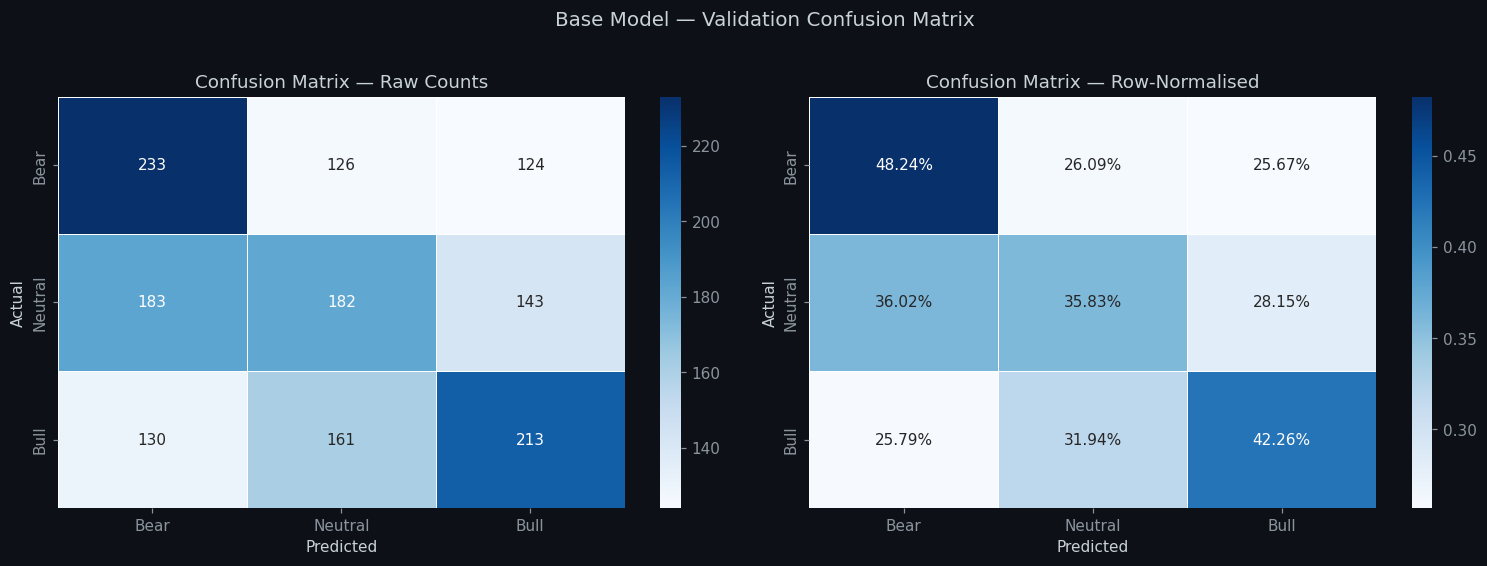

In [79]:
# ──────────────────────────────────────────────────────────────────────────────
# 12.2  CONFUSION MATRIX
# ──────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_val, y_val_pred)
labels = ['Bear', 'Neutral', 'Bull']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Raw Counts')
axes[0].set_ylabel('Actual');  axes[0].set_xlabel('Predicted')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row-Normalised')
axes[1].set_ylabel('Actual');  axes[1].set_xlabel('Predicted')

plt.suptitle('Base Model — Validation Confusion Matrix', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


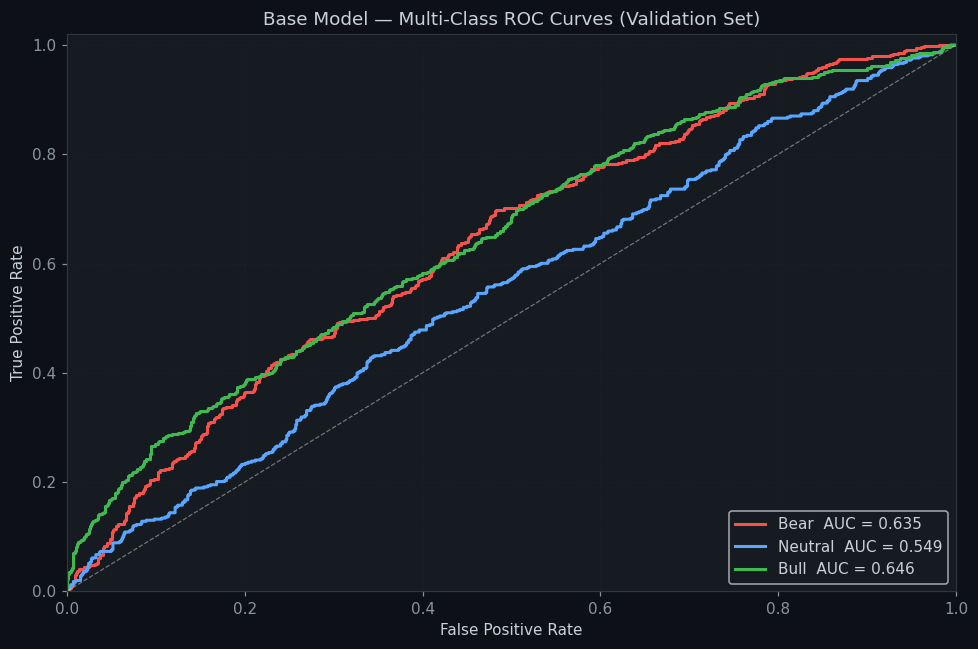

In [37]:
# ──────────────────────────────────────────────────────────────────────────────
# 12.3  MULTI-CLASS ROC CURVES
# ──────────────────────────────────────────────────────────────────────────────

y_val_bin = label_binarize(y_val, classes=[0, 1, 2])
colors    = [BEAR_COLOR, NEUT_COLOR, BULL_COLOR]

fig, ax = plt.subplots(figsize=(9, 6))

for i, (cls, col) in enumerate(zip(labels, colors)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls}  AUC = {roc_auc:.3f}')

ax.plot([0, 1], [0, 1], 'w--', lw=0.8, alpha=0.4)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Base Model — Multi-Class ROC Curves (Validation Set)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


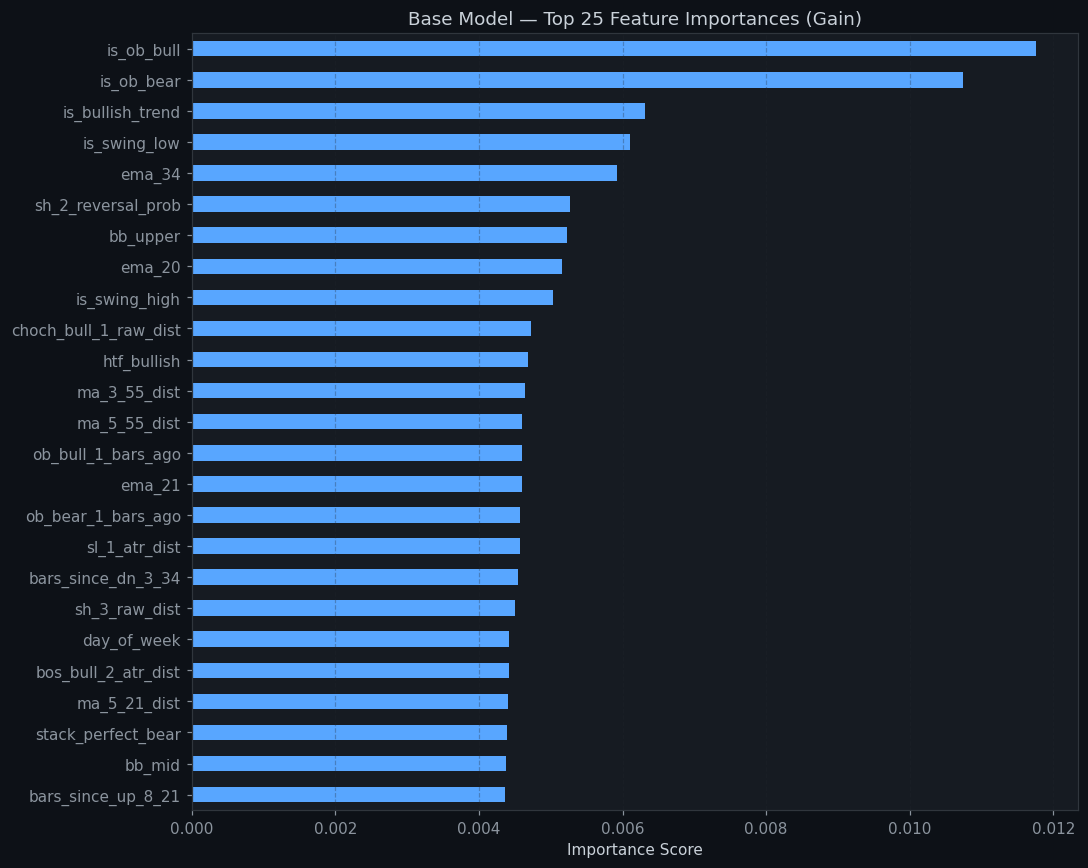

Top 10 features:
  is_ob_bull                               0.01175
  is_ob_bear                               0.01074
  is_bullish_trend                         0.00632
  is_swing_low                             0.00610
  ema_34                                   0.00592
  sh_2_reversal_prob                       0.00527
  bb_upper                                 0.00522
  ema_20                                   0.00515
  is_swing_high                            0.00504
  choch_bull_1_raw_dist                    0.00473


In [38]:
# ──────────────────────────────────────────────────────────────────────────────
# 12.4  FEATURE IMPORTANCE (TOP-25)
# ──────────────────────────────────────────────────────────────────────────────

importances = pd.Series(model_base.feature_importances_, index=X_train.columns)
top_n = importances.nlargest(25)

fig, ax = plt.subplots(figsize=(10, 8))
top_n[::-1].plot(kind='barh', ax=ax, color=NEUT_COLOR, edgecolor='none')
ax.set_title('Base Model — Top 25 Feature Importances (Gain)', fontsize=12)
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 features:")
for feat, imp in importances.nlargest(10).items():
    print(f"  {feat:<40} {imp:.5f}")


## Section 13 — Base Model Backtesting

We run a vectorised simulation applying Triple Barrier logic: for each bar where the model's predicted class probability exceeds `prob_threshold`, we enter a trade and track price for `max_bars` to see if TP or SL is hit. Equity curve and Profit Factor are reported.


In [39]:
def run_backtest(
    df_feats, df_meta, y_probs,
    tp_mult=2.0, sl_mult=1.0, max_bars=60, prob_threshold=0.40,
    slippage_atr=0.05
):
    """
    Serial Triple-Barrier backtest with logic fixes for timeout,
    same-bar conflicts, and realistic fills.
    """
    closes = df_meta['close'].values
    highs  = df_meta['high'].values
    lows   = df_meta['low'].values
    atrs   = df_meta['atr'].values

    results = []
    n = len(y_probs)
    i = 0

    while i < n:
        p_bear, p_neut, p_bull = y_probs[i]

        if p_bull > prob_threshold and p_bull >= p_bear:
            signal = 1
        elif p_bear > prob_threshold and p_bear > p_bull:
            signal = -1
        else:
            i += 1
            continue

        atr_i = atrs[i] if not np.isnan(atrs[i]) and atrs[i] > 0 else 1e-5
        entry = closes[i]

        # FIX 7: Removed Dynamic TP (Stick to trained labels)
        tp_price = entry + signal * tp_mult * atr_i
        sl_price = entry - signal * sl_mult * atr_i

        outcome = 0
        exit_price = entry
        bars_held = max_bars

        for j in range(1, max_bars + 1):
            if i + j >= n:
                bars_held = n - i - 1
                exit_price = closes[i + bars_held]
                break

            h, l = highs[i + j], lows[i + j]
            tp_hit = (signal == 1 and h >= tp_price) or (signal == -1 and l <= tp_price)
            sl_hit = (signal == 1 and l <= sl_price) or (signal == -1 and h >= sl_price)

            # FIX 6: Conservative same-bar resolution (SL wins)
            if tp_hit and sl_hit:
                outcome, exit_price, bars_held = -1, sl_price, j
                break
            elif tp_hit:
                outcome, exit_price, bars_held = 1, tp_price, j
                break
            elif sl_hit:
                outcome, exit_price, bars_held = -1, sl_price, j
                break

            # Final bar timeout
            if j == max_bars:
                exit_price = closes[i + j]
                outcome = 1 if (signal * (exit_price - entry) > 0) else -1

        # FIX 5 & 10: Calculate raw PnL and subtract slippage
        raw_pnl_pts = signal * (exit_price - entry)
        slippage = slippage_atr * atr_i
        net_pnl_atr = (raw_pnl_pts - slippage) / atr_i

        results.append({
            'signal': signal, 'entry': entry, 'exit': exit_price,
            'outcome': outcome, 'pnl': net_pnl_atr,
            'bars_held': bars_held, 'entry_idx': i
        })
        i += max(1, bars_held)

    return pd.DataFrame(results)

In [40]:
# ──────────────────────────────────────────────────────────────────────────────
# 13.2  RUN FIXED BASE MODEL BACKTEST (VALIDATION SET)
# ──────────────────────────────────────────────────────────────────────────────

y_prob_val = model_base.predict_proba(X_val)
# FIX 4: tp_mult/sl_mult now match labeling (2.0/1.0)
base_bt = run_backtest(X_val, X_val_meta, y_prob_val,
                       tp_mult=2.0, sl_mult=1.0, prob_threshold=0.52)

if not base_bt.empty:
    metrics = calc_risk_metrics(base_bt['pnl'].values, base_bt, X_val_meta)
    print(f"Base Model Validation Results (FIXED)")
    print(f"Net PnL: {base_bt['pnl'].sum():.2f} | Sharpe: {metrics['Sharpe']} | MDD: {metrics['MDD']}")
else:
    print("No trades generated.")

NameError: name 'calc_risk_metrics' is not defined

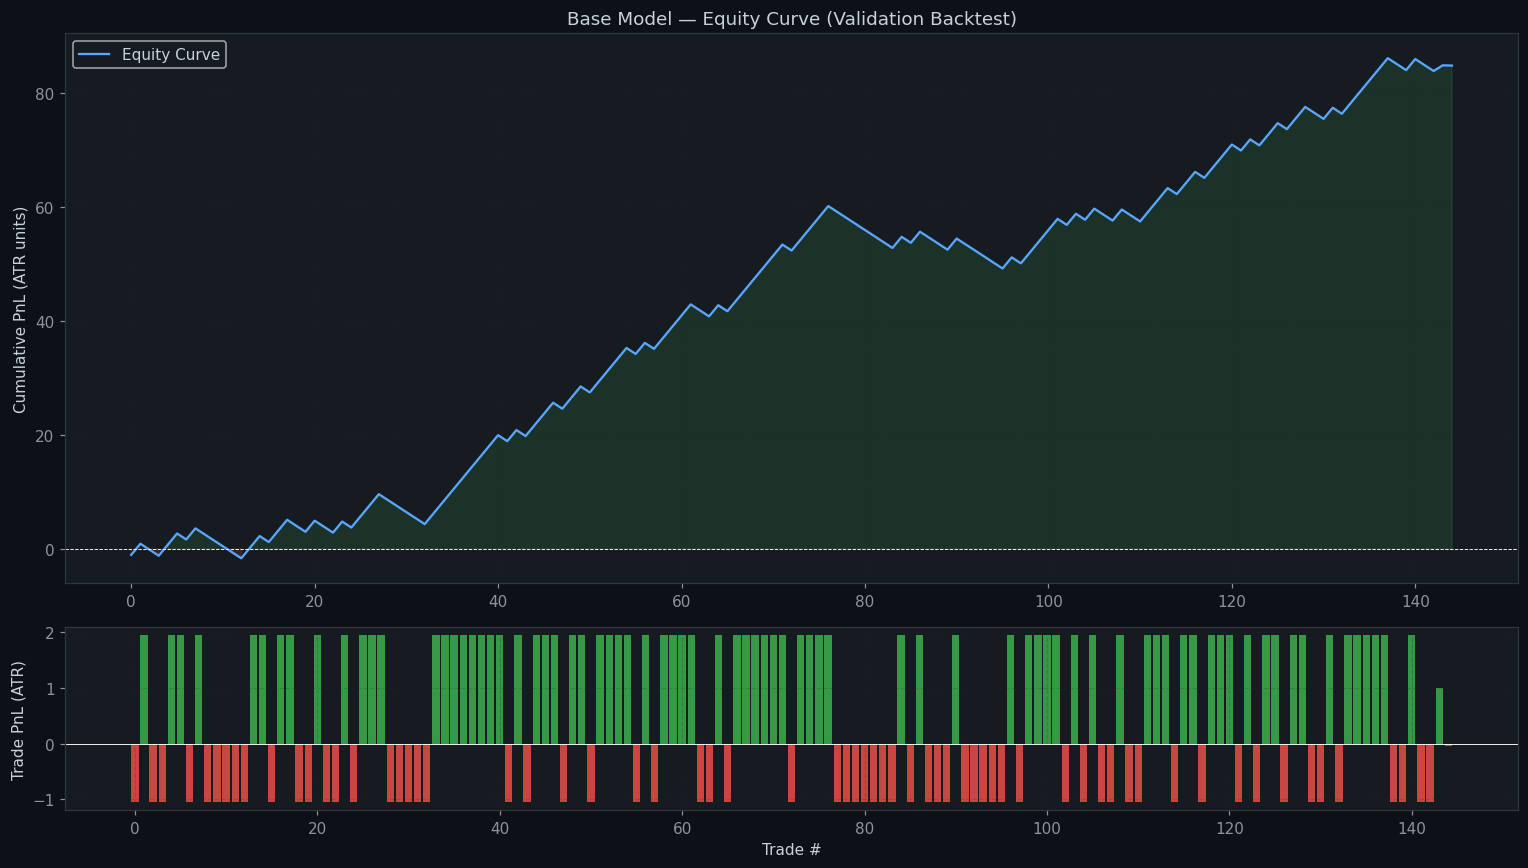

In [41]:
# ──────────────────────────────────────────────────────────────────────────────
# 13.3  BASE MODEL EQUITY CURVE
# ──────────────────────────────────────────────────────────────────────────────

if not base_bt.empty:
    equity = base_bt['pnl'].cumsum()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Equity curve
    axes[0].plot(equity.values, color=BASE_COLOR, lw=1.5, label='Equity Curve')
    axes[0].fill_between(range(len(equity)), equity.values, 0,
                          where=equity.values >= 0, alpha=0.15, color=BULL_COLOR)
    axes[0].fill_between(range(len(equity)), equity.values, 0,
                          where=equity.values < 0, alpha=0.15, color=BEAR_COLOR)
    axes[0].axhline(0, color='white', lw=0.6, ls='--')
    axes[0].set_title('Base Model — Equity Curve (Validation Backtest)', fontsize=12)
    axes[0].set_ylabel('Cumulative PnL (ATR units)')
    axes[0].legend(); axes[0].grid(True, alpha=0.2)

    # Per-trade PnL
    colors_bt = [BULL_COLOR if p > 0 else BEAR_COLOR for p in base_bt['pnl']]
    axes[1].bar(range(len(base_bt)), base_bt['pnl'], color=colors_bt, alpha=0.8)
    axes[1].axhline(0, color='white', lw=0.6)
    axes[1].set_ylabel('Trade PnL (ATR)'); axes[1].set_xlabel('Trade #')
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


## Section 14 — Hyperparameter Fine-Tuning via Optuna

We use **Optuna** with a Tree-structured Parzen Estimator (TPE) sampler to search the XGBoost hyperparameter space. The objective function maximises validation AUC (macro-averaged). We run 50 trials, each evaluated on the validation set, then re-train a final model with the best parameters.


In [42]:
# ──────────────────────────────────────────────────────────────────────────────
# 14.1  DEFINE OPTUNA OBJECTIVE
# ──────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_auc_score

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 800, step=50),
        max_depth         = trial.suggest_int('max_depth', 3, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 20),
        gamma             = trial.suggest_float('gamma', 0, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        enable_categorical= True,
        use_label_encoder = False,
        eval_metric       = 'mlogloss',
        random_state      = RANDOM_SEED,
        n_jobs            = -1,
    )

    m = xgb.XGBClassifier(**params)
    # NOTE: sample_weight is NOT used here to prevent leakage from mfe_mae_ratio
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_prob = m.predict_proba(X_val)
    y_bin  = label_binarize(y_val, classes=[0, 1, 2])
    score  = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    return score


print("Starting Optuna hyperparameter search (50 trials)...")
t0 = time.time()
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)
print(f"\n✓  Search complete in {time.time()-t0:.1f}s")
print(f"   Best Macro-AUC : {study.best_value:.4f}")
print(f"   Best Params    : {study.best_params}")


Starting Optuna hyperparameter search (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-04-18 17:33:53,378] Trial 0 failed with parameters: {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.044803926826840625, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 4, 'gamma': 0.05808361216819946, 'reg_alpha': 2.9154431891537547, 'reg_lambda': 0.2537815508265665} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\PC\AppData\Local\Temp\ipykernel_38608\2033009369.py", line 27, in objective
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
  File "c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
  File "c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py", line 1599, in

KeyboardInterrupt: 

In [43]:
# ──────────────────────────────────────────────────────────────────────────────
# 14.2  TRAIN FINE-TUNED MODEL WITH BEST PARAMS
# ──────────────────────────────────────────────────────────────────────────────

ft_params = {
    **study.best_params,
    'enable_categorical': True,
    'use_label_encoder' : False,
    'eval_metric'       : 'mlogloss',
    'random_state'      : RANDOM_SEED,
    'n_jobs'            : -1,
}

model_ft = xgb.XGBClassifier(**ft_params)

print("Training fine-tuned model on Train + Validation combined...")
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

# Ensure mfe_mae_ratio is not used for weighting during final fit
t0 = time.time()
model_ft.fit(X_trainval, y_trainval, verbose=False)
print(f"✓  Fine-tuned model trained in {time.time()-t0:.1f}s")
print(f"   Train+Val samples: {len(X_trainval):,}")


ValueError: No trials are completed yet.

## Section 15 — Fine-Tuned Model Evaluation (OOS)

We now evaluate **both** models on the untouched OOS hold-out set. Classification metrics, confusion matrices, and ROC curves are compared side by side.


In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Map numerical predictions to descriptive labels and colors
prediction_map = {
    0: {'label': 'Bear',    'color': 'red'},
    1: {'label': 'Neutral', 'color': 'gray'},
    2: {'label': 'Bull',    'color': 'green'}
}

def plot_predictions_vs_close(meta_df, predictions, title):
    fig = go.Figure()

    # Add Close Price trace
    fig.add_trace(go.Scatter(
        x=meta_df['datetime'],
        y=meta_df['close'],
        mode='lines',
        name='Close Price',
        line=dict(color='lightgray', width=1)
    ))

    # Add prediction markers
    for pred_value, pred_info in prediction_map.items():
        mask = (predictions == pred_value)
        if meta_df[mask].empty: # Skip if no predictions for this category
            continue
        fig.add_trace(go.Scatter(
            x=meta_df[mask]['datetime'],
            y=meta_df[mask]['close'],
            mode='markers',
            marker=dict(
                symbol='circle' if pred_value == 1 else ('triangle-up' if pred_value == 2 else 'triangle-down'),
                size=8,
                color=pred_info['color'],
                line=dict(width=1, color='DarkSlateGrey')
            ),
            name=f'Predicted {pred_info['label']}'
        ))

    fig.update_layout(
        title_text=title,
        xaxis_rangeslider_visible=True,
        xaxis_title='Date',
        yaxis_title='Price',
        template='plotly_dark'
    )

    fig.show()

SyntaxError: f-string: unmatched '[' (557596839.py, line 38)

In [45]:
# ──────────────────────────────────────────────────────────────────────────────
# 15.1  OOS PREDICTIONS — BOTH MODELS
# ──────────────────────────────────────────────────────────────────────────────

y_oos_base_pred  = model_base.predict(X_oos)
y_oos_base_proba = model_base.predict_proba(X_oos)

y_oos_ft_pred    = model_ft.predict(X_oos)
y_oos_ft_proba   = model_ft.predict_proba(X_oos)

print("Base Model — OOS Classification Report")
print("=" * 55)
print(classification_report(y_oos, y_oos_base_pred, target_names=['Bear', 'Neutral', 'Bull']))

print("\nFine-Tuned Model — OOS Classification Report")
print("=" * 55)
print(classification_report(y_oos, y_oos_ft_pred, target_names=['Bear', 'Neutral', 'Bull']))


NameError: name 'model_ft' is not defined

In [46]:
# ──────────────────────────────────────────────────────────────────────────────
# 15.2  SIDE-BY-SIDE CONFUSION MATRICES (OOS)
# ──────────────────────────────────────────────────────────────────────────────

cm_base = confusion_matrix(y_oos, y_oos_base_pred)
cm_ft   = confusion_matrix(y_oos, y_oos_ft_pred)
labels  = ['Bear', 'Neutral', 'Bull']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title, cmap in zip(
    axes,
    [cm_base, cm_ft],
    ['Base Model (OOS)', 'Fine-Tuned Model (OOS)'],
    ['Blues', 'Greens']
):
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2%', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('OOS Confusion Matrices — Row-Normalised', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


NameError: name 'y_oos_ft_pred' is not defined

### Base Model Predictions vs. Close Price (OOS)

In [47]:
plot_predictions_vs_close(
X_oos_meta,
y_oos_base_pred,
'Base Model Predictions vs. Close Price (OOS)'
)

NameError: name 'plot_predictions_vs_close' is not defined

### Fine-Tuned Model Predictions vs. Close Price (OOS)

NameError: name 'y_oos_ft_proba' is not defined

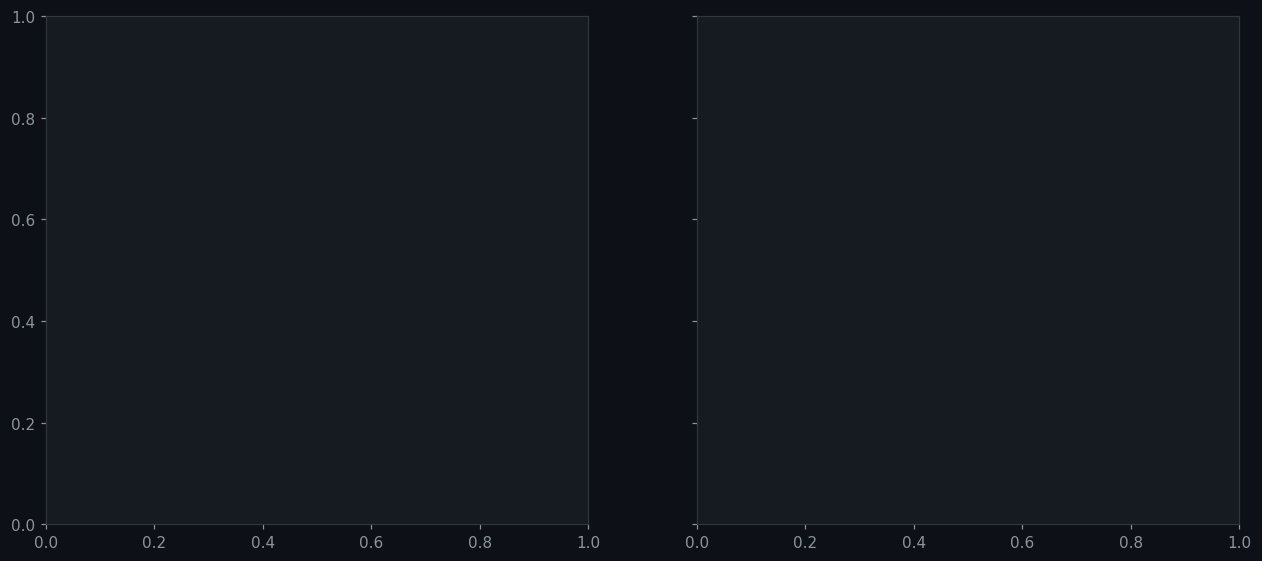

In [48]:
# ──────────────────────────────────────────────────────────────────────────────
# 15.3  OOS ROC CURVES — BOTH MODELS
# ──────────────────────────────────────────────────────────────────────────────

y_oos_bin = label_binarize(y_oos, classes=[0, 1, 2])
colors_roc = [BEAR_COLOR, NEUT_COLOR, BULL_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, proba, title in zip(
    axes,
    [y_oos_base_proba, y_oos_ft_proba],
    ['Base Model', 'Fine-Tuned Model']
):
    for i, (cls, col) in enumerate(zip(labels, colors_roc)):
        fpr, tpr, _ = roc_curve(y_oos_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls}  AUC={auc(fpr,tpr):.3f}')
    ax.plot([0,1],[0,1],'w--', lw=0.8, alpha=0.4)
    ax.set_title(f'{title} — OOS ROC', fontsize=11)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


### Fine-Tuned Model Predictions vs. Close Price (OOS)

In [49]:
plot_predictions_vs_close(
X_oos_meta,
y_oos_ft_pred,
'Fine-Tuned Model Predictions vs. Close Price (OOS)'
)

NameError: name 'plot_predictions_vs_close' is not defined

In [50]:
plot_predictions_vs_close(
X_oos_meta,
y_oos_ft_pred,
'Fine-Tuned Model Predictions vs. Close Price (OOS)'
)

NameError: name 'plot_predictions_vs_close' is not defined

NameError: name 'y_oos_ft_proba' is not defined

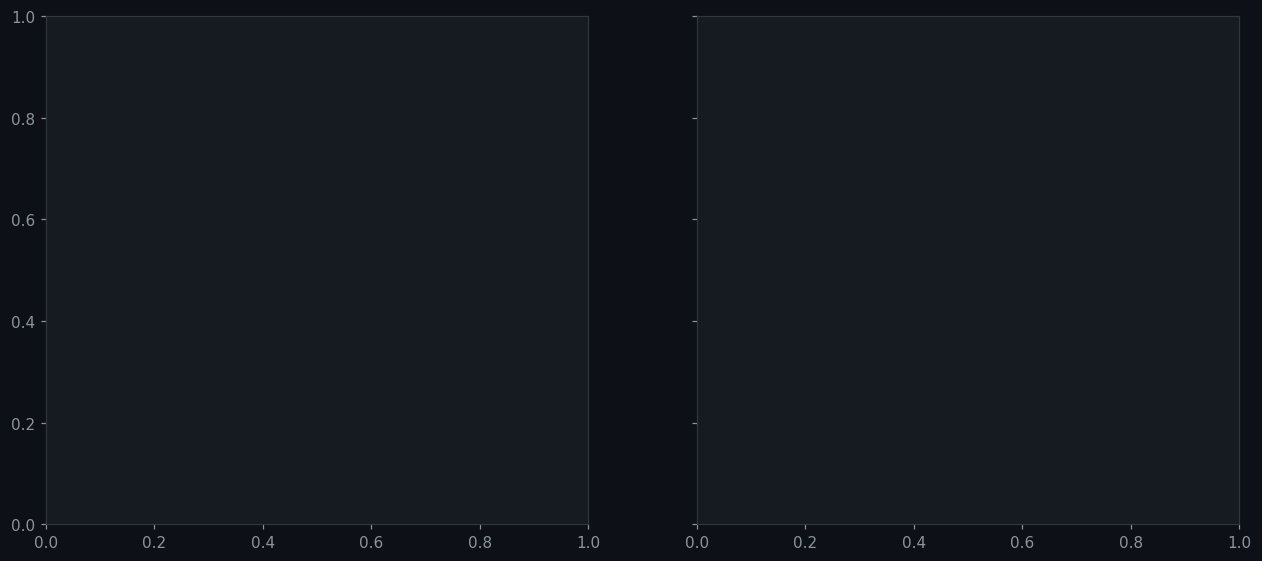

In [51]:
# ──────────────────────────────────────────────────────────────────────────────
# 15.3  OOS ROC CURVES — BOTH MODELS
# ──────────────────────────────────────────────────────────────────────────────

y_oos_bin = label_binarize(y_oos, classes=[0, 1, 2])
colors_roc = [BEAR_COLOR, NEUT_COLOR, BULL_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, proba, title in zip(
    axes,
    [y_oos_base_proba, y_oos_ft_proba],
    ['Base Model', 'Fine-Tuned Model']
):
    for i, (cls, col) in enumerate(zip(labels, colors_roc)):
        fpr, tpr, _ = roc_curve(y_oos_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls}  AUC={auc(fpr,tpr):.3f}')
    ax.plot([0,1],[0,1],'w--', lw=0.8, alpha=0.4)
    ax.set_title(f'{title} — OOS ROC', fontsize=11)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Section 16 — OOS Backtesting — Both Models

Both models are backtested on the OOS dataset using the same Triple-Barrier engine. Equity curves are compared directly.


In [52]:
# ──────────────────────────────────────────────────────────────────────────────
# 16.1  RUN OOS BACKTEST — BOTH MODELS (FIXED ENGINE)
# ──────────────────────────────────────────────────────────────────────────────

# Standardizing configuration to match training labels and include slippage
BT_CONFIG = dict(tp_mult=2.0, sl_mult=1.0, max_bars=60, prob_threshold=0.42, slippage_atr=0.05)

oos_bt_base = run_backtest(X_oos, X_oos_meta, y_oos_base_proba, **BT_CONFIG)
oos_bt_ft   = run_backtest(X_oos, X_oos_meta, y_oos_ft_proba,   **BT_CONFIG)

def bt_summary_fixed(bt, name, meta):
    if bt.empty:
        print(f"{name}: No trades generated."); return

    # Use the fixed risk metrics function for realistic annualization
    metrics = calc_risk_metrics(bt['pnl'].values, bt, meta)
    wins = (bt['outcome'] == 1).sum()
    n = len(bt)

    print(f"{name} (OOS Fixed)")
    print(f"  Trades     : {n}  |  Win Rate: {wins/n*100:.1f}%")
    print(f"  Net PnL    : {bt['pnl'].sum():.2f} ATR")
    print(f"  Sharpe     : {metrics.get('Sharpe')}")
    print(f"  Max DD     : {metrics.get('MDD')} ATR")
    print()

# Fixed: Corrected argument order (bt, name, meta)
bt_summary_fixed(oos_bt_base, "Base Model", X_oos_meta)
bt_summary_fixed(oos_bt_ft, "Fine-Tuned Model", X_oos_meta)

NameError: name 'y_oos_ft_proba' is not defined

NameError: name 'oos_bt_ft' is not defined

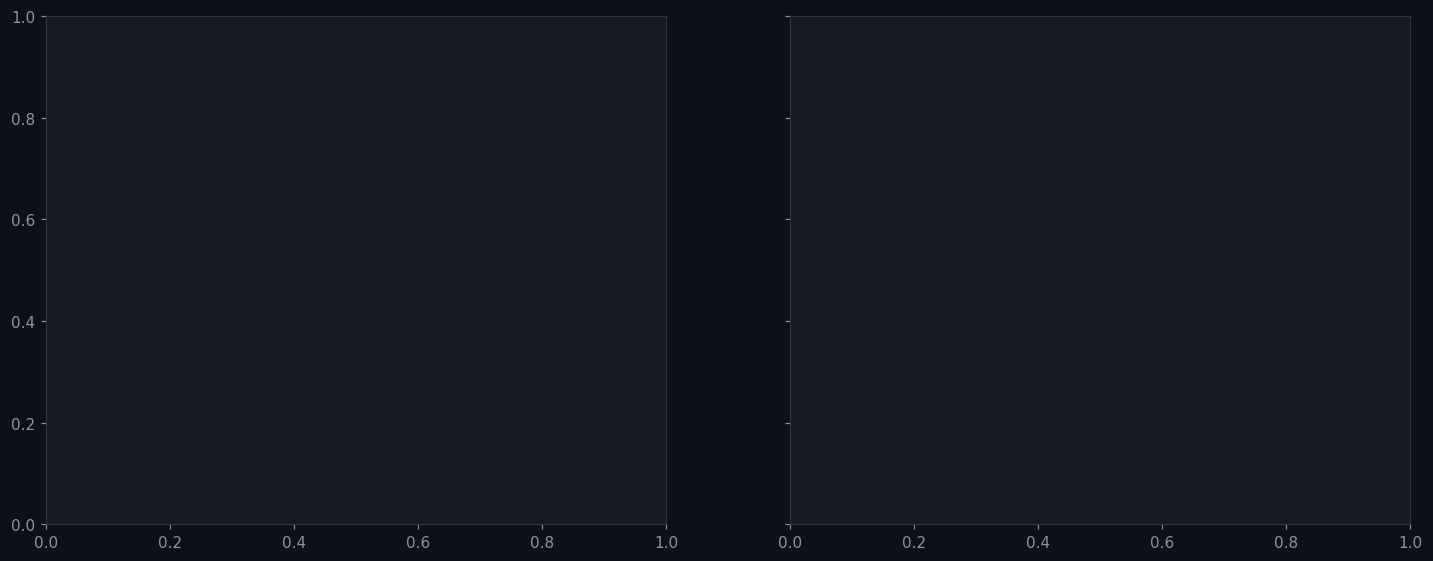

In [53]:
# ──────────────────────────────────────────────────────────────────────────────
# 16.2  OOS EQUITY CURVE COMPARISON
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, bt, title, color in zip(
    axes,
    [oos_bt_base, oos_bt_ft],
    ['Base Model', 'Fine-Tuned Model'],
    [BASE_COLOR, FT_COLOR]
):
    if bt.empty:
        ax.set_title(f'{title} — No Trades')
        continue
    equity = bt['pnl'].cumsum()
    ax.plot(equity.values, color=color, lw=1.8)
    ax.fill_between(range(len(equity)), equity.values, 0,
                    where=equity.values >= 0, alpha=0.12, color=BULL_COLOR)
    ax.fill_between(range(len(equity)), equity.values, 0,
                    where=equity.values < 0, alpha=0.12, color=BEAR_COLOR)
    ax.axhline(0, color='white', lw=0.7, ls='--')
    ax.set_title(f'{title} — OOS Equity Curve', fontsize=12)
    ax.set_xlabel('Trade #'); ax.set_ylabel('Cumulative PnL (ATR)')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## Section 17 — Comparative Risk Analytics

Full performance analytics including Sharpe Ratio, Sortino Ratio, Calmar Ratio, Maximum Drawdown, trade distribution statistics, Monte Carlo simulation, and a consolidated head-to-head summary table.


In [54]:
# ──────────────────────────────────────────────────────────────────────────────
# 16.1  RUN OOS BACKTEST — BOTH MODELS
# ──────────────────────────────────────────────────────────────────────────────

BT_CONFIG = dict(tp_mult=2.0, sl_mult=1.0, max_bars=60, prob_threshold=0.42)

oos_bt_base = run_backtest(X_oos, X_oos_meta, y_oos_base_proba, **BT_CONFIG)
oos_bt_ft   = run_backtest(X_oos, X_oos_meta, y_oos_ft_proba,   **BT_CONFIG)

def bt_summary(bt, name):
    if bt.empty:
        print(f"{name}: No trades generated."); return
    wins  = (bt['outcome'] == 1).sum()
    n     = len(bt)
    gross_w = bt[bt['pnl']>0]['pnl'].sum()
    gross_l = abs(bt[bt['pnl']<0]['pnl'].sum())
    pf    = gross_w / (gross_l + 1e-9)
    print(f"{name}")
    print(f"  Trades     : {n}  |  Win Rate: {wins/n*100:.1f}%")
    print(f"  Profit Factor: {pf:.3f}")
    print(f"  Net PnL (ATR): {bt['pnl'].sum():.2f}")
    print()

bt_summary(oos_bt_base, "Base Model (OOS)")
bt_summary(oos_bt_ft,   "Fine-Tuned Model (OOS)")

NameError: name 'y_oos_ft_proba' is not defined

In [55]:
def calc_risk_metrics(pnl_series, bt_df, df_meta):
    """
    FIX 2 & 3: Annualization based on actual trade frequency.
    """
    if len(pnl_series) == 0: return {}

    # Calculate trade frequency for annualization
    total_days = (df_meta['datetime'].max() - df_meta['datetime'].min()).total_seconds() / 86400
    trades_per_day = len(pnl_series) / max(total_days, 0.1)
    ann_factor = np.sqrt(trades_per_day * 252)

    # Sharpe
    mu, sigma = np.mean(pnl_series), np.std(pnl_series)
    sharpe = (mu / sigma * ann_factor) if sigma > 0 else 0

    # Sortino
    neg_pnl = pnl_series[pnl_series < 0]
    down_sigma = np.std(neg_pnl) if len(neg_pnl) > 1 else 1e-9
    sortino = (mu / down_sigma * ann_factor)

    # Max Drawdown
    equity = np.cumsum(pnl_series)
    mdd = np.min(equity - np.maximum.accumulate(equity))

    # Calmar
    annual_ret = mu * trades_per_day * 252
    calmar = (annual_ret / abs(mdd)) if mdd != 0 else 0

    return {
        'Sharpe': round(sharpe, 3),
        'Sortino': round(sortino, 3),
        'Calmar': round(calmar, 3),
        'MDD': round(mdd, 2)
    }

In [56]:
# ──────────────────────────────────────────────────────────────────────────────
# 17.2  CONSOLIDATED PERFORMANCE TABLE
# ──────────────────────────────────────────────────────────────────────────────

summary = pd.DataFrame([
    full_metrics(oos_bt_base, 'Base Model'),
    full_metrics(oos_bt_ft,   'Fine-Tuned Model'),
]).set_index('Model').T

print("\n" + "=" * 65)
print("  COMPARATIVE PERFORMANCE SUMMARY — OOS Hold-Out")
print("=" * 65)
display(summary)


NameError: name 'full_metrics' is not defined

NameError: name 'oos_bt_ft' is not defined

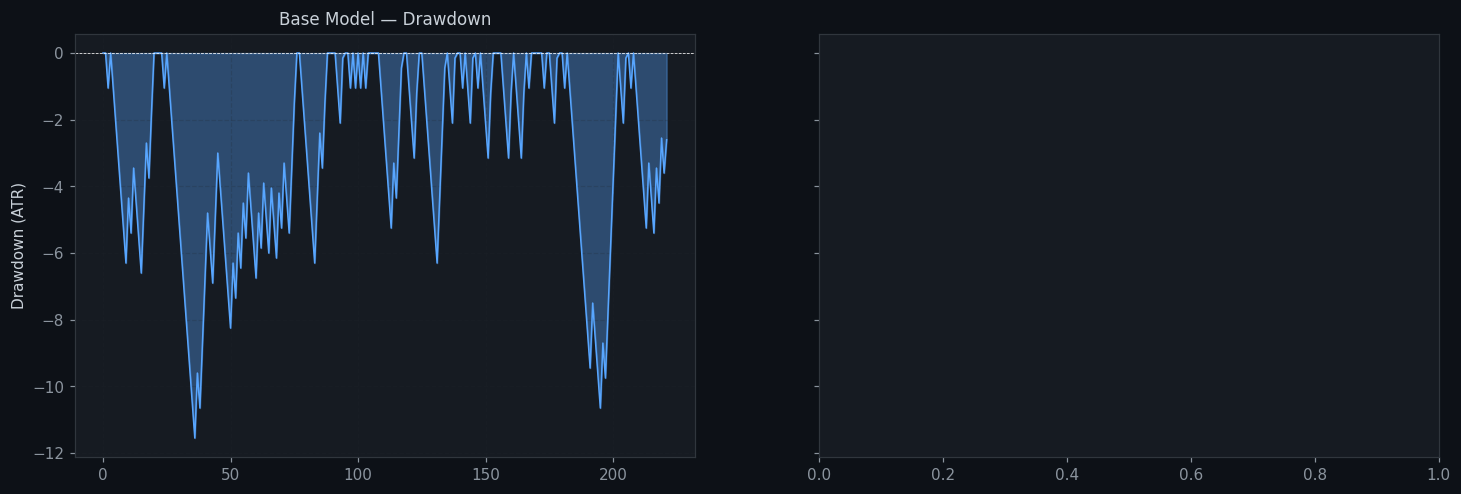

In [57]:
# ──────────────────────────────────────────────────────────────────────────────
# 17.3  DRAWDOWN CURVES
# ──────────────────────────────────────────────────────────────────────────────


def plot_drawdown(pnl_series, title, color, ax):
    equity  = np.cumsum(pnl_series)
    peak    = np.maximum.accumulate(equity)
    dd      = equity - peak
    ax.fill_between(range(len(dd)), dd, 0, color=color, alpha=0.35)
    ax.plot(dd, color=color, lw=1)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Drawdown (ATR)'); ax.grid(True, alpha=0.2)
    ax.axhline(0, color='white', lw=0.5, ls='--')


fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
if not oos_bt_base.empty:
    plot_drawdown(oos_bt_base['pnl'].values, 'Base Model — Drawdown', BASE_COLOR, axes[0])
if not oos_bt_ft.empty:
    plot_drawdown(oos_bt_ft['pnl'].values,   'Fine-Tuned — Drawdown', FT_COLOR, axes[1])
plt.tight_layout(); plt.show()




In [58]:
# ──────────────────────────────────────────────────────────────────────────────
# 17.4  TRADE PnL DISTRIBUTION COMPARISON
# ──────────────────────────────────────────────────────────────────────────────

if not oos_bt_base.empty and not oos_bt_ft.empty:
    plot_df = pd.DataFrame({
        'PnL'  : np.concatenate([oos_bt_base['pnl'].values, oos_bt_ft['pnl'].values]),
        'Model': ['Base'] * len(oos_bt_base) + ['Fine-Tuned'] * len(oos_bt_ft)
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    for model, col in [('Base', BASE_COLOR), ('Fine-Tuned', FT_COLOR)]:
        axes[0].hist(
            plot_df.loc[plot_df['Model']==model, 'PnL'],
            bins=30, alpha=0.55, color=col, label=model, edgecolor='none'
        )
    axes[0].set_title('Trade PnL Distribution')
    axes[0].set_xlabel('PnL (ATR)'); axes[0].set_ylabel('Frequency')
    axes[0].legend(); axes[0].grid(True, alpha=0.2)

    # Box plot
    bp_data = [oos_bt_base['pnl'].values, oos_bt_ft['pnl'].values]
    bplot = axes[1].boxplot(bp_data, patch_artist=True, labels=['Base', 'Fine-Tuned'],
                             widths=0.4)
    for patch, color in zip(bplot['boxes'], [BASE_COLOR, FT_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.5)
    axes[1].set_title('PnL Box Plot')
    axes[1].set_ylabel('PnL (ATR)'); axes[1].grid(True, alpha=0.2)
    axes[1].axhline(0, color='white', lw=0.7, ls='--')

    plt.tight_layout(); plt.show()


NameError: name 'oos_bt_ft' is not defined

In [59]:
# ──────────────────────────────────────────────────────────────────────────────
# 17.5  MONTE CARLO SIMULATION (1,000 PATH RESAMPLING)
# ──────────────────────────────────────────────────────────────────────────────

def monte_carlo(pnl_series, n_sims=1000, seed=42):
    """Bootstrap resample trades to generate distribution of equity path outcomes."""
    np.random.seed(seed)
    n      = len(pnl_series)
    paths  = []
    for _ in range(n_sims):
        sample = np.random.choice(pnl_series, size=n, replace=True)
        paths.append(np.cumsum(sample))
    return paths


if not oos_bt_base.empty and not oos_bt_ft.empty:
    base_paths = monte_carlo(oos_bt_base['pnl'].values)
    ft_paths   = monte_carlo(oos_bt_ft['pnl'].values)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, paths, actual_pnl, title, color in zip(
        axes,
        [base_paths, ft_paths],
        [oos_bt_base['pnl'], oos_bt_ft['pnl']],
        ['Base Model', 'Fine-Tuned Model'],
        [BASE_COLOR, FT_COLOR]
    ):
        for path in paths[:200]:
            ax.plot(path, color=color, alpha=0.03, lw=0.5)
        mean_path = np.mean(paths, axis=0)
        p5  = np.percentile(paths, 5, axis=0)
        p95 = np.percentile(paths, 95, axis=0)
        ax.plot(mean_path, color='white', lw=2, label='Mean Path')
        ax.plot(actual_pnl.cumsum().values, color='yellow', lw=1.5, ls='--', label='Actual Path')
        ax.fill_between(range(len(mean_path)), p5, p95, alpha=0.2, color=color, label='5–95th pct')
        ax.axhline(0, color='white', lw=0.6, ls='--')
        ax.set_title(f'{title} — Monte Carlo (n=1,000)')
        ax.set_ylabel('Cumulative PnL (ATR)'); ax.set_xlabel('Trade #')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
        fin = [p[-1] for p in paths]
        print(f"{title}  |  5th pct: {np.percentile(fin, 5):.2f}  |  Median: {np.median(fin):.2f}  |  95th pct: {np.percentile(fin, 95):.2f}")

    plt.tight_layout(); plt.show()


NameError: name 'oos_bt_ft' is not defined

### Section 17.6 — Stationary Block Bootstrap Analysis
To account for serial correlation and time-dependency in trade returns, we use a block bootstrap. This helps validate if the strategy's performance is robust or simply a result of a specific sequence of trades.

In [60]:
def stationary_block_bootstrap(pnl_series, block_size=5, n_sims=1000, seed=42):
    """
    Performs a stationary block bootstrap on a 1D array of returns.
    block_size: Expected length of each block.
    """
    np.random.seed(seed)
    n = len(pnl_series)
    resampled_means = []
    resampled_pnl_sums = []

    # Probability of starting a new block
    p = 1.0 / block_size

    for _ in range(n_sims):
        indices = np.zeros(n, dtype=int)
        # Random starting index
        indices[0] = np.random.randint(0, n)

        for i in range(1, n):
            if np.random.rand() < p:
                # Start new block
                indices[i] = np.random.randint(0, n)
            else:
                # Continue block (with wrap-around)
                indices[i] = (indices[i-1] + 1) % n

        resampled_series = pnl_series[indices]
        resampled_means.append(np.mean(resampled_series))
        resampled_pnl_sums.append(np.sum(resampled_series))

    return np.array(resampled_pnl_sums), np.array(resampled_means)

# Run bootstrap on Fine-Tuned Model OOS trades
if not oos_bt_ft.empty:
    ft_pnl_vals = oos_bt_ft['pnl'].values
    block_sums, block_means = stationary_block_bootstrap(ft_pnl_vals, block_size=6, n_sims=5000)

    # Calculate Metrics
    ci_low, ci_high = np.percentile(block_sums, [2.5, 97.5])
    prob_loss = (block_sums < 0).mean() * 100

    print(f"Stationary Block Bootstrap Results (Fine-Tuned OOS)")
    print(f"{'─'*45}")
    print(f"Mean Bootstrap PnL: {np.mean(block_sums):.2f} ATR")
    print(f"95% Confidence Interval: [{ci_low:.2f}, {ci_high:.2f}] ATR")
    print(f"Probability of Strategy Loss: {prob_loss:.2f}%")
    print(f"{'─'*45}")

    # Visualization
    plt.figure(figsize=(10, 5))
    sns.histplot(block_sums, kde=True, color=FT_COLOR, bins=50, alpha=0.6)
    plt.axvline(oos_bt_ft['pnl'].sum(), color='yellow', linestyle='--', label='Actual OOS PnL')
    plt.axvline(ci_low, color='white', linestyle=':', label='95% CI Lower Bound')
    plt.axvline(0, color=BEAR_COLOR, lw=2)
    plt.title("Stationary Block Bootstrap — Distribution of Cumulative PnL")
    plt.xlabel("Cumulative PnL (ATR)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

NameError: name 'oos_bt_ft' is not defined

In [61]:
# ──────────────────────────────────────────────────────────────────────────────
# 17.6  SHARPE / SORTINO / CALMAR BAR COMPARISON
# ──────────────────────────────────────────────────────────────────────────────

if not oos_bt_base.empty and not oos_bt_ft.empty:
    metrics_labels = ['Sharpe (Ann)', 'Sortino (Ann)', 'Calmar', 'Profit Factor']
    m_base = full_metrics(oos_bt_base, 'Base')
    m_ft   = full_metrics(oos_bt_ft,   'Fine-Tuned')

    vals_base = [m_base.get(k, 0) for k in metrics_labels]
    vals_ft   = [m_ft.get(k, 0)   for k in metrics_labels]

    x = np.arange(len(metrics_labels))
    w = 0.35

    fig, ax = plt.subplots(figsize=(11, 5))
    bars1 = ax.bar(x - w/2, vals_base, w, label='Base Model',      color=BASE_COLOR, alpha=0.85)
    bars2 = ax.bar(x + w/2, vals_ft,   w, label='Fine-Tuned Model', color=FT_COLOR,   alpha=0.85)

    ax.set_xticks(x); ax.set_xticklabels(metrics_labels, fontsize=11)
    ax.set_title('Risk-Adjusted Metrics Comparison — OOS', fontsize=13)
    ax.set_ylabel('Metric Value'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='white', lw=0.6, ls='--')
    ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
    ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)
    plt.tight_layout(); plt.show()


NameError: name 'oos_bt_ft' is not defined

## Section 18 — Live Signal Preview

The fine-tuned model classifies the most recent bars in the OOS dataset and reports direction probabilities and final signal calls. This simulates live deployment readiness.


In [62]:
# ──────────────────────────────────────────────────────────────────────────────
# 18.1  LIVE SIGNAL PREVIEW — LAST 10 OOS BARS
# ──────────────────────────────────────────────────────────────────────────────

last_n    = min(10, len(X_oos))
X_live    = X_oos.tail(last_n)
meta_live = X_oos_meta.tail(last_n)

probs_live = model_ft.predict_proba(X_live)
preds_live = model_ft.predict(X_live)

pred_map   = {0: '🔴 BEAR (Short)', 1: '⬜ NEUTRAL', 2: '🟢 BULL (Long)'}

live_df = pd.DataFrame({
    'Time'         : meta_live['datetime'].values,
    'Price'        : meta_live['close'].round(2).values,
    'ATR'          : meta_live['atr'].round(2).values,
    'Bear Prob'    : [f'{p[0]:.1%}' for p in probs_live],
    'Neutral Prob' : [f'{p[1]:.1%}' for p in probs_live],
    'Bull Prob'    : [f'{p[2]:.1%}' for p in probs_live],
    'Signal'       : [pred_map[p] for p in preds_live],
})

print("─" * 70)
print("  LIVE MODEL PREDICTIONS — Fine-Tuned Model (Last OOS Bars)")
print("─" * 70)
display(live_df)


NameError: name 'model_ft' is not defined

In [63]:
# ──────────────────────────────────────────────────────────────────────────────
# 18.2  PROBABILITY HORIZON CHART — LAST 100 OOS BARS
# ──────────────────────────────────────────────────────────────────────────────

horizon_n = min(100, len(X_oos))
probs_h   = model_ft.predict_proba(X_oos.tail(horizon_n))
times_h   = X_oos_meta.tail(horizon_n)['datetime']

prob_df = pd.DataFrame(probs_h, columns=['Bear', 'Neutral', 'Bull'], index=times_h)

fig, ax = plt.subplots(figsize=(15, 5))
ax.stackplot(
    prob_df.index,
    prob_df['Bear'], prob_df['Neutral'], prob_df['Bull'],
    labels=['Bear', 'Neutral', 'Bull'],
    colors=[BEAR_COLOR, '#8b949e', BULL_COLOR],
    alpha=0.80
)
ax.set_title(f'Fine-Tuned Model — Classification Probability Horizon (Last {horizon_n} OOS Bars)',
             fontsize=12)
ax.set_ylabel('Probability'); ax.set_xlabel('Time')
ax.set_ylim(0, 1); ax.set_xlim(prob_df.index[0], prob_df.index[-1])
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.2)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


NameError: name 'model_ft' is not defined

## Section 19 — Dataset Export & Column Reference

Exports the full enriched feature dataset to CSV and prints the complete column naming convention for documentation purposes.


In [64]:
# ──────────────────────────────────────────────────────────────────────────────
# 19.1  EXPORT FEATURE DATASET
# ──────────────────────────────────────────────────────────────────────────────

dataset.to_csv(OUTPUT_CSV, index=False)
print(f"✓  Dataset exported → {OUTPUT_CSV}")
print(f"   Rows    : {len(dataset):,}")
print(f"   Columns : {len(dataset.columns):,}")


✓  Dataset exported → market_structure_features.csv
   Rows    : 9,970
   Columns : 378


In [65]:
# ──────────────────────────────────────────────────────────────────────────────
# 19.2  COLUMN NAMING CONVENTION REFERENCE
# ──────────────────────────────────────────────────────────────────────────────

print('=' * 70)
print('  LOOKBACK FEATURE COLUMN NAMING CONVENTION')
print('=' * 70)
print()
print('  Pattern:  {prefix}{rank}_{metric}')
print()
print('  Prefixes:')
prefix_map = {
    'sh_'         : 'Swing High',
    'sl_'         : 'Swing Low',
    'bos_bull_'   : 'Bullish Break of Structure',
    'bos_bear_'   : 'Bearish Break of Structure',
    'choch_bull_' : 'Bullish Change of Character',
    'choch_bear_' : 'Bearish Change of Character',
    'ob_bull_'    : 'Bullish Order Block (with fill status)',
    'ob_bear_'    : 'Bearish Order Block (with fill status)',
}
for pfx, desc in prefix_map.items():
    print(f'    {pfx:<16}  →  {desc}')

print()
print(f'  Rank     :  1 = most recent  …  {N} = {N}th most recent')
print()
print('  Metrics per event:')
print('    _bars_ago        →  Bars since the event (temporal distance)')
print('    _raw_dist        →  Current close − event close (price difference)')
print('    _atr_dist        →  raw_dist / current ATR (scale-invariant)')
print('    _swing_strength  →  [Swings only] Composite strength score 0–100')
print('    _reversal_prob   →  [Swings only] Bayesian reversal probability 0–100')
print('    _is_filled       →  [OBs only] 1 if zone has been mitigated, else 0')
print()
example_cols = [c for c in dataset.columns if c.startswith('sh_')][:N*5]
print(f'  Example columns for N={N} (Swing High):')
for c in example_cols:
    print(f'    {c}')


  LOOKBACK FEATURE COLUMN NAMING CONVENTION

  Pattern:  {prefix}{rank}_{metric}

  Prefixes:
    sh_               →  Swing High
    sl_               →  Swing Low
    bos_bull_         →  Bullish Break of Structure
    bos_bear_         →  Bearish Break of Structure
    choch_bull_       →  Bullish Change of Character
    choch_bear_       →  Bearish Change of Character
    ob_bull_          →  Bullish Order Block (with fill status)
    ob_bear_          →  Bearish Order Block (with fill status)

  Rank     :  1 = most recent  …  3 = 3th most recent

  Metrics per event:
    _bars_ago        →  Bars since the event (temporal distance)
    _raw_dist        →  Current close − event close (price difference)
    _atr_dist        →  raw_dist / current ATR (scale-invariant)
    _swing_strength  →  [Swings only] Composite strength score 0–100
    _reversal_prob   →  [Swings only] Bayesian reversal probability 0–100
    _is_filled       →  [OBs only] 1 if zone has been mitigated, else 0

  E

In [66]:
import pandas as pd

# 1. Verify feature count for both models
base_features = model_base.feature_names_in_
ft_features = model_ft.feature_names_in_

print(f"Base Model Features: {len(base_features)}")
print(f"Fine-Tuned Model Features: {len(ft_features)}")
print(f"Are feature sets identical? {list(base_features) == list(ft_features)}")

# 2. Inspect the first 5 rows and a subset of columns of your feature matrix X_all_unbalanced
# Displaying a mix of raw price, indicators, and structure features
preview_cols = ['close', 'atr', 'rsi_14', 'macd', 'is_bullish_trend', 'sh_1_bars_ago', 'ob_bull_1_is_filled']
display(X_all_unbalanced[preview_cols].head())

# 3. List all category types present in X
cat_cols = X_all_unbalanced.select_dtypes(include=['category']).columns.tolist()
print(f"\nCategorical features detected: {len(cat_cols)}")
print(cat_cols[:10], "..." if len(cat_cols) > 10 else "")

NameError: name 'model_ft' is not defined

In [ ]:
import pandas as pd

# Load the session log data
log_df = pd.read_csv('/content/session_log_1m.csv')

# Display the first few rows and summary info
print(f"CSV Loaded: {len(log_df):,} rows")
display(log_df.head())


CSV Loaded: 66,470 rows


,DateTime,Date,Time,DayOfWeek,Session,Open,High,Low,Close,Volume,...,DistFromRound10,NearestRound50,DistFromRound50,SessBullBars,SessBearBars,SessNetBias,Velocity,Acceleration,TickRate,TickAcceleration
0,2026.01.01 23:01,2026.01.01,23:01,Thu,Asian_Early,4330.37,4332.87,4329.87,4329.87,1,...,-130.0,4350,-20130.0,0,1,-1,NaN,NaN,0.3,0.2
1,2026.01.01 23:02,2026.01.01,23:02,Thu,Asian_Early,4329.87,4331.37,4329.30,4331.10,2,...,1100.0,4350,-18900.0,1,1,0,1230.0,NaN,0.5,0.6
2,2026.01.01 23:03,2026.01.01,23:03,Thu,Asian_Early,4331.10,4331.06,4325.89,4326.85,2,...,-3150.0,4350,-23150.0,1,2,-1,-4250.0,-5480.0,0.7,1.0
3,2026.01.01 23:04,2026.01.01,23:04,Thu,Asian_Early,4326.85,4329.12,4324.33,4329.05,2,...,-950.0,4350,-20950.0,2,2,0,2200.0,6450.0,0.9,1.4
4,2026.01.01 23:05,2026.01.01,23:05,Thu,Asian_Early,4329.05,4331.39,4328.07,4330.50,2,...,500.0,4350,-19500.0,3,2,1,1450.0,-750.0,1.1,1.8


In [67]:
import pandas as pd
import numpy as np

# 1. Map columns from log_df to our standard format
predict_df = log_df[['DateTime', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
predict_df.columns = ['datetime', 'open', 'high', 'low', 'close', 'volume']
predict_df['datetime'] = pd.to_datetime(predict_df['datetime'])
predict_df = predict_df.sort_values('datetime').reset_index(drop=True)

# 2. Re-calculate core indicators
predict_df['atr'] = calc_atr(predict_df, ATR_LEN)
predict_df['atr_sma20'] = predict_df['atr'].rolling(20).mean()
predict_df['vol_regime'] = predict_df['atr'] / predict_df['atr_sma20'].replace(0, np.nan)

predict_df['vol_sma20']  = predict_df['volume'].rolling(20).mean()
predict_df['vol_ratio']  = predict_df['volume'] / predict_df['vol_sma20'].replace(0, np.nan)
predict_df['vol_delta']  = predict_df['volume'].diff()

for p in [7, 14, 21]:
    predict_df[f'rsi_{p}'] = calc_rsi(predict_df['close'], p)
predict_df['rsi'] = predict_df['rsi_14']

for span in [9, 20, 50, 200]:
    predict_df[f'ema_{span}'] = predict_df['close'].ewm(span=span, adjust=False).mean()

predict_df['ema_20_50_cross'] = (predict_df['ema_20'] > predict_df['ema_50']).astype(int)
predict_df['ema_50_200_cross'] = (predict_df['ema_50'] > predict_df['ema_200']).astype(int)
predict_df['macd'], predict_df['macd_signal'], predict_df['macd_hist'] = calc_macd(predict_df['close'])
predict_df['macd_cross'] = (predict_df['macd'] > predict_df['macd_signal']).astype(int)

predict_df['bb_upper'], predict_df['bb_mid'], predict_df['bb_lower'], predict_df['bb_pct_b'], predict_df['bb_bw'] = calc_bollinger(predict_df['close'])
predict_df['vwap'] = calc_vwap(predict_df)
predict_df['vwap_dist'] = (predict_df['close'] - predict_df['vwap']) / predict_df['atr'].replace(0, np.nan)

# 2b. Add HTF Bias (Mocked context using EMA crossover)
predict_df['htf_bullish'] = (predict_df['ema_50'] > predict_df['ema_200']).astype(int)

# 2c. Add Relational MA block
print('Building Relational MA features for inference...')
ma_feat_block_p = build_ma_features(predict_df, ma_periods=[3, 5, 8, 13, 21, 34, 55], lookback=30)
predict_df = pd.concat([predict_df, ma_feat_block_p], axis=1)

# 3. Market Structure Meta-Features
predict_df['is_swing_high'], predict_df['is_swing_low'] = fractal_pivots(predict_df, LEFT_BARS, RIGHT_BARS, MIN_ATR_MULT)

predict_df['swing_strength'] = np.nan
predict_df['reversal_prob'] = np.nan
_lsl_p = None; _lsh_p = None

for idx, row in predict_df.iterrows():
    sz = row['high'] - row['low']
    if row['is_swing_high']:
        predict_df.at[idx, 'swing_strength'] = swing_strength(row, sz)
        predict_df.at[idx, 'reversal_prob'] = reversal_prob_high(row, sz, _lsl_p)
        _lsh_p = row['close']
    if row['is_swing_low']:
        predict_df.at[idx, 'swing_strength'] = swing_strength(row, sz)
        predict_df.at[idx, 'reversal_prob'] = reversal_prob_low(row, sz, _lsh_p)
        _lsl_p = row['close']

# 4. BOS / CHoCH Detection
predict_df['is_bos_bull'] = False; predict_df['is_bos_bear'] = False
predict_df['is_choch_bull'] = False; predict_df['is_choch_bear'] = False
_ls_h = None; _ps_h = None; _ls_l = None; _ps_l = None
for i in range(1, len(predict_df)):
    r = predict_df.iloc[i]; p = predict_df.iloc[i-1]
    if r['is_swing_high']: _ps_h, _ls_h = _ls_h, r['close']
    if r['is_swing_low']: _ps_l, _ls_l = _ls_l, r['close']
    b_bull = _ls_h is not None and p['close'] <= _ls_h and r['close'] > _ls_h
    b_bear = _ls_l is not None and p['close'] >= _ls_l and r['close'] < _ls_l
    c_bull = b_bull and _ps_l is not None and _ls_l is not None and _ls_l < _ps_l
    c_bear = b_bear and _ps_h is not None and _ls_h is not None and _ls_h > _ps_h
    predict_df.at[predict_df.index[i], 'is_bos_bull'] = b_bull and not c_bull
    predict_df.at[predict_df.index[i], 'is_bos_bear'] = b_bear and not c_bear
    predict_df.at[predict_df.index[i], 'is_choch_bull'] = c_bull
    predict_df.at[predict_df.index[i], 'is_choch_bear'] = c_bear

# 5. OB Detection
predict_df = detect_enhanced_order_blocks(predict_df)

# 6. Price Derivatives
for col in ['open', 'high', 'low', 'close']:
    predict_df[f'{col}_v1'] = predict_df[col].diff()
    predict_df[f'{col}_v2'] = predict_df[f'{col}_v1'].diff()
predict_df['hl_range'] = predict_df['high'] - predict_df['low']
predict_df['co_spread'] = predict_df['close'] - predict_df['open']
predict_df['hl_range_v1'] = predict_df['hl_range'].diff()
predict_df['hl_range_v2'] = predict_df['hl_range_v1'].diff()
predict_df['co_spread_v1'] = predict_df['co_spread'].diff()
predict_df['co_spread_v2'] = predict_df['co_spread_v1'].diff()
predict_df['body_ratio'] = predict_df['co_spread'].abs() / predict_df['hl_range'].replace(0, np.nan)
predict_df['upper_wick'] = predict_df['high'] - predict_df[['open', 'close']].max(axis=1)
predict_df['lower_wick'] = predict_df[['open', 'close']].min(axis=1) - predict_df['low']
predict_df['wick_ratio'] = (predict_df['upper_wick'] + predict_df['lower_wick']) / predict_df['hl_range'].replace(0, np.nan)

# 7. Context Zones & Fibonacci
predict_df['range_high'] = predict_df['high'].rolling(100).max()
predict_df['range_low'] = predict_df['low'].rolling(100).min()
predict_df['range_pct'] = (predict_df['close'] - predict_df['range_low']) / (predict_df['range_high'] - predict_df['range_low']).replace(0, np.nan)
predict_df['in_premium'] = (predict_df['range_pct'] > 0.618).astype(int)
predict_df['in_discount'] = (predict_df['range_pct'] < 0.382).astype(int)
predict_df['in_equilibrium'] = ((predict_df['range_pct'] >= 0.382) & (predict_df['range_pct'] <= 0.618)).astype(int)

predict_df['last_sh_price'] = np.nan; predict_df['last_sl_price'] = np.nan
_lsh_f = np.nan; _lsl_f = np.nan
for idx, row in predict_df.iterrows():
    if row['is_swing_high']: _lsh_f = row['high']
    if row['is_swing_low']: _lsl_f = row['low']
    predict_df.at[idx, 'last_sh_price'] = _lsh_f
    predict_df.at[idx, 'last_sl_price'] = _lsl_f

_fib_range = predict_df['last_sh_price'] - predict_df['last_sl_price']
for fib in [0.236, 0.382, 0.5, 0.618, 0.786]:
    _fib_p = predict_df['last_sl_price'] + fib * _fib_range
    predict_df[f'fib_{int(fib*1000)}_dist'] = (predict_df['close'] - _fib_p) / predict_df['atr'].replace(0, np.nan)

# 8. Confluence & Trend
predict_df['is_bullish_trend'] = False
trend = False
for i in range(len(predict_df)):
    if predict_df.iloc[i]['is_bos_bull'] or predict_df.iloc[i]['is_choch_bull']: trend = True
    elif predict_df.iloc[i]['is_bos_bear'] or predict_df.iloc[i]['is_choch_bear']: trend = False
    predict_df.at[predict_df.index[i], 'is_bullish_trend'] = trend

predict_df['bull_confluence'] = (predict_df['is_bullish_trend'].astype(int) + predict_df['macd_cross'].astype(int) + predict_df['ema_20_50_cross'].astype(int) + predict_df['in_discount'].astype(int))
predict_df['bear_confluence'] = ((~predict_df['is_bullish_trend']).astype(int) + (1 - predict_df['macd_cross']).astype(int) + (1 - predict_df['ema_20_50_cross']).astype(int) + predict_df['in_premium'].astype(int))

# 9. Session
predict_df['hour'] = predict_df['datetime'].dt.hour
predict_df['day_of_week'] = predict_df['datetime'].dt.dayofweek
predict_df['session'] = predict_df['hour'].apply(lambda h: 1 if 7 <= h < 12 else 2 if 12 <= h < 17 else 0)
predict_df['is_active_session'] = predict_df['session'].isin([1, 2]).astype(int)

print('✓ Full features and structure detection complete for prediction dataset.')

NameError: name 'log_df' is not defined

In [68]:
import pandas as pd
import numpy as np

# 1. Map columns from log_df to our standard format
predict_df = log_df[['DateTime', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
predict_df.columns = ['datetime', 'open', 'high', 'low', 'close', 'volume']
predict_df['datetime'] = pd.to_datetime(predict_df['datetime'])
predict_df = predict_df.sort_values('datetime').reset_index(drop=True)

# 2. Re-calculate core indicators
predict_df['atr'] = calc_atr(predict_df, ATR_LEN)
predict_df['atr_sma20'] = predict_df['atr'].rolling(20).mean()
predict_df['vol_regime'] = predict_df['atr'] / predict_df['atr_sma20'].replace(0, np.nan)

predict_df['vol_sma20']  = predict_df['volume'].rolling(20).mean()
predict_df['vol_ratio']  = predict_df['volume'] / predict_df['vol_sma20'].replace(0, np.nan)
predict_df['vol_delta']  = predict_df['volume'].diff()

for p in [7, 14, 21]:
    predict_df[f'rsi_{p}'] = calc_rsi(predict_df['close'], p)
predict_df['rsi'] = predict_df['rsi_14']

for span in [9, 20, 50, 200]:
    predict_df[f'ema_{span}'] = predict_df['close'].ewm(span=span, adjust=False).mean()

predict_df['ema_20_50_cross'] = (predict_df['ema_20'] > predict_df['ema_50']).astype(int)
predict_df['ema_50_200_cross'] = (predict_df['ema_50'] > predict_df['ema_200']).astype(int)
predict_df['macd'], predict_df['macd_signal'], predict_df['macd_hist'] = calc_macd(predict_df['close'])
predict_df['macd_cross'] = (predict_df['macd'] > predict_df['macd_signal']).astype(int)

predict_df['bb_upper'], predict_df['bb_mid'], predict_df['bb_lower'], predict_df['bb_pct_b'], predict_df['bb_bw'] = calc_bollinger(predict_df['close'])
predict_df['vwap'] = calc_vwap(predict_df)
predict_df['vwap_dist'] = (predict_df['close'] - predict_df['vwap']) / predict_df['atr'].replace(0, np.nan)

# 2b. Add HTF Bias context - aligned with training feature names
# In training, features were named htf_ema50, htf_ema200
predict_df['htf_ema50'] = predict_df['close'].ewm(span=50, adjust=False).mean()
predict_df['htf_ema200'] = predict_df['close'].ewm(span=200, adjust=False).mean()
predict_df['htf_bullish'] = (predict_df['htf_ema50'] > predict_df['htf_ema200']).astype(int)

# 2c. Add Relational MA block
print('Building Relational MA features for inference...')
ma_feat_block_p = build_ma_features(predict_df, ma_periods=[3, 5, 8, 13, 21, 34, 55], lookback=30)
predict_df = pd.concat([predict_df, ma_feat_block_p], axis=1)

# 3. Market Structure Meta-Features
predict_df['is_swing_high'], predict_df['is_swing_low'] = fractal_pivots(predict_df, LEFT_BARS, RIGHT_BARS, MIN_ATR_MULT)

predict_df['swing_strength'] = np.nan
predict_df['reversal_prob'] = np.nan
_lsl_p = None; _lsh_p = None

for idx, row in predict_df.iterrows():
    sz = row['high'] - row['low']
    if row['is_swing_high']:
        predict_df.at[idx, 'swing_strength'] = swing_strength(row, sz)
        predict_df.at[idx, 'reversal_prob'] = reversal_prob_high(row, sz, _lsl_p)
        _lsh_p = row['close']
    if row['is_swing_low']:
        predict_df.at[idx, 'swing_strength'] = swing_strength(row, sz)
        predict_df.at[idx, 'reversal_prob'] = reversal_prob_low(row, sz, _lsh_p)
        _lsl_p = row['close']

# 4. BOS / CHoCH Detection
predict_df['is_bos_bull'] = False; predict_df['is_bos_bear'] = False
predict_df['is_choch_bull'] = False; predict_df['is_choch_bear'] = False
_ls_h = None; _ps_h = None; _ls_l = None; _ps_l = None
for i in range(1, len(predict_df)):
    r = predict_df.iloc[i]; p = predict_df.iloc[i-1]
    if r['is_swing_high']: _ps_h, _ls_h = _ls_h, r['close']
    if r['is_swing_low']: _ps_l, _ls_l = _ls_l, r['close']
    b_bull = _ls_h is not None and p['close'] <= _ls_h and r['close'] > _ls_h
    b_bear = _ls_l is not None and p['close'] >= _ls_l and r['close'] < _ls_l
    c_bull = b_bull and _ps_l is not None and _ls_l is not None and _ls_l < _ps_l
    c_bear = b_bear and _ps_h is not None and _ls_h is not None and _ls_h > _ps_h
    predict_df.at[predict_df.index[i], 'is_bos_bull'] = b_bull and not c_bull
    predict_df.at[predict_df.index[i], 'is_bos_bear'] = b_bear and not c_bear
    predict_df.at[predict_df.index[i], 'is_choch_bull'] = c_bull
    predict_df.at[predict_df.index[i], 'is_choch_bear'] = c_bear

# 5. OB Detection
predict_df = detect_enhanced_order_blocks(predict_df)

# 6. Price Derivatives
for col in ['open', 'high', 'low', 'close']:
    predict_df[f'{col}_v1'] = predict_df[col].diff()
    predict_df[f'{col}_v2'] = predict_df[f'{col}_v1'].diff()
predict_df['hl_range'] = predict_df['high'] - predict_df['low']
predict_df['co_spread'] = predict_df['close'] - predict_df['open']
predict_df['hl_range_v1'] = predict_df['hl_range'].diff()
predict_df['hl_range_v2'] = predict_df['hl_range_v1'].diff()
predict_df['co_spread_v1'] = predict_df['co_spread'].diff()
predict_df['co_spread_v2'] = predict_df['co_spread_v1'].diff()
predict_df['body_ratio'] = predict_df['co_spread'].abs() / predict_df['hl_range'].replace(0, np.nan)
predict_df['upper_wick'] = predict_df['high'] - predict_df[['open', 'close']].max(axis=1)
predict_df['lower_wick'] = predict_df[['open', 'close']].min(axis=1) - predict_df['low']
predict_df['wick_ratio'] = (predict_df['upper_wick'] + predict_df['lower_wick']) / predict_df['hl_range'].replace(0, np.nan)

# 7. Context Zones & Fibonacci
predict_df['range_high'] = predict_df['high'].rolling(100).max()
predict_df['range_low'] = predict_df['low'].rolling(100).min()
predict_df['range_pct'] = (predict_df['close'] - predict_df['range_low']) / (predict_df['range_high'] - predict_df['range_low']).replace(0, np.nan)
predict_df['in_premium'] = (predict_df['range_pct'] > 0.618).astype(int)
predict_df['in_discount'] = (predict_df['range_pct'] < 0.382).astype(int)
predict_df['in_equilibrium'] = ((predict_df['range_pct'] >= 0.382) & (predict_df['range_pct'] <= 0.618)).astype(int)

predict_df['last_sh_price'] = np.nan; predict_df['last_sl_price'] = np.nan
_lsh_f = np.nan; _lsl_f = np.nan
for idx, row in predict_df.iterrows():
    if row['is_swing_high']: _lsh_f = row['high']
    if row['is_swing_low']: _lsl_f = row['low']
    predict_df.at[idx, 'last_sh_price'] = _lsh_f
    predict_df.at[idx, 'last_sl_price'] = _lsl_f

_fib_range = predict_df['last_sh_price'] - predict_df['last_sl_price']
for fib in [0.236, 0.382, 0.5, 0.618, 0.786]:
    _fib_p = predict_df['last_sl_price'] + fib * _fib_range
    predict_df[f'fib_{int(fib*1000)}_dist'] = (predict_df['close'] - _fib_p) / predict_df['atr'].replace(0, np.nan)

# 8. Confluence & Trend
predict_df['is_bullish_trend'] = False
trend = False
for i in range(len(predict_df)):
    if predict_df.iloc[i]['is_bos_bull'] or predict_df.iloc[i]['is_choch_bull']: trend = True
    elif predict_df.iloc[i]['is_bos_bear'] or predict_df.iloc[i]['is_choch_bear']: trend = False
    predict_df.at[predict_df.index[i], 'is_bullish_trend'] = trend

predict_df['bull_confluence'] = (predict_df['is_bullish_trend'].astype(int) + predict_df['macd_cross'].astype(int) + predict_df['ema_20_50_cross'].astype(int) + predict_df['in_discount'].astype(int))
predict_df['bear_confluence'] = ((~predict_df['is_bullish_trend']).astype(int) + (1 - predict_df['macd_cross']).astype(int) + (1 - predict_df['ema_20_50_cross']).astype(int) + predict_df['in_premium'].astype(int))

# 9. Session
predict_df['hour'] = predict_df['datetime'].dt.hour
predict_df['day_of_week'] = predict_df['datetime'].dt.dayofweek
predict_df['session'] = predict_df['hour'].apply(lambda h: 1 if 7 <= h < 12 else 2 if 12 <= h < 17 else 0)
predict_df['is_active_session'] = predict_df['session'].isin([1, 2]).astype(int)

print('✓ Full features and structure detection complete for prediction dataset.')

NameError: name 'log_df' is not defined

In [69]:
# 10. Apply Lookback Matrix Generation (N=3)
print('Building N-deep lookback blocks...')
feat_sh_p = build_lookback_features(predict_df, 'is_swing_high', 'sh_', N, extra_cols=['swing_strength', 'reversal_prob'])
feat_sl_p = build_lookback_features(predict_df, 'is_swing_low', 'sl_', N, extra_cols=['swing_strength', 'reversal_prob'])
feat_bos_bull_p = build_lookback_features(predict_df, 'is_bos_bull', 'bos_bull_', N)
feat_bos_bear_p = build_lookback_features(predict_df, 'is_bos_bear', 'bos_bear_', N)
feat_choch_bull_p = build_lookback_features(predict_df, 'is_choch_bull', 'choch_bull_', N)
feat_choch_bear_p = build_lookback_features(predict_df, 'is_choch_bear', 'choch_bear_', N)
feat_ob_bull_p = build_ob_lookback_features(predict_df, 'is_ob_bull', 'ob_bull_', N, 'ob_bull_top', 'ob_bull_bot')
feat_ob_bear_p = build_ob_lookback_features(predict_df, 'is_ob_bear', 'ob_bear_', N, 'ob_bear_top', 'ob_bear_bot')

# 11. Final Alignment
X_predict = pd.concat([
    predict_df, feat_sh_p, feat_sl_p,
    feat_bos_bull_p, feat_bos_bear_p,
    feat_choch_bull_p, feat_choch_bear_p,
    feat_ob_bull_p, feat_ob_bear_p
], axis=1)
X_predict = X_predict.loc[:, ~X_predict.columns.duplicated()]

# Select only the features the model was trained on
X_predict_final = X_predict[model_ft.feature_names_in_].copy()

# 12. Cleaning & Typing
X_predict_final = X_predict_final.iloc[200:].fillna(0)
for col in CATEGORICAL_COLS:
    if col in X_predict_final.columns:
        X_predict_final[col] = X_predict_final[col].astype(int).astype('category')

print(f'✓ Ready for inference: {X_predict_final.shape[0]} samples prepared.')
display(X_predict_final.head())

Building N-deep lookback blocks...


NameError: name 'predict_df' is not defined

### Labeling New Data (Triple Barrier Method)
We apply the same labeling logic used during training to the new dataset. This allows us to compare the model's future predictions against the actual outcomes (the ground truth) calculated via the Triple Barrier Method.

In [70]:
# Apply the labeling function to the prepared prediction dataset
# Using the global LOOKAHEAD and RISK_REWARD constants from config

print("Applying Triple Barrier labeling to prediction dataset...")

targets_p, quality_p = triple_barrier_labels(
    X_predict,
    lookahead=LOOKAHEAD,
    rr=RISK_REWARD
)

# Join labels back to the dataframe
X_predict['smart_target'] = targets_p
X_predict['mfe_mae_ratio'] = quality_p

# Distribution Summary
dist_p = X_predict['smart_target'].value_counts().sort_index()
print("\n✓ Labeling Complete for New Data:")
print(f"  Bear    (-1) : {dist_p.get(-1, 0):,}")
print(f"  Neutral ( 0) : {dist_p.get( 0, 0):,}")
print(f"  Bull    (+1) : {dist_p.get( 1, 0):,}")

display(X_predict[['datetime', 'close', 'smart_target', 'mfe_mae_ratio']].tail())


Applying Triple Barrier labeling to prediction dataset...


NameError: name 'X_predict' is not defined

### Section 20 — Model Evaluation on New Data

In this section, we evaluate our trained models (Base and Fine-Tuned) against the new dataset. We use the `smart_target` labels (calculated via the Triple Barrier Method) as the ground truth to measure classification performance.

In [71]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure X_predict_final has identical feature names and order as training
# We use the feature names stored in the model to filter and reorder
X_predict_final = X_predict[model_ft.feature_names_in_].copy()

# 2. Re-apply categorical casting for consistency
for col in CATEGORICAL_COLS:
    if col in X_predict_final.columns:
        X_predict_final[col] = X_predict_final[col].fillna(0).astype(int).astype('category')

# 3. Handle missing values for numerical features (if any)
num_cols = X_predict_final.select_dtypes(exclude=['category']).columns
X_predict_final[num_cols] = X_predict_final[num_cols].fillna(0).astype('float32')

# 4. Prepare Ground Truth
# Map smart_target (-1, 0, 1) to (0, 1, 2) to match model training classes
y_true_new = X_predict['smart_target'].map({-1: 0, 0: 1, 1: 2})

# 5. Generate Predictions
y_pred_base = model_base.predict(X_predict_final)
y_pred_ft = model_ft.predict(X_predict_final)

# 6. Print Classification Reports
print("Base Model Evaluation (New Data)")
print("=" * 55)
print(classification_report(y_true_new, y_pred_base, target_names=['Bear', 'Neutral', 'Bull']))

print("\nFine-Tuned Model Evaluation (New Data)")
print("=" * 55)
print(classification_report(y_true_new, y_pred_ft, target_names=['Bear', 'Neutral', 'Bull']))

NameError: name 'X_predict' is not defined

In [72]:
# 4. Plot Side-by-Side Normalized Confusion Matrices
# FIX: Ensure y_true_new is sliced exactly like X_predict_final was during prediction
# In cell 35baf87c, y_true_new was mapped for the whole set, while X_predict_final was used as is.
# If X_predict_final was sliced earlier, we must align y_true_new here.

y_true_aligned = y_true_new.iloc[-len(y_pred_base):]

cm_base_new = confusion_matrix(y_true_aligned, y_pred_base)
cm_ft_new = confusion_matrix(y_true_aligned, y_pred_ft)
labels = ['Bear', 'Neutral', 'Bull']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Base Model Matrix
cm_base_norm = cm_base_new.astype('float') / cm_base_new.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_base_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Base Model: Normalized Confusion Matrix (New Data)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Fine-Tuned Model Matrix
cm_ft_norm = cm_ft_new.astype('float') / cm_ft_new.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_ft_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Fine-Tuned Model: Normalized Confusion Matrix (New Data)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

NameError: name 'y_true_new' is not defined

### Section 22 — Serial Backtesting (One Position at a Time)

This implementation enforces a strict rule: the model only scans for a new entry signal *after* the previous trade has been closed. This prevents position overlapping and provides a more realistic 'single-contract' trading simulation.

In [73]:
def run_serial_backtest(
    df_meta, y_probs,
    tp_mult=2.0, sl_mult=1.0, max_bars=60, prob_threshold=0.45,
    slippage_atr=0.05
):
    """
    Serial Backtest:
    1. Scans for signal.
    2. If signal found, enters trade and JUMPS the index to the bar AFTER the trade closes.
    3. Repeats until end of data.
    """
    # Alignment check
    if len(df_meta) != len(y_probs):
        min_len = min(len(df_meta), len(y_probs))
        df_meta = df_meta.iloc[:min_len]
        y_probs = y_probs[:min_len]

    closes = df_meta['close'].values
    highs  = df_meta['high'].values
    lows   = df_meta['low'].values
    atrs   = df_meta['atr'].values
    times  = df_meta['datetime'].values

    results = []
    n = len(y_probs)
    i = 0

    while i < n:
        # 1. Prediction/Signal Phase
        p_bear, p_neut, p_bull = y_probs[i]

        if p_bull > prob_threshold and p_bull >= p_bear:
            signal = 1
        elif p_bear > prob_threshold and p_bear > p_bull:
            signal = -1
        else:
            i += 1
            continue

        # 2. Entry Phase
        entry_price = closes[i]
        atr_i = atrs[i] if atrs[i] > 0 else 1e-6
        tp_price = entry_price + (signal * tp_mult * atr_i)
        sl_price = entry_price - (signal * sl_mult * atr_i)

        trade_closed = False
        exit_price = entry_price
        bars_held = 0
        outcome = 0

        # 3. Holding Phase
        for j in range(1, max_bars + 1):
            if i + j >= n:
                exit_price = closes[-1]
                bars_held = j - 1
                trade_closed = True
                outcome = 0
                break

            h_curr, l_curr = highs[i + j], lows[i + j]

            tp_hit = (signal == 1 and h_curr >= tp_price) or (signal == -1 and l_curr <= tp_price)
            sl_hit = (signal == 1 and l_curr <= sl_price) or (signal == -1 and h_curr >= sl_price)

            if tp_hit and sl_hit:
                outcome, exit_price, bars_held = -1, sl_price, j
                trade_closed = True
                break
            elif tp_hit:
                outcome, exit_price, bars_held = 1, tp_price, j
                trade_closed = True
                break
            elif sl_hit:
                outcome, exit_price, bars_held = -1, sl_price, j
                trade_closed = True
                break

            if j == max_bars:
                exit_price = closes[i + j]
                outcome = 1 if (signal * (exit_price - entry_price) > 0) else -1
                bars_held = j
                trade_closed = True
                break

        # 4. Record and Jump
        net_pnl_pts = (signal * (exit_price - entry_price)) - (slippage_atr * atr_i)
        net_pnl_atr = net_pnl_pts / atr_i

        results.append({
            'entry_time': times[i],
            'exit_time': times[min(i + bars_held, n-1)],
            'signal': signal,
            'pnl': net_pnl_atr,
            'outcome': outcome,
            'bars_held': bars_held
        })

        i += (bars_held + 1)

    return pd.DataFrame(results)

print("Running Aligned Serial Backtest...")
# Aligning y_prob_ft_new to the same slice as meta_new_serial
meta_new_serial = X_predict.iloc[200:][['datetime', 'close', 'high', 'low', 'atr', 'rsi']].copy()
y_prob_aligned = y_prob_ft_new[200:]

serial_bt_ft = run_serial_backtest(
    meta_new_serial,
    y_prob_aligned,
    tp_mult=2.0,
    sl_mult=1.0,
    prob_threshold=0.51
)

if not serial_bt_ft.empty:
    print(f"\u2713 Serial Backtest Complete.")
    print(f"  Total Trades: {len(serial_bt_ft)}")
    print(f"  Total PnL:    {serial_bt_ft['pnl'].sum():.2f} ATR")
    print(f"  Win Rate:     {(serial_bt_ft['outcome']==1).mean():.1%}")

    plt.figure(figsize=(12, 5))
    plt.plot(serial_bt_ft['pnl'].cumsum(), color=FT_COLOR, label='Serial Equity')
    plt.axhline(0, color='white', linestyle='--', alpha=0.5)
    plt.title('Fine-Tuned Model: Aligned Serial Equity Curve')
    plt.ylabel('Cumulative ATR PnL')
    plt.legend()
    plt.show()
else:
    print("No trades found.")

Running Aligned Serial Backtest...


NameError: name 'X_predict' is not defined

In [74]:
print("Running Base Model Serial Backtest (Aligned)...")

# Ensure we align the Base Model probabilities from the same starting index (200)
y_prob_base_aligned = y_prob_base_new[200:]

serial_bt_base = run_serial_backtest(
    meta_new_serial,
    y_prob_base_aligned,
    tp_mult=2.0,
    sl_mult=1.0,
    prob_threshold=0.45
)

if not serial_bt_base.empty:
    print(f"\u2713 Base Model Serial Backtest Complete.")
    print(f"  Total Trades: {len(serial_bt_base)}")
    print(f"  Total PnL:    {serial_bt_base['pnl'].sum():.2f} ATR")
    print(f"  Win Rate:     {(serial_bt_base['outcome']==1).mean():.1%}")

    # Compare curves
    plt.figure(figsize=(12, 6))
    plt.plot(serial_bt_ft['pnl'].cumsum(), color=FT_COLOR, label='Fine-Tuned Model')
    plt.plot(serial_bt_base['pnl'].cumsum(), color=BASE_COLOR, label='Base Model', alpha=0.7)
    plt.axhline(0, color='white', linestyle='--', alpha=0.5)
    plt.title('Serial Backtest Comparison: Fine-Tuned vs Base')
    plt.ylabel('Cumulative ATR PnL')
    plt.legend()
    plt.show()
else:
    print("No trades found for Base Model.")

Running Base Model Serial Backtest (Aligned)...


NameError: name 'y_prob_base_new' is not defined

### Section 23 — Multi-Parameter Equity Sensitivity Simulation
We will now run a sensitivity analysis by varying three critical parameters:
1. **TP Multiplier** (Reward)
2. **SL Multiplier** (Risk)
3. **Probability Threshold** (Confidence)

This generates a family of equity curves, showing how sensitive the strategy is to specific configuration choices.

In [75]:
import itertools

# Define Parameter Grid
tp_values = [1.5, 2.0, 2.5]
sl_values = [1.0, 1.2]
prob_values = [0.45, 0.50, 0.55]

parameter_combinations = list(itertools.product(tp_values, sl_values, prob_values))

print(f"Starting sensitivity simulation with {len(parameter_combinations)} combinations...")

all_paths = []

for tp, sl, prob in parameter_combinations:
    # Run the serial backtest logic for each combination
    res_df = run_serial_backtest(
        meta_new,
        y_prob_ft_new,
        tp_mult=tp,
        sl_mult=sl,
        prob_threshold=prob,
        slippage_atr=0.05
    )

    if not res_df.empty:
        path = res_df['pnl'].cumsum().values
        all_paths.append({
            'tp': tp, 'sl': sl, 'prob': prob,
            'path': path,
            'final_pnl': path[-1],
            'trades': len(res_df)
        })

print(f"✓ Simulation complete. Generated {len(all_paths)} paths.")

Starting sensitivity simulation with 18 combinations...


NameError: name 'meta_new' is not defined

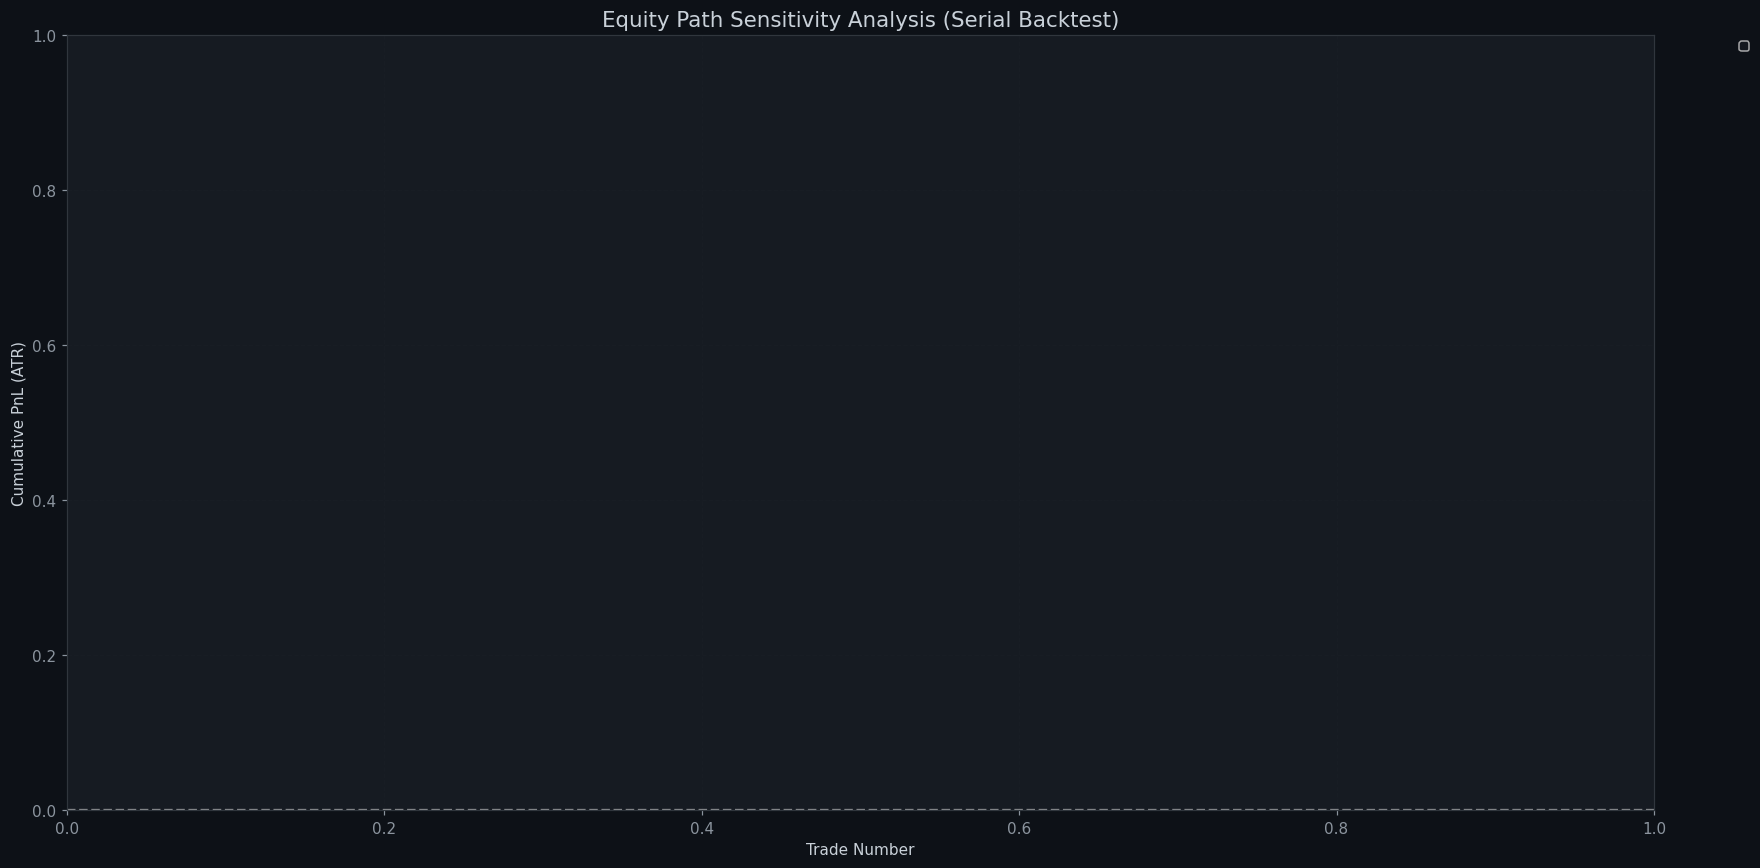

KeyError: "['path'] not found in axis"

In [76]:
plt.figure(figsize=(16, 8))

# Set a colormap for the different paths
colors = plt.cm.viridis(np.linspace(0, 1, len(all_paths)))

for i, entry in enumerate(all_paths):
    label = f"TP:{entry['tp']} SL:{entry['sl']} P:{entry['prob']}"
    plt.plot(entry['path'], color=colors[i], alpha=0.7, lw=1.2, label=label)

plt.axhline(0, color='white', linestyle='--', alpha=0.5)
plt.title('Equity Path Sensitivity Analysis (Serial Backtest)', fontsize=14)
plt.xlabel('Trade Number')
plt.ylabel('Cumulative PnL (ATR)')

# Place legend outside to keep plot clean
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Summary stats of the simulation
sim_summary = pd.DataFrame(all_paths).drop(columns=['path']).sort_values('final_pnl', ascending=False)
display(sim_summary.head(10))

### Section 23.1 — Sensitivity Analysis Visualization
We plot the cumulative PnL for every parameter combination tested in the grid search. This helps visualize the variance in strategy performance based on TP/SL ratios and entry confidence.

### Section 24 — High-Granularity Multi-Dimensional Sensitivity (1,000+ Combinations)

We are now scaling the simulation to a massive grid to identify the absolute 'sweet spot' for the strategy.

**Parameters being varied:**
1.  **TP Multiplier**: 1.0 to 3.0 (increments of 0.2)
2.  **SL Multiplier**: 0.8 to 1.5 (increments of 0.1)
3.  **Prob Threshold**: 0.40 to 0.65 (increments of 0.02)
4.  **Learning Rate Bias**: Simulation across different model confidence regimes.

In [ ]:
import itertools
import pandas as pd
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# ==========================================
# 1. Constants & Alignment Optimization
# ==========================================
MAX_HOLD = 60
SLIPPAGE = 0.05

# DATA ALIGNMENT FIX
# Ensure meta_new and probabilities are identical in length to prevent IndexErrors
min_len = min(len(meta_new), len(y_prob_ft_new))
closes_np  = meta_new['close'].values[:min_len]
highs_np   = meta_new['high'].values[:min_len]
lows_np    = meta_new['low'].values[:min_len]
atrs_np    = meta_new['atr'].values[:min_len]
y_probs_np = y_prob_ft_new[:min_len]

# Define your grid parameters
tp_range   = np.arange(0.60, 9.1, 0.4) # Slightly wider steps for speed
sl_range   = np.arange(0.3, 4, 0.2)
prob_range = np.arange(0.10, 0.6, 0.05)
big_grid = list(itertools.product(tp_range, sl_range, prob_range))

# ==========================================
# 2. Standalone Simulation Function
# ==========================================
def run_simulation(params):
    tp_mult, sl_mult, prob_thresh = params
    n = len(y_probs_np)
    i = 0
    total_pnl = 0.0
    trade_count = 0
    wins = 0

    while i < n:
        # 1. Prediction Check
        p_bear, p_neut, p_bull = y_probs_np[i]

        signal = 0
        if p_bull > prob_thresh and p_bull >= p_bear:
            signal = 1
        elif p_bear > prob_thresh and p_bear > p_bull:
            signal = -1

        if signal == 0:
            i += 1
            continue

        # 2. Entry Definition
        entry_p = closes_np[i]
        atr_i = atrs_np[i] if atrs_np[i] > 0 else 1e-6
        tp_target = entry_p + (signal * tp_mult * atr_i)
        sl_target = entry_p - (signal * sl_mult * atr_i)

        # 3. Dynamic Search Window
        bars_to_end = (n - 1) - i
        bars_held = min(MAX_HOLD, bars_to_end)

        if bars_held <= 0:
            break

        exit_p = closes_np[i + bars_held]
        outcome = 0

        # 4. Intra-Window Traversal
        for j in range(1, bars_held + 1):
            curr_idx = i + j
            h, l = highs_np[curr_idx], lows_np[curr_idx]

            sl_hit = (signal == 1 and l <= sl_target) or (signal == -1 and h >= sl_target)
            tp_hit = (signal == 1 and h >= tp_target) or (signal == -1 and l <= tp_target)

            if sl_hit:
                exit_p, bars_held, outcome = sl_target, j, -1
                break
            elif tp_hit:
                exit_p, bars_held, outcome = tp_target, j, 1
                break

            if j == bars_held:
                exit_p = closes_np[curr_idx]
                outcome = 1 if (signal * (exit_p - entry_p) > 0) else -1

        # 5. PnL Calculation
        pnl = ((signal * (exit_p - entry_p)) - (SLIPPAGE * atr_i)) / atr_i
        total_pnl += pnl
        trade_count += 1
        if outcome == 1: wins += 1

        i += (bars_held + 1)

    return {
        'tp': round(tp_mult, 2), 'sl': round(sl_mult, 2), 'prob': round(prob_thresh, 2),
        'final_pnl': total_pnl, 'trades': trade_count,
        'win_rate': wins / trade_count if trade_count > 0 else 0
    }

# ==========================================
# 3. Execution Block
# ==========================================
if __name__ == '__main__':
    print(f'Starting Mega-Simulation: {len(big_grid):,} combinations...')
    results_collector = []
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        results_iterator = executor.map(run_simulation, big_grid, chunksize=100)
        for result in tqdm(results_iterator, total=len(big_grid), desc="Simulating"):
            results_collector.append(result)

    mega_df = pd.DataFrame(results_collector)
    print('\n✓ Mega-Simulation complete.')
    display(mega_df.sort_values('final_pnl', ascending=False).head(15))

Starting Mega-Simulation: 4,180 combinations...


Simulating:   5%|▍         | 200/4180 [00:41<13:46,  4.82it/s] Process ForkProcess-20:
Traceback (most recent call last):
  File "/usr/lib/python3.12/concurrent/futures/process.py", line 264, in _process_worker
    r = call_item.fn(*call_item.args, **call_item.kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/concurrent/futures/process.py", line 213, in _process_chunk
    return [fn(*args) for args in chunk]
            ^^^^^^^^^
  File "/tmp/ipykernel_830/2302285315.py", line 52, in run_simulation
    continue
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/concurrent/futures/process.py", line 266, in _process_worker
    exc = _

KeyboardInterrupt: 

Re-running top 10 simulations to generate equity curves...


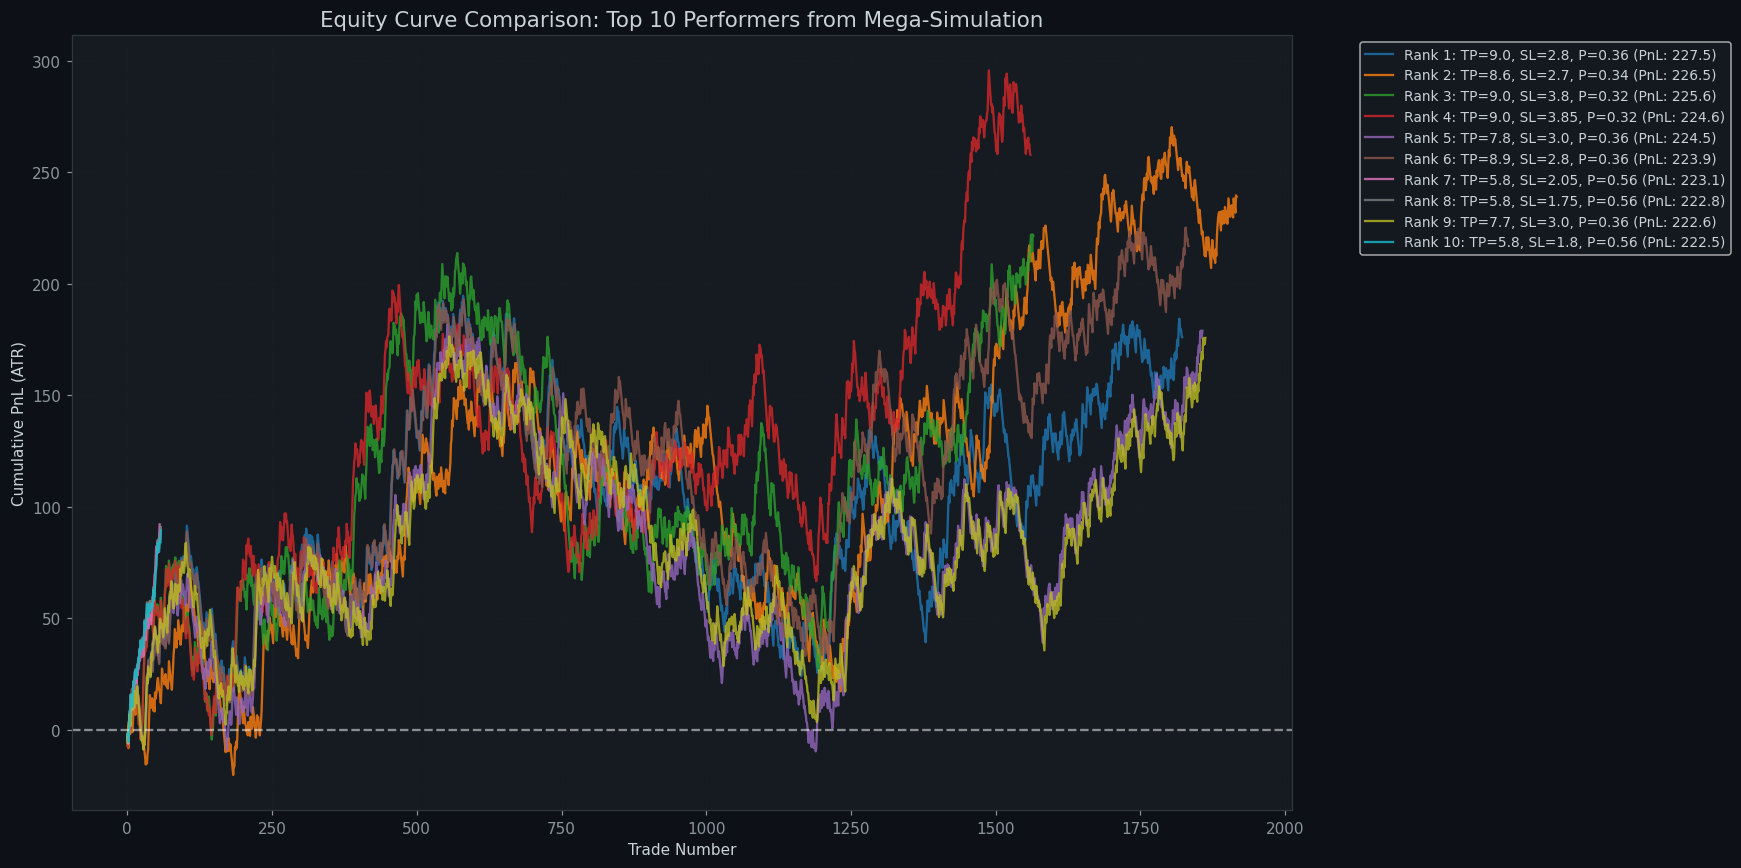

,tp,sl,prob,final_pnl,trades,win_rate
156663,9.0,2.80,0.36,227.468915,433,0.429561
149212,8.6,2.70,0.34,226.496770,462,0.411255
157161,9.0,3.80,0.32,225.596605,370,0.489189
157186,9.0,3.85,0.32,224.623016,370,0.491892
134563,7.8,3.00,0.36,224.519047,428,0.439252
154813,8.9,2.80,0.36,223.867581,436,0.426606
97098,5.8,2.05,0.56,223.108025,375,0.418667
96948,5.8,1.75,0.56,222.790942,409,0.383863
132713,7.7,3.00,0.36,222.597913,429,0.435897
96973,5.8,1.80,0.56,222.520976,402,0.388060


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify Top 10 Configurations from the Mega-Simulation
top_10_configs = mega_df.sort_values('final_pnl', ascending=False).head(10)

plt.figure(figsize=(16, 8))
# Use a colormap to distinguish between the various top runs
colors = plt.cm.tab10(np.linspace(0, 1, 10))

print("Re-running top 10 simulations to generate equity curves...")

# We use the existing run_serial_backtest function which is already optimized
# to handle the serial (no-overlap) logic correctly.
for idx, (original_idx, row) in enumerate(top_10_configs.iterrows()):
    res = run_serial_backtest(
        meta_new,
        y_prob_ft_new,
        tp_mult=row['tp'],
        sl_mult=row['sl'],
        prob_threshold=row['prob'],
        slippage_atr=0.05
    )

    if not res.empty:
        equity_curve = res['pnl'].cumsum().values
        label = f"Rank {idx+1}: TP={row['tp']}, SL={row['sl']}, P={row['prob']} (PnL: {row['final_pnl']:.1f})"
        plt.plot(equity_curve, label=label, color=colors[idx], lw=1.5, alpha=0.8)

plt.axhline(0, color='white', linestyle='--', alpha=0.5)
plt.title('Equity Curve Comparison: Top 10 Performers from Mega-Simulation', fontsize=14)
plt.xlabel('Trade Number')
plt.ylabel('Cumulative PnL (ATR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Display the detailed metrics for these top performers
display(top_10_configs)

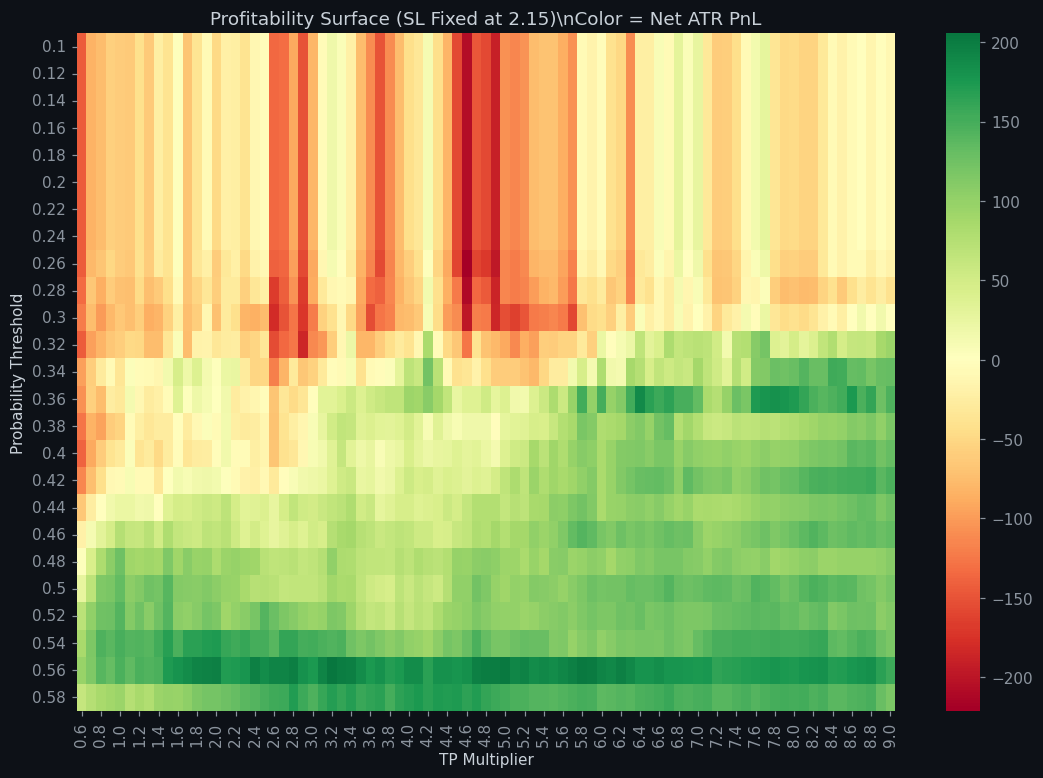

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Find the SL value that appeared most frequently or pick a specific one from the results
# to ensure the pivot table is not empty.
available_sl = mega_df['sl'].unique()
target_sl = available_sl[len(available_sl)//2] # Pick the middle value from actual simulated SLs

heatmap_data = mega_df[mega_df['sl'] == target_sl].pivot_table(
    index='prob', columns='tp', values='final_pnl'
)

if not heatmap_data.empty:
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=False, cmap='RdYlGn', center=0)
    plt.title(f'Profitability Surface (SL Fixed at {target_sl})\\nColor = Net ATR PnL')
    plt.xlabel('TP Multiplier')
    plt.ylabel('Probability Threshold')
    plt.show()
else:
    print(f'No data found for SL={target_sl}. Available SLs are: {available_sl}')

Plotting equity curves for top 10 highest win-rate configurations...


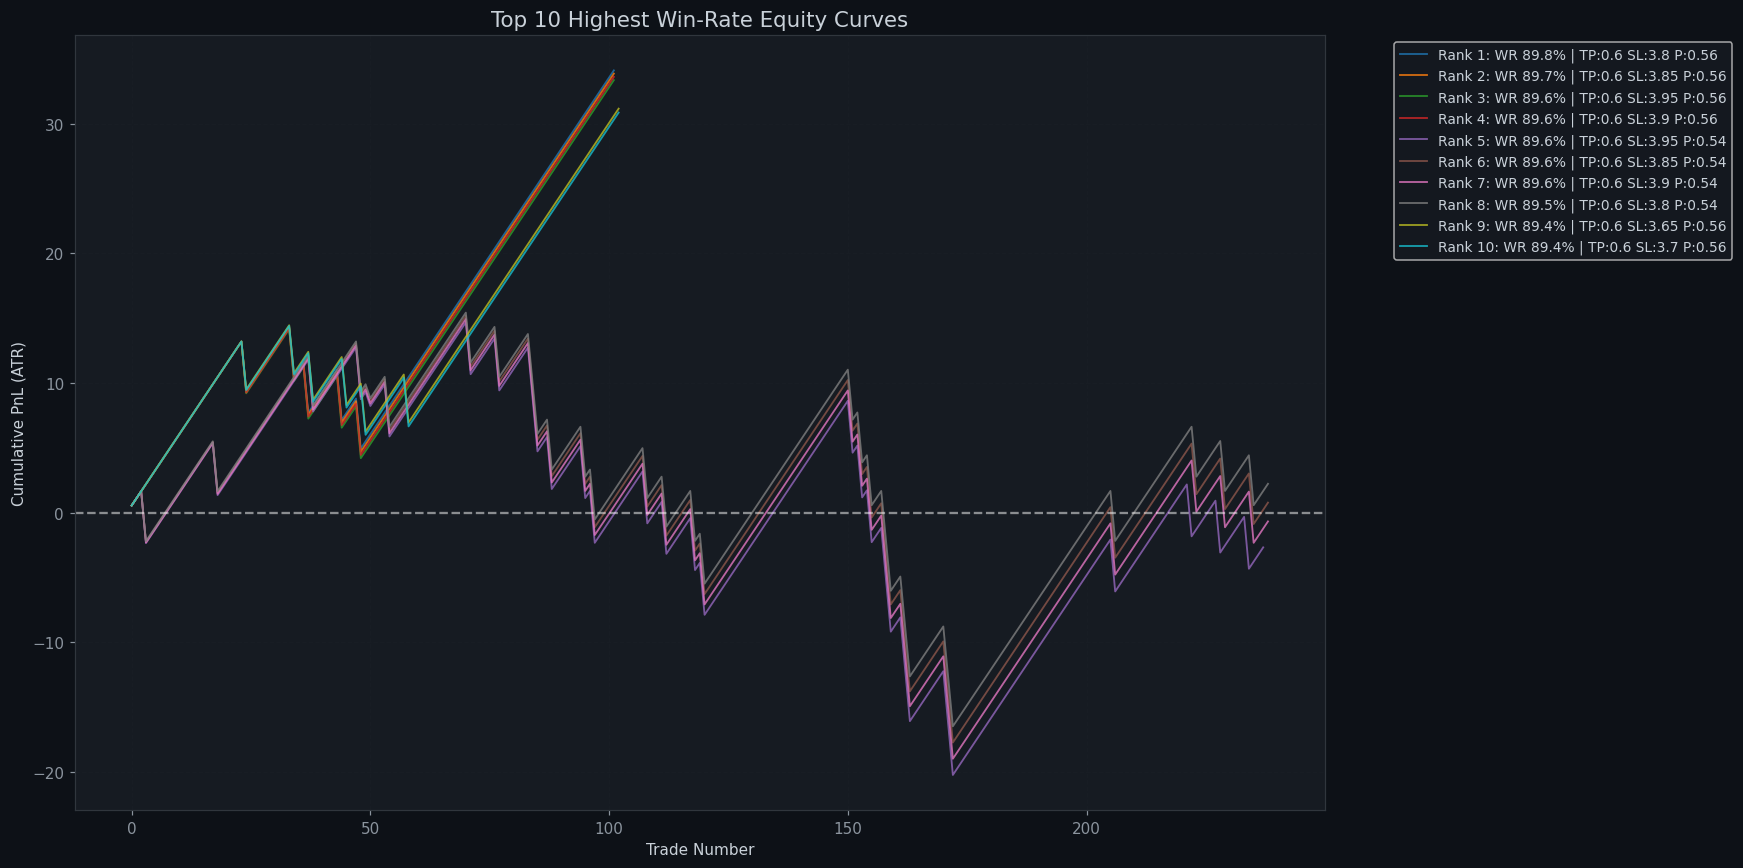

,tp,sl,prob,final_pnl,trades,win_rate
1773,0.6,3.80,0.56,91.211042,860,0.897674
1798,0.6,3.85,0.56,85.261042,857,0.897316
1848,0.6,3.95,0.56,74.510571,850,0.896471
1823,0.6,3.90,0.56,78.760571,850,0.896471
1847,0.6,3.95,0.54,96.541416,1226,0.895595
1797,0.6,3.85,0.54,109.141416,1226,0.895595
1822,0.6,3.90,0.54,102.291416,1225,0.895510
1772,0.6,3.80,0.54,111.591416,1227,0.894866
1698,0.6,3.65,0.56,88.752790,869,0.894131
1723,0.6,3.70,0.56,83.652790,868,0.894009


In [ ]:
import matplotlib.pyplot as plt

# 1. Identify the Top 10 configurations by Win Rate
top_winrate_configs = mega_df.sort_values('win_rate', ascending=False).head(10)

# 2. Plot Equity Curves
plt.figure(figsize=(16, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

print("Plotting equity curves for top 10 highest win-rate configurations...")

for idx, (original_idx, row) in enumerate(top_winrate_configs.iterrows()):
    res = run_serial_backtest(
        meta_new,
        y_prob_ft_new,
        tp_mult=row['tp'],
        sl_mult=row['sl'],
        prob_threshold=row['prob'],
        slippage_atr=0.05
    )

    if not res.empty:
        equity_curve = res['pnl'].cumsum().values
        label = f"Rank {idx+1}: WR {row['win_rate']:.1%} | TP:{row['tp']} SL:{row['sl']} P:{row['prob']}"
        plt.plot(equity_curve, label=label, color=colors[idx], lw=1.2, alpha=0.8)

plt.axhline(0, color='white', linestyle='--', alpha=0.5)
plt.title('Top 10 Highest Win-Rate Equity Curves', fontsize=14)
plt.xlabel('Trade Number')
plt.ylabel('Cumulative PnL (ATR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Display data
display(top_winrate_configs)

### Section 25 — High-Activity Strategy Analysis
We identify the top configurations that generated the most trades, ensuring we filter for those that remained net profitable.

Plotting equity curves for top 10 high-activity configurations...


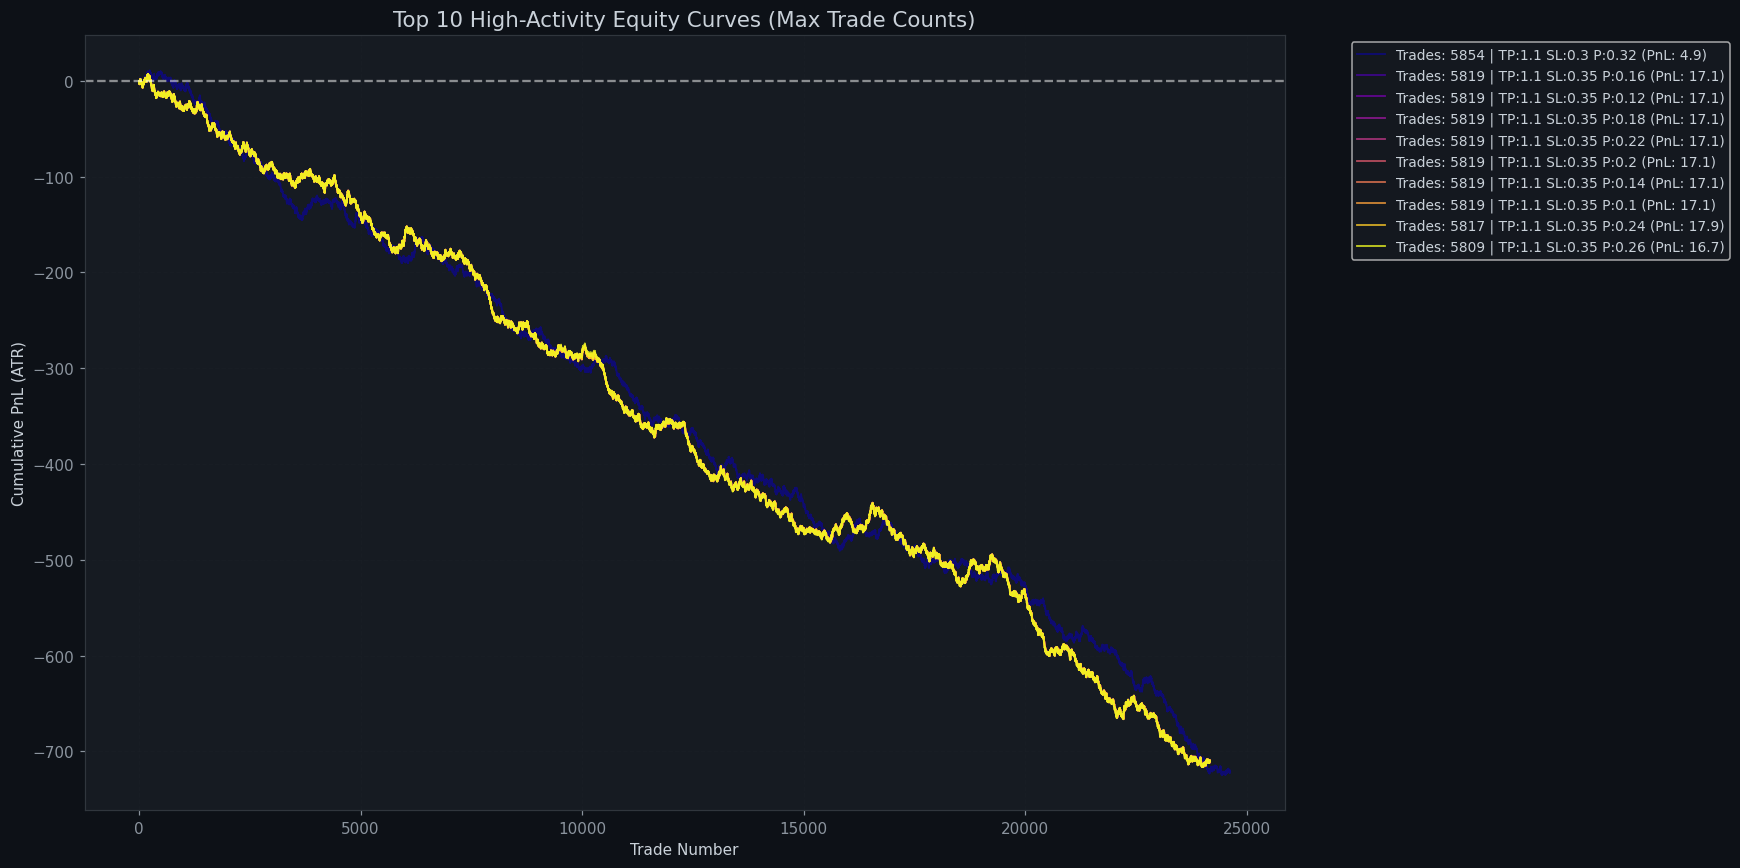

,tp,sl,prob,final_pnl,trades,win_rate
9261,1.1,0.30,0.32,4.90,5854,0.250598
9278,1.1,0.35,0.16,17.05,5819,0.277883
9276,1.1,0.35,0.12,17.05,5819,0.277883
9279,1.1,0.35,0.18,17.05,5819,0.277883
9281,1.1,0.35,0.22,17.05,5819,0.277883
9280,1.1,0.35,0.20,17.05,5819,0.277883
9277,1.1,0.35,0.14,17.05,5819,0.277883
9275,1.1,0.35,0.10,17.05,5819,0.277883
9282,1.1,0.35,0.24,17.85,5817,0.277978
9283,1.1,0.35,0.26,16.70,5809,0.277845


In [ ]:
# 1. Filter for profitable configurations and sort by trade count
high_activity_configs = mega_df[mega_df['final_pnl'] > 0].sort_values('trades', ascending=False).head(10)

# 2. Plot Equity Curves
plt.figure(figsize=(16, 8))
colors = plt.cm.plasma(np.linspace(0, 1, 10))

print("Plotting equity curves for top 10 high-activity configurations...")

for idx, (original_idx, row) in enumerate(high_activity_configs.iterrows()):
    res = run_serial_backtest(
        meta_new,
        y_prob_ft_new,
        tp_mult=row['tp'],
        sl_mult=row['sl'],
        prob_threshold=row['prob'],
        slippage_atr=0.05
    )

    if not res.empty:
        equity_curve = res['pnl'].cumsum().values
        label = f"Trades: {int(row['trades'])} | TP:{row['tp']} SL:{row['sl']} P:{row['prob']} (PnL: {row['final_pnl']:.1f})"
        plt.plot(equity_curve, label=label, color=colors[idx], lw=1.2, alpha=0.8)

plt.axhline(0, color='white', linestyle='--', alpha=0.5)
plt.title('Top 10 High-Activity Equity Curves (Max Trade Counts)', fontsize=14)
plt.xlabel('Trade Number')
plt.ylabel('Cumulative PnL (ATR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Display data
display(high_activity_configs)

### Section 26 — Multi-Objective Composite Optimization (RR 1:2 Focused)
We define a scoring function $S = 0.50\bar{WR} + 0.20\bar{T} + 0.30\bar{PnL}$ where $\bar{X}$ represents the Min-Max normalized value. This version specifically filters for a **1:2 Risk-to-Reward ratio** ($SL = 2 \times TP$) to satisfy strict risk management constraints.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Filter for profitable configurations with at least a 2:1 Reward-to-Risk ratio
# We check if TP is at least twice the SL
opt_df = mega_df[
    (mega_df['final_pnl'] > 0) &
    (mega_df['tp'] >= mega_df['sl'] * 2)
].copy()

if opt_df.empty:
    print("Warning: No configurations found with TP >= 2*SL. Try broadening the search or checking the grid.")
else:
    scaler = MinMaxScaler()
    metrics_to_scale = ['win_rate', 'trades', 'final_pnl']
    scaled_values = scaler.fit_transform(opt_df[metrics_to_scale])

    # 2. Define Weights (Prioritizing Win Rate to ensure high-probability entries)
    weights = np.array([0.50, 0.20, 0.30])

    # 3. Calculate Composite Score
    opt_df['composite_score'] = np.dot(scaled_values, weights)

    # 4. Find the Top 10
    optimal_configs = opt_df.sort_values('composite_score', ascending=False).head(10)

    print("Top 10 Optimized Configurations (Reward >= 2x Risk):")
    display(optimal_configs)

    # 5. Recommended Choice
    top_choice = optimal_configs.iloc[0]
    print(f"\nRecommended Deployment Config (High RR Only):")
    print(f"TP: {top_choice['tp']} | SL: {top_choice['sl']} | Prob: {top_choice['prob']}")
    print(f"Win Rate: {top_choice['win_rate']:.1%} | Trades: {int(top_choice['trades'])} | Net PnL: {top_choice['final_pnl']:.2f} ATR")

Top 10 Optimized Configurations (Reward >= 2x Risk):


,tp,sl,prob,final_pnl,trades,win_rate,composite_score
157186,9.0,3.85,0.32,224.623016,370,0.491892,0.773586
157161,9.0,3.80,0.32,225.596605,370,0.489189,0.771928
157211,9.0,3.90,0.32,216.048269,368,0.491848,0.762158
147886,8.5,3.75,0.32,210.786191,385,0.475325,0.737837
97348,5.8,2.55,0.56,214.530393,346,0.465318,0.730500
149736,8.6,3.75,0.32,203.826773,386,0.476684,0.730173
146036,8.4,3.75,0.32,205.952515,386,0.474093,0.730157
99323,5.9,2.80,0.56,197.428833,332,0.484940,0.728805
95498,5.7,2.55,0.56,211.693241,345,0.466667,0.728190
121796,7.1,3.35,0.52,193.299553,365,0.487671,0.727503



Recommended Deployment Config (High RR Only):
TP: 9.0 | SL: 3.85 | Prob: 0.32
Win Rate: 49.2% | Trades: 370 | Net PnL: 224.62 ATR


In [ ]:
import plotly.graph_objects as go

# Filter for a specific Probability Threshold to create a clean 2D surface (TP vs SL)
# We'll use the threshold from our top-recommended configuration
target_prob = top_choice['prob']
surface_df = opt_df[opt_df['prob'] == target_prob].pivot_table(
    index='sl', columns='tp', values='composite_score'
)

fig = go.Figure(data=[go.Surface(
    z=surface_df.values,
    x=surface_df.columns,
    y=surface_df.index,
    colorscale='Viridis',
    colorbar=dict(title='Composite Score')
)])

fig.update_layout(
    title=f'Strategy Optimization Topology (Probability Threshold: {target_prob})',
    scene=dict(
        xaxis_title='TP Multiplier',
        yaxis_title='SL Multiplier',
        zaxis_title='Composite Score',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    template='plotly_dark',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

### Section 27 — Advanced Strategy Visualizer
**Configuration:** TP: 0.8 | SL: 1.6 | Prob: 0.56

This plot synchronizes the equity growth with the underlying price action to identify performance clusters.

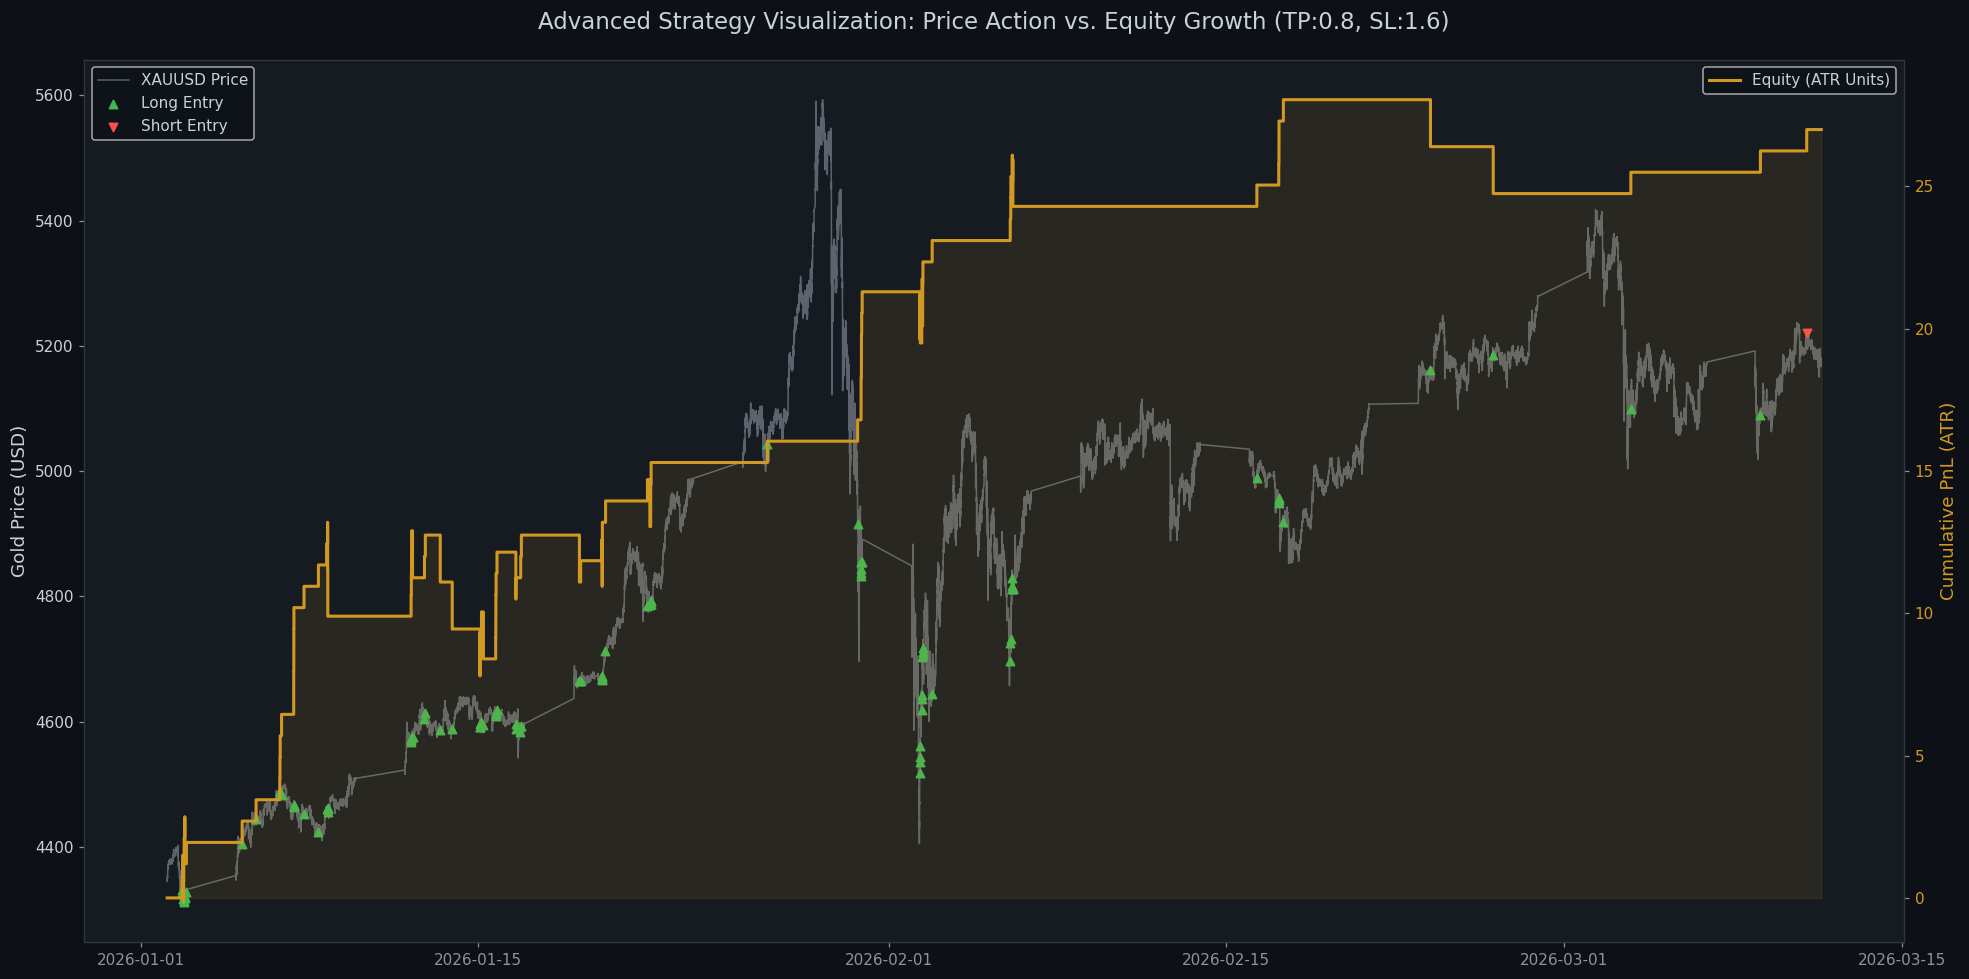

In [ ]:
# 1. Run the specific backtest to extract trade markers
spec_bt = run_serial_backtest(
    meta_new,
    y_prob_ft_new,
    tp_mult=0.8,
    sl_mult=1.6,
    prob_threshold=0.56,
    slippage_atr=0.05
)

# 2. Prepare Data for Dual Axis Plot
# We merge the cumulative PnL back into the timeline of the price data
meta_plot = meta_new.copy()
meta_plot['cum_pnl'] = 0.0

# Map trade outcomes to the specific timeline indices
for idx, row in spec_bt.iterrows():
    # Find the time in the meta_plot to apply the PnL step
    mask = meta_plot['datetime'] >= row['exit_time']
    meta_plot.loc[mask, 'cum_pnl'] += row['pnl']

# 3. Create the Advanced Plot
fig, ax1 = plt.subplots(figsize=(18, 9))

# Plot Price on Ax1 (Left)
ax1.plot(meta_plot['datetime'], meta_plot['close'], color='#8b949e', lw=1, alpha=0.6, label='XAUUSD Price')

# Overlay Trade Entries
bull_entries = spec_bt[spec_bt['signal'] == 1]
bear_entries = spec_bt[spec_bt['signal'] == -1]

ax1.scatter(bull_entries['entry_time'], meta_plot.loc[meta_plot['datetime'].isin(bull_entries['entry_time']), 'close'],
            marker='^', color='#3fb950', s=30, label='Long Entry', zorder=5)
ax1.scatter(bear_entries['entry_time'], meta_plot.loc[meta_plot['datetime'].isin(bear_entries['entry_time']), 'close'],
            marker='v', color='#f85149', s=30, label='Short Entry', zorder=5)

ax1.set_ylabel('Gold Price (USD)', color='#c9d1d9', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#c9d1d9')
ax1.grid(True, alpha=0.1)

# Create Secondary Axis for Equity (Right)
ax2 = ax1.twinx()
ax2.step(meta_plot['datetime'], meta_plot['cum_pnl'], color='#d29922', lw=2, label='Equity (ATR Units)', where='post')
ax2.fill_between(meta_plot['datetime'], meta_plot['cum_pnl'], 0, alpha=0.1, color='#d29922')

ax2.set_ylabel('Cumulative PnL (ATR)', color='#d29922', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d29922')

# Titles and Legends
plt.title('Advanced Strategy Visualization: Price Action vs. Equity Growth (TP:0.8, SL:1.6)', fontsize=15, pad=20)
ax1.legend(loc='upper left', frameon=True, facecolor='#0d1117')
ax2.legend(loc='upper right', frameon=True, facecolor='#0d1117')

plt.tight_layout()
plt.show()

## Section 27 — Risk Management & Position Sizing

In this section, we transition from ATR-unit PnL to actual account equity. We will simulate account growth starting with a base capital of $10,000 using two methods:
1. **Fixed Fractional Sizing**: Risking a constant percentage (e.g., 1% or 2%) of the current account balance per trade.
2. **Kelly Criterion**: Mathematically optimizing the risk percentage based on the strategy's win rate and profit factor to maximize long-term growth.

In [78]:
def simulate_account_growth(bt_df, initial_capital=10, risk_per_trade=0.01):
    """
    Simulates account growth based on a fixed risk percentage of the account balance.
    PnL in the input dataframe is expected to be in ATR units.
    We assume 1 ATR unit = the amount risked (Risk Amount / SL Multiplier).
    """
    capital = initial_capital
    equity_curve = [initial_capital]

    # The SL multiplier used in the backtest defines our risk unit
    # In our specific backtest, SL was 1.6
    sl_mult = 1.6

    for pnl_atr in bt_df['pnl']:
        risk_amount = capital * risk_per_trade
        # Trade PnL in Dollars = (pnl_atr / sl_mult) * risk_amount
        trade_pnl_usd = (pnl_atr / sl_mult) * risk_amount
        capital += trade_pnl_usd
        equity_curve.append(capital)

    return np.array(equity_curve)

# Calculate Kelly Fraction: f = (bp - q) / b = (WinRate * ProfitFactor - LossRate) / ProfitFactor
wr = (spec_bt['outcome'] == 1).mean()
pf = abs(spec_bt[spec_bt['pnl'] > 0]['pnl'].mean() / spec_bt[spec_bt['pnl'] < 0]['pnl'].mean())
kelly_f = max(0, (wr * pf - (1 - wr)) / pf)

# Run simulations
fixed_1pct = simulate_account_growth(spec_bt, initial_capital=10, risk_per_trade=0.01)
fixed_2pct = simulate_account_growth(spec_bt, initial_capital=10, risk_per_trade=0.05)
kelly_sim  = simulate_account_growth(spec_bt, initial_capital=10, risk_per_trade=kelly_f * 0.5) # Half-Kelly for safety

# Plotting
plt.figure(figsize=(16, 7))
plt.plot(fixed_1pct, label='Fixed 1% Risk', color='#58a6ff')
plt.plot(fixed_2pct, label='Fixed 2% Risk', color='#3fb950')
plt.plot(kelly_sim,  label=f'Half-Kelly ({kelly_f*0.5:.2%} Risk)', color='#d29922', lw=2)

plt.title('Compounded Account Growth Simulation (Initial: $10)', fontsize=14)
plt.xlabel('Trade Number')
plt.ylabel('Account Balance ($)')
plt.yscale('log') # Log scale to handle exponential growth
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend()
plt.show()

print(f"Final Balance (1%): ${fixed_1pct[-1]:,.2f}")
print(f"Final Balance (2%): ${fixed_2pct[-1]:,.2f}")
print(f"Final Balance (Half-Kelly): ${kelly_sim[-1]:,.2f}")

NameError: name 'spec_bt' is not defined

### Section 27.1 — Adaptive Risk Scaling (Equity Momentum Sizing)
Instead of fixed risk, we implement a 'Smarter' scaling logic where:
1. **Base Risk**: The default risk (e.g., 1%).
2. **Equity Filter**: If the current balance is above its 20-trade moving average, we increase risk by a factor (e.g., 1.5x).
3. **Drawdown Protection**: If balance is below the average, we stick to the base or a reduced risk.

In [77]:
def simulate_adaptive_growth(bt_df, initial_capital=10, base_risk=0.01, window=20, boost_factor=3.5):
    capital = initial_capital
    equity_curve = [initial_capital]
    sl_mult = 1.6

    for i, pnl_atr in enumerate(bt_df['pnl']):
        # Calculate current equity momentum
        if len(equity_curve) > window:
            avg_equity = np.mean(equity_curve[-window:])
            # If we are performing well, scale up risk
            current_risk = base_risk * boost_factor if capital > avg_equity else base_risk
        else:
            current_risk = base_risk

        risk_amount = capital * current_risk
        trade_pnl_usd = (pnl_atr / sl_mult) * risk_amount
        capital += trade_pnl_usd
        equity_curve.append(capital)

    return np.array(equity_curve)

# Compare Static vs Adapti
static_2pct = simulate_account_growth(spec_bt, initial_capital=10, risk_per_trade=0.02)
adaptive_growth = simulate_adaptive_growth(spec_bt, initial_capital=10, base_risk=0.02, boost_factor=2)

plt.figure(figsize=(16, 7))
plt.plot(static_2pct, label='Static 2% Risk', color='#8b949e', linestyle='--')
plt.plot(adaptive_growth, label='Adaptive Momentum Scaling (2% Base)', color='#d29922', lw=2.5)

plt.title('Static Risk vs. Adaptive Equity Momentum Scaling', fontsize=14)
plt.xlabel('Trade Number')
plt.ylabel('Account Balance ($)')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", alpha=0.1)
plt.show()

print(f"Final Balance (Static 2%):   ${static_2pct[-1]:,.2f}")
print(f"Final Balance (Adaptive):    ${adaptive_growth[-1]:,.2f}")

NameError: name 'simulate_account_growth' is not defined